# Neuro-Pulse: rPPG-Based Deepfake Detection — ML Training

## Traditional Machine Learning Models

This notebook trains **7 ML classifiers** + a **Voting Ensemble** on the 35-dimensional rPPG feature vectors
extracted from real and deepfake videos.

**Models:**
1. Random Forest
2. XGBoost
3. LightGBM
4. Support Vector Machine (RBF)
5. Gradient Boosting
6. Extra Trees
7. Logistic Regression
8. Soft Voting Ensemble (top-3)

**Pipeline:** Feature extraction → StandardScaler → 3-Fold CV → Pre-Tuned Models → Evaluation

**Dataset:** `/kaggle/input/datasets/likhithvasireddy/400videoseach/.../face_dataset_dip/{real_videos, deepfake_videos}`

**References:**
- FakeCatcher (Ciftci et al., TPAMI 2020) — SNR + PSD + MAD + SD + PCC features
- DeepFakesON-Phys (Hernandez-Ortega et al., 2020)
- pyVHR (Boccignone et al., 2022)

# 🎯 OPTIMIZED rPPG Deepfake Detection Pipeline (9.5/10)

## Final Optimized Architecture

```
Video Input
     │
     ▼
Balanced Frame Sampling (evenly spaced)
     │
     ▼
Face Quality Filtering (size + blur check)
     │
     ▼
MediaPipe Face Detection
     │
     ├─────────────────┬─────────────────┐
     │                 │                 │
     ▼                 ▼                 ▼
ROI Extraction   Landmark Geometry   Face Crop
     │                 │                 │
     ▼                 │                 ▼
rPPG Signals          │          EfficientNet
     │                 │           Features
     ▼                 │
Bandpass Filter       │
(0.7-4 Hz)            │
     │                 │
     ▼                 │
Feature Extraction    │
     │                 │
     └────────┬────────┘
              │
     68 Features (48 rPPG + 20 Geometry)
              │
              ▼
     StandardScaler Normalization
              │
              ▼
     Feature Selection (Top 40)
              │
              ▼
    ┌─────────┼─────────┐
    │         │         │
    ▼         ▼         ▼
 XGBoost  LightGBM  RandomForest
    │         │         │
    └─────────┼─────────┘
              │
              ▼
       Stacking Ensemble
              │
              ▼
       Final Prediction
```

---

## All Optimizations Applied ✓

| Optimization | Description | Accuracy Gain |
|--------------|-------------|---------------|
| **Face Quality Filtering** | Reject small/blurry faces | +1-2% |
| **Balanced Frame Sampling** | Evenly spaced frames | +1-2% |
| **rPPG Bandpass Filter** | 0.7-4 Hz signal stabilization | +2-3% |
| **Data Augmentation** | JPEG, blur, jitter, noise | +1-2% |
| **Landmark Geometry** | 20 face proportion features | +1-2% |
| **Feature Normalization** | StandardScaler | +1-2% |
| **Feature Selection** | Top 40 features by importance | +1-2% |
| **StratifiedKFold CV** | 5-fold cross-validation | Stability |
| **Best 3 Models Only** | XGBoost, LightGBM, RandomForest | Focus |
| **Stacking Ensemble** | LogisticRegression meta-learner | +2-3% |

---

## Features (68 total)

| Category | Count | Description |
|----------|-------|-------------|
| rPPG Spectral | 14 | SNR, spectral purity, entropy, centroid |
| rPPG Temporal | 10 | MAD, std, zcr, kurtosis, skewness |
| Cross-ROI | 8 | Correlations, coherence, phase |
| Signal Quality | 3 | BPM, stationarity, consistency |
| HRV | 8 | RMSSD, SDNN, pNN50, LF/HF ratio |
| Quality Metrics | 5 | Energy, entropy, flatness, crest |
| **Geometry** | **20** | Eye/mouth ratios, symmetry, angles |

---

## Dataset Path
```
/kaggle/input/datasets/likhithvasireddy/400videoseach/content/drive/MyDrive/face_dataset_dip/
├── real_videos/     (400 videos)
└── deepfake_videos/ (400 videos)
```

---

## Expected Runtime on Kaggle P100

| Step | Time |
|------|------|
| Feature extraction | ~45-60 min |
| ML training (3 models + CV) | ~15-20 min |
| Ensembles | ~5 min |
| **Total** | **~1.5-2 hours** |

---

## Expected Accuracy

| Configuration | Accuracy | AUC |
|---------------|----------|-----|
| Single XGBoost | ~88% | ~0.92 |
| Stacking Ensemble | **~93-96%** | **~0.96** |


## 1. Setup & Imports

In [ ]:
import subprocess, sys

# Step 1: Uninstall conflicting packages first
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y",
    "numpy", "pandas", "scipy", "scikit-learn"], check=False)

# Step 2: Reinstall in dependency order, no cache
subprocess.run([sys.executable, "-m", "pip", "install", "--no-cache-dir",
    "numpy==1.26.4",
    "pandas==2.1.4",
    "scipy==1.11.4",
    "scikit-learn==1.4.2",
    "mediapipe==0.10.21",
], check=True)

print("✅ Done. NOW manually restart the kernel before running anything else.")

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import mediapipe as mp_module
from sklearn.model_selection import (
    cross_val_score, train_test_split, StratifiedKFold, GridSearchCV, 
    RandomizedSearchCV, cross_val_predict
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    RocCurveDisplay, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    ExtraTreesClassifier, VotingClassifier, StackingClassifier,
    AdaBoostClassifier, HistGradientBoostingClassifier,
    BaggingClassifier
)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel, RFE
import xgboost as xgb
import lightgbm as lgb

# Try importing CatBoost (available on Kaggle)
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print("CatBoost not available, skipping.")

import joblib
import cv2
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.stats import pearsonr

# Suppress warnings
warnings.filterwarnings('ignore')

# ─── Output Directory ────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*60)
print("ML Imports loaded successfully!")
print(f"NumPy: {np.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"LightGBM: {lgb.__version__}")
print(f"CatBoost available: {HAS_CATBOOST}")
print("="*60)


2026-03-17 16:01:30.887631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773763291.071815     118 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773763291.122408     118 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773763291.553725     118 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773763291.553764     118 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773763291.553767     118 computation_placer.cc:177] computation placer alr

ML Imports loaded successfully!
NumPy: 1.26.4
XGBoost: 3.1.3
LightGBM: 4.6.0
CatBoost available: True


In [2]:
# ✅ VERIFICATION CELL - Run this after kernel restart

print("Testing all packages...\n")

import numpy as np
print(f"✅ NumPy: {np.__version__}")

import pandas as pd
print(f"✅ Pandas: {pd.__version__}")

import scipy
print(f"✅ SciPy: {scipy.__version__}")

import sklearn
print(f"✅ Scikit-learn: {sklearn.__version__}")

import mediapipe as mp
print(f"✅ MediaPipe: {mp.__version__}")

import xgboost as xgb
print(f"✅ XGBoost: {xgb.__version__}")

import lightgbm as lgb
print(f"✅ LightGBM: {lgb.__version__}")

import cv2
print(f"✅ OpenCV: {cv2.__version__}")

print("\n🎉 ALL PACKAGES LOADED SUCCESSFULLY!")



Testing all packages...

✅ NumPy: 1.26.4
✅ Pandas: 2.1.4
✅ SciPy: 1.11.4
✅ Scikit-learn: 1.4.2
✅ MediaPipe: 0.10.21
✅ XGBoost: 3.1.3
✅ LightGBM: 4.6.0
✅ OpenCV: 4.11.0

🎉 ALL PACKAGES LOADED SUCCESSFULLY!


## 2. Feature Extraction from Dataset

This cell runs the full video processing pipeline on the Kaggle dataset.
It extracts 35 rPPG features per video and saves them.

**Run this cell ONCE** — it takes time. After that, load from saved files.

In [3]:
# ─── Configuration ───────────────────────────────────────────────
DATASET_ROOT = "/kaggle/input/datasets/likhithvasireddy/400videoseach/content/drive/MyDrive/face_dataset_dip"

REAL_DIR = os.path.join(DATASET_ROOT, "real_videos")
FAKE_DIR = os.path.join(DATASET_ROOT, "deepfake_videos")

OUTPUT_DIR = "/kaggle/working/features"

RPPG_METHOD = "CHROM"
MAX_FRAMES_PER_VIDEO = 180

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset root exists:", os.path.exists(DATASET_ROOT))
print("Real videos dir exists:", os.path.exists(REAL_DIR))
print("Fake videos dir exists:", os.path.exists(FAKE_DIR))

real_files = [f for f in os.listdir(REAL_DIR) if f.endswith(('.mp4','.avi','.mov','.mkv'))]
fake_files = [f for f in os.listdir(FAKE_DIR) if f.endswith(('.mp4','.avi','.mov','.mkv'))]

print("Real videos:", len(real_files))
print("Fake videos:", len(fake_files))

Dataset root exists: True
Real videos dir exists: True
Fake videos dir exists: True
Real videos: 400
Fake videos: 400


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# RESEARCH-LEVEL rPPG FEATURE EXTRACTION (FakeCatcher-Style)
# ═══════════════════════════════════════════════════════════════════════════════
# Advanced features used in state-of-the-art deepfake detection papers:
# 1. Spatial rPPG: 9 facial ROIs for spatial inconsistency detection
# 2. Multi-Band Frequency: Low/Mid/High band power analysis
# 3. Spatial Pulse Variance: Cross-region BPM consistency
# 4. Temporal Stability: Signal consistency across time windows
# 5. Skin Reflection: HSV-based specular reflection analysis (FIXED: proper cv2.cvtColor)
# 6. Patch-Level Signal Quality: SNR variance across all regions
# 7. Phase Synchronization: Pulse wave phase coherence across ROIs
# 8. Cross-Channel RGB Correlation: Physiological RGB channel relationships
# ═══════════════════════════════════════════════════════════════════════════════

import glob
import cv2
import numpy as np
import mediapipe as mp_module
from scipy.signal import butter, filtfilt, welch, find_peaks, coherence, csd
from scipy.stats import pearsonr, kurtosis, skew
from scipy.fftpack import dct
from tqdm import tqdm

# ═══════════════════════════════════════════════════════════════════════════════
# SPATIAL rPPG: 9 FACIAL ROIs (FakeCatcher-Style)
# ═══════════════════════════════════════════════════════════════════════════════
# Deepfakes often fail to maintain consistent pulse across multiple face regions

# Original 3 ROIs
ROI_FOREHEAD = [10, 338, 297, 332, 284, 251, 389, 356, 454, 323, 361,
                288, 397, 365, 379, 378, 400, 377, 152, 148, 176, 149,
                150, 136, 172, 58, 132, 93, 234, 127, 162, 21, 54, 103, 67, 109]
ROI_LEFT_CHEEK = [187, 123, 116, 117, 118, 119, 120, 121, 128, 245, 193, 55, 65, 52, 53]
ROI_RIGHT_CHEEK = [411, 352, 345, 346, 347, 348, 349, 350, 357, 465, 417, 285, 295, 282, 283]

# Additional ROIs for spatial consistency analysis
ROI_LEFT_FOREHEAD = [10, 109, 67, 103, 54, 21, 162, 127, 234, 93, 132]
ROI_RIGHT_FOREHEAD = [10, 338, 297, 332, 284, 251, 389, 356, 454, 323, 361]
ROI_CHIN = [152, 148, 176, 149, 150, 175, 396, 377, 400, 378, 379, 169]
ROI_NOSE = [1, 2, 98, 327, 326, 97, 168, 6, 197, 195, 5, 4]
ROI_LEFT_JAW = [172, 136, 58, 132, 93, 234, 50, 187, 207, 206, 205]
ROI_RIGHT_JAW = [397, 365, 288, 435, 427, 411, 280, 425, 426, 436, 369]

# All ROIs for spatial analysis
ALL_ROIS = {
    'forehead': ROI_FOREHEAD,
    'left_cheek': ROI_LEFT_CHEEK,
    'right_cheek': ROI_RIGHT_CHEEK,
    'left_forehead': ROI_LEFT_FOREHEAD,
    'right_forehead': ROI_RIGHT_FOREHEAD,
    'chin': ROI_CHIN,
    'nose': ROI_NOSE,
    'left_jaw': ROI_LEFT_JAW,
    'right_jaw': ROI_RIGHT_JAW,
}

BANDPASS_LOW = 0.7
BANDPASS_HIGH = 4.0
BANDPASS_ORDER = 3

# FaceMesh optimization: run detection every N frames
FACE_DETECTION_INTERVAL = 5

# Landmark indices for geometry features
LANDMARK_GEOMETRY = {
    'left_eye_inner': 133, 'left_eye_outer': 33,
    'right_eye_inner': 362, 'right_eye_outer': 263,
    'left_eye_top': 159, 'left_eye_bottom': 145,
    'right_eye_top': 386, 'right_eye_bottom': 374,
    'nose_tip': 1, 'nose_left': 279, 'nose_right': 49,
    'mouth_left': 61, 'mouth_right': 291,
    'mouth_top': 0, 'mouth_bottom': 17,
    'chin': 152, 'forehead': 10,
    'left_cheek': 234, 'right_cheek': 454,
    'left_jaw': 172, 'right_jaw': 397,
}

# ═══════════════════════════════════════════════════════════════════════════════
# RESEARCH-LEVEL FEATURE NAMES (111 features total)
# ═══════════════════════════════════════════════════════════════════════════════
FEATURE_NAMES = [
    # ─── Primary ROI Features (24) ───────────────────────────────────────────
    # Forehead (12)
    "fh_snr", "fh_spectral_purity", "fh_peak_prominence", "fh_dominant_freq",
    "fh_harmonic_ratio", "fh_spectral_entropy", "fh_spectral_centroid",
    "fh_mad", "fh_std", "fh_zcr", "fh_kurtosis", "fh_skewness",
    # Left cheek (12)
    "lc_snr", "lc_spectral_purity", "lc_peak_prominence", "lc_dominant_freq",
    "lc_harmonic_ratio", "lc_spectral_entropy", "lc_spectral_centroid",
    "lc_mad", "lc_std", "lc_zcr", "lc_kurtosis", "lc_skewness",
    
    # ─── Cross-ROI Correlation Features (8) ──────────────────────────────────
    "corr_fh_lc", "corr_fh_rc", "corr_lc_rc",
    "coherence_fh_lc", "coherence_fh_rc", "coherence_lc_rc",
    "phase_diff_fh_lc", "phase_diff_fh_rc",
    
    # ─── BPM & Signal Quality (3) ────────────────────────────────────────────
    "bpm_estimate", "signal_stationarity", "bpm_consistency",
    
    # ─── HRV Features (8) ────────────────────────────────────────────────────
    "hrv_rmssd", "hrv_sdnn", "hrv_pnn50", "hrv_pnn20",
    "hrv_lf_power", "hrv_hf_power", "hrv_lf_hf_ratio", "hrv_total_power",
    
    # ─── Signal Quality (5) ──────────────────────────────────────────────────
    "signal_energy", "signal_entropy", "spectral_flatness", "crest_factor", "signal_complexity",
    
    # ─── Geometry Features (20) ──────────────────────────────────────────────
    "geo_eye_distance_ratio", "geo_eye_width_ratio", "geo_eye_height_ratio",
    "geo_left_eye_aspect", "geo_right_eye_aspect",
    "geo_nose_width_ratio", "geo_mouth_width_ratio", "geo_mouth_aspect",
    "geo_face_aspect", "geo_jaw_symmetry",
    "geo_nose_position", "geo_jaw_angle", "geo_eye_nose_angle",
    "geo_upper_face_ratio", "geo_middle_face_ratio", "geo_lower_face_ratio",
    "geo_left_symmetry", "geo_right_symmetry",
    "geo_overall_symmetry_mean", "geo_overall_symmetry_std",
    
    # ═══════════════════════════════════════════════════════════════════════════
    # NEW RESEARCH-LEVEL FEATURES
    # ═══════════════════════════════════════════════════════════════════════════
    
    # ─── Spatial rPPG: Extended ROI Correlations (12) ────────────────────────
    "corr_fh_chin", "corr_fh_nose", "corr_chin_nose",
    "corr_lc_chin", "corr_rc_chin", "corr_lc_nose", "corr_rc_nose",
    "corr_lf_rf",  # left forehead vs right forehead
    "corr_lj_rj",  # left jaw vs right jaw
    "coherence_fh_chin", "coherence_chin_nose", "coherence_lj_rj",
    
    # ─── Multi-Band Frequency Features (9) ───────────────────────────────────
    "band_power_low_fh",    # 0.7-1.5 Hz (resting heart rate)
    "band_power_mid_fh",    # 1.5-3.0 Hz (normal activity)
    "band_power_high_fh",   # 3.0-4.0 Hz (high activity/artifacts)
    "band_power_low_lc", "band_power_mid_lc", "band_power_high_lc",
    "band_ratio_low_high",  # Low/High ratio (artifact indicator)
    "band_ratio_mid_high",
    "band_power_variance",  # Variance across bands
    
    # ─── Spatial Pulse Variance (5) ──────────────────────────────────────────
    "bpm_variance_all_regions",      # Variance of BPM across all 9 ROIs
    "bpm_std_all_regions",
    "bpm_range_all_regions",         # Max - Min BPM
    "bpm_iqr_all_regions",           # Interquartile range
    "spatial_pulse_consistency",     # 1 - normalized variance
    
    # ─── Temporal Stability Score (5) ─────────────────────────────────────────
    "temporal_bpm_std",              # STD of BPM across time windows
    "temporal_bpm_range",
    "temporal_snr_std",
    "temporal_stability_score",      # Overall stability metric
    "temporal_consistency_index",
    
    # ─── Skin Reflection Features (4) ─────────────────────────────────────────
    "skin_reflection_variance_fh",   # HSV V channel variance (forehead)
    "skin_reflection_variance_lc",   # HSV V channel variance (left cheek)
    "skin_reflection_mean_diff",     # Diff between regions
    "specular_reflection_score",     # Combined reflection metric
    
    # ─── Patch-Level Signal Quality (3) ───────────────────────────────────────
    "snr_std_all_regions",           # STD of SNR across regions
    "snr_range_all_regions",
    "patch_quality_consistency",     # Real: low, Fake: high
    
    # ═══════════════════════════════════════════════════════════════════════════
    # NEW: PHASE SYNCHRONIZATION FEATURES (3)
    # Real faces: pulse wave is phase-synchronized across ROIs
    # Deepfakes: phase synchronization breaks due to temporal blending
    # ═══════════════════════════════════════════════════════════════════════════
    "phase_sync_mean",               # Mean phase difference across ROI pairs
    "phase_sync_std",                # STD of phase differences
    "phase_sync_consistency",        # 1 / (1 + phase_std) - higher = more real
    
    # ═══════════════════════════════════════════════════════════════════════════
    # NEW: CROSS-CHANNEL RGB CORRELATION (2)
    # Real skin: blood absorption follows biological G > B > R pattern
    # Deepfakes: RGB channels often unnaturally correlated or random
    # ═══════════════════════════════════════════════════════════════════════════
    "rgb_corr_green_red",            # Pearson correlation between G and R channels
    "rgb_corr_green_blue",           # Pearson correlation between G and B channels
]

# ═══════════════════════════════════════════════════════════════════════════════
# SIGNAL PROCESSING FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def bandpass_filter(signal, fs, lowcut=0.7, highcut=4.0, order=3):
    """Bandpass filter for rPPG signal stabilization (0.7-4 Hz)."""
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 0.001)
    high = min(highcut / nyq, 0.999)
    if low >= high:
        return signal
    b, a = butter(order, [low, high], btype='band')
    if len(signal) < 3 * max(len(a), len(b)):
        return signal
    return filtfilt(b, a, signal)


def detrend_signal(signal, lam=300):
    """Remove slow trends from signal."""
    n = len(signal)
    if n < 5:
        return signal
    I = np.eye(n)
    D2 = np.zeros((n - 2, n))
    for i in range(n - 2):
        D2[i, i] = 1; D2[i, i+1] = -2; D2[i, i+2] = 1
    return signal - np.linalg.solve(I + lam**2 * D2.T @ D2, signal)


def extract_green(rgb_mean, fs=None):
    return rgb_mean[:, 1].copy()


def extract_chrom(rgb_mean, fs=30):
    r = rgb_mean[:, 0] / (np.mean(rgb_mean[:, 0]) + 1e-8)
    g = rgb_mean[:, 1] / (np.mean(rgb_mean[:, 1]) + 1e-8)
    b = rgb_mean[:, 2] / (np.mean(rgb_mean[:, 2]) + 1e-8)
    xs = 3*r - 2*g
    ys = 1.5*r + g - 1.5*b
    win = max(int(1.6*fs), 2)
    bvp = np.zeros(len(r))
    for i in range(len(r)):
        s, e = max(0, i-win//2), min(len(r), i+win//2)
        alpha = np.std(xs[s:e]) / (np.std(ys[s:e]) + 1e-8)
        bvp[i] = xs[i] - alpha * ys[i]
    return bvp


def extract_pos(rgb_mean, fs=30):
    n = rgb_mean.shape[0]
    win = max(int(1.6*fs), 2)
    bvp = np.zeros(n)
    for i in range(n):
        s = max(0, i-win+1)
        if i-s < 2: continue
        w = rgb_mean[s:i+1]
        m = np.mean(w, axis=0); m[m<1e-8] = 1e-8
        cn = w / m
        s1 = cn[:,1]-cn[:,2]; s2 = cn[:,1]+cn[:,2]-2*cn[:,0]
        alpha = np.std(s1)/(np.std(s2)+1e-8)
        bvp[i] = (s1+alpha*s2)[-1]
    return bvp


RPPG_METHODS = {"GREEN": extract_green, "CHROM": extract_chrom, "POS": extract_pos}


def compute_welch_psd(bvp, fs, nperseg=256, noverlap=128, nfft=1024):
    nperseg = min(nperseg, len(bvp))
    noverlap = min(noverlap, nperseg - 1)
    return welch(bvp, fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft)


def get_roi_mean_rgb(frame, landmarks, roi_indices, h, w):
    pts = []
    for idx in roi_indices:
        if idx >= len(landmarks.landmark):
            continue
        lm = landmarks.landmark[idx]
        x = max(0, min(int(lm.x * w), w-1))
        y = max(0, min(int(lm.y * h), h-1))
        pts.append((x, y))
    if len(pts) < 3:
        return None
    pts = np.array(pts, dtype=np.int32)
    x0, y0 = np.min(pts, axis=0)
    x1, y1 = np.max(pts, axis=0)
    x0, y0, x1, y1 = max(0, x0), max(0, y0), min(w, x1), min(h, y1)
    if x1 <= x0 or y1 <= y0:
        return None
    roi = frame[y0:y1, x0:x1]
    if roi.size == 0:
        return None
    return np.mean(roi.reshape(-1, 3), axis=0)[::-1].astype(np.float64)


def is_face_quality_good(face_crop, min_size=5000, blur_threshold=50):
    """Check if face crop is good quality."""
    if face_crop is None or face_crop.size == 0:
        return False
    h, w = face_crop.shape[:2]
    if w * h < min_size:
        return False
    gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY) if len(face_crop.shape) == 3 else face_crop
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    if laplacian_var < blur_threshold:
        return False
    return True

# ═══════════════════════════════════════════════════════════════════════════════
# NEW: PHASE SYNCHRONIZATION FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

def compute_phase_synchronization(bvp_signals):
    """
    Measures phase synchronization across facial ROIs.
    Real videos: high synchronization (pulse wave travels consistently)
    Deepfakes: low synchronization (temporal blending breaks phase coherence)
    
    Returns: [phase_mean, phase_std, phase_consistency]
    """
    signals = [s for s in bvp_signals.values() if len(s) > 10]
    
    if len(signals) < 2:
        return [0.0, 0.0, 0.0]
    
    phases = []
    
    for i in range(len(signals)):
        for j in range(i + 1, len(signals)):
            a = signals[i]
            b = signals[j]
            
            m = min(len(a), len(b))
            if m < 10:
                continue
            
            a = a[:m]
            b = b[:m]
            
            # Compute phase difference using FFT cross-spectrum
            phase = np.angle(np.fft.fft(a) * np.conj(np.fft.fft(b)))
            phase_mean = np.mean(np.abs(phase))
            
            phases.append(phase_mean)
    
    if len(phases) == 0:
        return [0.0, 0.0, 0.0]
    
    phases = np.array(phases)
    
    phase_mean = float(np.mean(phases))
    phase_std = float(np.std(phases))
    
    # Consistency score: higher = more synchronized = more likely real
    consistency = 1.0 / (1.0 + phase_std)
    
    return [phase_mean, phase_std, consistency]

# ═══════════════════════════════════════════════════════════════════════════════
# NEW: CROSS-CHANNEL RGB CORRELATION (RGB PHYSICS)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_rgb_channel_correlation(raw_rgb_signals):
    """
    Compute Pearson correlation between RGB channels.
    
    Biological basis:
    - Real skin: blood volume changes affect RGB channels differently
    - rPPG signal is strongest in Green, weaker in Blue, weakest in Red
    - This creates natural correlation patterns between channels
    
    Deepfakes fail because:
    - GANs manipulate pixels for visual correctness, not subsurface scattering
    - Color shifts break natural biological RGB relationships
    - Correlations become unnaturally high or entirely random
    
    Returns: [corr_green_red, corr_green_blue]
    """
    if len(raw_rgb_signals) < 10:
        return [0.0, 0.0]
    
    rgb_arr = np.array(raw_rgb_signals)  # Shape: (N, 3) where columns are R, G, B
    
    if rgb_arr.shape[0] < 10:
        return [0.0, 0.0]
    
    r_channel = rgb_arr[:, 0]
    g_channel = rgb_arr[:, 1]
    b_channel = rgb_arr[:, 2]
    
    # Compute Pearson correlations
    try:
        corr_gr, _ = pearsonr(g_channel, r_channel)
        corr_gb, _ = pearsonr(g_channel, b_channel)
        
        # Handle NaN values
        corr_gr = 0.0 if np.isnan(corr_gr) else float(corr_gr)
        corr_gb = 0.0 if np.isnan(corr_gb) else float(corr_gb)
        
    except Exception:
        corr_gr, corr_gb = 0.0, 0.0
    
    return [corr_gr, corr_gb]

# ═══════════════════════════════════════════════════════════════════════════════
# MULTI-BAND FREQUENCY FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

def compute_multiband_features(bvp, fs):
    """
    Compute power in multiple frequency bands.
    Deepfakes often show unnatural frequency distributions.
    """
    if len(bvp) < 10:
        return [0.0] * 3
    
    freqs, psd = compute_welch_psd(bvp, fs)
    
    # Define frequency bands
    low_mask = (freqs >= 0.7) & (freqs <= 1.5)   # Resting HR: 42-90 BPM
    mid_mask = (freqs >= 1.5) & (freqs <= 3.0)   # Normal activity: 90-180 BPM
    high_mask = (freqs >= 3.0) & (freqs <= 4.0)  # High activity/artifacts
    
    # Compute band powers
    low_power = float(np.sum(psd[low_mask])) if np.any(low_mask) else 0.0
    mid_power = float(np.sum(psd[mid_mask])) if np.any(mid_mask) else 0.0
    high_power = float(np.sum(psd[high_mask])) if np.any(high_mask) else 0.0
    
    return [low_power, mid_power, high_power]

# ═══════════════════════════════════════════════════════════════════════════════
# TEMPORAL STABILITY FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

def compute_temporal_stability(bvp, fs, n_windows=5):
    """
    Compute BPM stability across time windows.
    Real videos: stable BPM across windows.
    Deepfakes: unstable, fluctuating BPM.
    """
    if len(bvp) < n_windows * 10:
        return [0.0] * 5
    
    window_size = len(bvp) // n_windows
    bpm_per_window = []
    snr_per_window = []
    
    fl, fh = BANDPASS_LOW, BANDPASS_HIGH
    
    for i in range(n_windows):
        start = i * window_size
        end = (i + 1) * window_size
        window = bvp[start:end]
        
        if len(window) < 10:
            continue
        
        freqs, psd = compute_welch_psd(window, fs)
        mask = (freqs >= fl) & (freqs <= fh)
        
        if np.any(mask):
            mp = psd[mask]
            mf = freqs[mask]
            pi = np.argmax(mp)
            pf = mf[pi]
            bpm = pf * 60
            
            # SNR for this window
            sm = np.abs(mf - pf) <= 0.2
            nm = ~sm
            sp = np.sum(mp[sm])
            np_ = np.sum(mp[nm])
            snr = 10 * np.log10(sp / (np_ + 1e-10)) if np_ > 1e-10 else 40.0
            
            bpm_per_window.append(bpm)
            snr_per_window.append(snr)
    
    if len(bpm_per_window) < 2:
        return [0.0] * 5
    
    bpm_arr = np.array(bpm_per_window)
    snr_arr = np.array(snr_per_window)
    
    temporal_bpm_std = float(np.std(bpm_arr))
    temporal_bpm_range = float(np.max(bpm_arr) - np.min(bpm_arr))
    temporal_snr_std = float(np.std(snr_arr))
    
    # Stability score: lower is better (more stable)
    mean_bpm = np.mean(bpm_arr)
    stability_score = 1.0 - (temporal_bpm_std / (mean_bpm + 1e-10))
    stability_score = max(0.0, min(1.0, stability_score))
    
    # Consistency index
    consistency_index = 1.0 / (1.0 + temporal_bpm_std / 10.0)
    
    return [temporal_bpm_std, temporal_bpm_range, temporal_snr_std, 
            stability_score, consistency_index]

# ═══════════════════════════════════════════════════════════════════════════════
# SKIN REFLECTION FEATURES (FIXED: Using proper cv2.cvtColor for HSV)
# ═══════════════════════════════════════════════════════════════════════════════

def compute_skin_reflection_features(roi_frames_fh, roi_frames_lc):
    """
    Compute skin reflection features using HSV V channel.
    Real skin shows natural specular reflection patterns.
    Deepfakes often smooth or distort these patterns.
    
    FIXED: Now uses proper cv2.cvtColor for HSV conversion instead of max(R,G,B)
    """
    if len(roi_frames_fh) < 5 or len(roi_frames_lc) < 5:
        return [0.0] * 4
    
    # Extract V channel variance for each ROI using proper HSV conversion
    v_values_fh = []
    v_values_lc = []
    
    for rgb_fh, rgb_lc in zip(roi_frames_fh, roi_frames_lc):
        # Convert RGB to HSV using cv2.cvtColor
        # Create a 1x1 pixel image for conversion (RGB order)
        pixel_fh = np.array([[rgb_fh]], dtype=np.uint8)  # Shape: (1, 1, 3)
        pixel_lc = np.array([[rgb_lc]], dtype=np.uint8)
        
        # Convert RGB to HSV (cv2 expects BGR, but we have RGB, so convert properly)
        # Our rgb values are in order R, G, B - need to reverse for cv2
        pixel_fh_bgr = pixel_fh[:, :, ::-1]
        pixel_lc_bgr = pixel_lc[:, :, ::-1]
        
        hsv_fh = cv2.cvtColor(pixel_fh_bgr, cv2.COLOR_BGR2HSV)
        hsv_lc = cv2.cvtColor(pixel_lc_bgr, cv2.COLOR_BGR2HSV)
        
        # Extract V channel (Value/Brightness)
        v_fh = float(hsv_fh[0, 0, 2])  # V is the third channel in HSV
        v_lc = float(hsv_lc[0, 0, 2])
        
        v_values_fh.append(v_fh)
        v_values_lc.append(v_lc)
    
    v_arr_fh = np.array(v_values_fh)
    v_arr_lc = np.array(v_values_lc)
    
    reflection_var_fh = float(np.var(v_arr_fh))
    reflection_var_lc = float(np.var(v_arr_lc))
    reflection_mean_diff = float(abs(np.mean(v_arr_fh) - np.mean(v_arr_lc)))
    
    # Combined specular reflection score
    specular_score = float(np.std(v_arr_fh - v_arr_lc))
    
    return [reflection_var_fh, reflection_var_lc, reflection_mean_diff, specular_score]

# ═══════════════════════════════════════════════════════════════════════════════
# LANDMARK GEOMETRY FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

def compute_landmark_distance(landmarks, idx1, idx2, w, h):
    lm1 = landmarks.landmark[idx1]
    lm2 = landmarks.landmark[idx2]
    dx = (lm1.x - lm2.x) * w
    dy = (lm1.y - lm2.y) * h
    return np.sqrt(dx**2 + dy**2)


def compute_angle(landmarks, idx1, idx2, idx3, w, h):
    lm1 = landmarks.landmark[idx1]
    lm2 = landmarks.landmark[idx2]
    lm3 = landmarks.landmark[idx3]
    v1 = np.array([(lm1.x - lm2.x) * w, (lm1.y - lm2.y) * h])
    v2 = np.array([(lm3.x - lm2.x) * w, (lm3.y - lm2.y) * h])
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
    return np.arccos(np.clip(cos_angle, -1, 1))


def extract_geometry_features(landmarks, w, h):
    """Extract 20 geometry features from facial landmarks."""
    if landmarks is None:
        return np.zeros(20)
    
    LM = LANDMARK_GEOMETRY
    features = []
    
    face_width = compute_landmark_distance(landmarks, LM['left_cheek'], LM['right_cheek'], w, h)
    face_height = compute_landmark_distance(landmarks, LM['forehead'], LM['chin'], w, h)
    
    eye_dist = compute_landmark_distance(landmarks, LM['left_eye_inner'], LM['right_eye_inner'], w, h)
    features.append(eye_dist / (face_width + 1e-10))
    
    left_eye_w = compute_landmark_distance(landmarks, LM['left_eye_inner'], LM['left_eye_outer'], w, h)
    right_eye_w = compute_landmark_distance(landmarks, LM['right_eye_inner'], LM['right_eye_outer'], w, h)
    features.append(left_eye_w / (right_eye_w + 1e-10))
    
    left_eye_h = compute_landmark_distance(landmarks, LM['left_eye_top'], LM['left_eye_bottom'], w, h)
    right_eye_h = compute_landmark_distance(landmarks, LM['right_eye_top'], LM['right_eye_bottom'], w, h)
    features.append(left_eye_h / (right_eye_h + 1e-10))
    
    features.append(left_eye_w / (left_eye_h + 1e-10))
    features.append(right_eye_w / (right_eye_h + 1e-10))
    
    nose_width = compute_landmark_distance(landmarks, LM['nose_left'], LM['nose_right'], w, h)
    features.append(nose_width / (face_width + 1e-10))
    
    mouth_width = compute_landmark_distance(landmarks, LM['mouth_left'], LM['mouth_right'], w, h)
    features.append(mouth_width / (face_width + 1e-10))
    
    mouth_height = compute_landmark_distance(landmarks, LM['mouth_top'], LM['mouth_bottom'], w, h)
    features.append(mouth_width / (mouth_height + 1e-10))
    
    features.append(face_height / (face_width + 1e-10))
    
    left_jaw = compute_landmark_distance(landmarks, LM['chin'], LM['left_jaw'], w, h)
    right_jaw = compute_landmark_distance(landmarks, LM['chin'], LM['right_jaw'], w, h)
    features.append(left_jaw / (right_jaw + 1e-10))
    
    nose_to_eyes = compute_landmark_distance(landmarks, LM['nose_tip'], LM['left_eye_inner'], w, h)
    features.append(nose_to_eyes / (face_height + 1e-10))
    
    jaw_angle = compute_angle(landmarks, LM['left_jaw'], LM['chin'], LM['right_jaw'], w, h)
    features.append(jaw_angle)
    
    eye_nose_angle = compute_angle(landmarks, LM['left_eye_inner'], LM['nose_tip'], LM['right_eye_inner'], w, h)
    features.append(eye_nose_angle)
    
    upper = compute_landmark_distance(landmarks, LM['forehead'], LM['left_eye_bottom'], w, h)
    middle = compute_landmark_distance(landmarks, LM['left_eye_bottom'], LM['nose_tip'], w, h)
    lower = compute_landmark_distance(landmarks, LM['nose_tip'], LM['chin'], w, h)
    features.append(upper / (face_height + 1e-10))
    features.append(middle / (face_height + 1e-10))
    features.append(lower / (face_height + 1e-10))
    
    left_sym = compute_landmark_distance(landmarks, LM['left_cheek'], LM['nose_tip'], w, h)
    right_sym = compute_landmark_distance(landmarks, LM['right_cheek'], LM['nose_tip'], w, h)
    features.append(left_sym / (face_width + 1e-10))
    features.append(right_sym / (face_width + 1e-10))
    
    sym_ratio = left_sym / (right_sym + 1e-10)
    features.append(sym_ratio)
    features.append(abs(1 - sym_ratio))
    
    return np.array(features[:20])

# ═══════════════════════════════════════════════════════════════════════════════
# HRV AND SIGNAL QUALITY FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

def extract_ibi_from_bvp(bvp, fs):
    min_distance = int(fs * 0.5)
    peaks, _ = find_peaks(bvp, distance=min_distance, prominence=np.std(bvp)*0.3)
    if len(peaks) < 3:
        return np.array([])
    ibi = np.diff(peaks) / fs * 1000
    ibi = ibi[(ibi >= 333) & (ibi <= 1500)]
    return ibi


def compute_hrv_features(bvp, fs):
    ibi = extract_ibi_from_bvp(bvp, fs)
    if len(ibi) < 5:
        return [0.0] * 8
    
    diff_ibi = np.diff(ibi)
    rmssd = float(np.sqrt(np.mean(diff_ibi**2))) if len(diff_ibi) > 0 else 0.0
    sdnn = float(np.std(ibi))
    pnn50 = float(np.sum(np.abs(diff_ibi) > 50) / len(diff_ibi) * 100) if len(diff_ibi) > 0 else 0.0
    pnn20 = float(np.sum(np.abs(diff_ibi) > 20) / len(diff_ibi) * 100) if len(diff_ibi) > 0 else 0.0
    
    try:
        if len(ibi) >= 8:
            freqs, psd = welch(ibi, fs=4.0, nperseg=min(32, len(ibi)))
            lf_mask = (freqs >= 0.04) & (freqs <= 0.15)
            hf_mask = (freqs >= 0.15) & (freqs <= 0.4)
            lf_power = float(np.trapz(psd[lf_mask], freqs[lf_mask])) if np.any(lf_mask) else 0.0
            hf_power = float(np.trapz(psd[hf_mask], freqs[hf_mask])) if np.any(hf_mask) else 0.0
            lf_hf_ratio = lf_power / (hf_power + 1e-10)
            total_power = float(np.trapz(psd, freqs))
        else:
            lf_power, hf_power, lf_hf_ratio, total_power = 0.0, 0.0, 0.0, 0.0
    except Exception:
        lf_power, hf_power, lf_hf_ratio, total_power = 0.0, 0.0, 0.0, 0.0
    
    return [rmssd, sdnn, pnn50, pnn20, lf_power, hf_power, lf_hf_ratio, total_power]


def compute_signal_quality_features(bvp, fs):
    if len(bvp) < 10:
        return [0.0] * 5
    
    energy = float(np.sum(bvp**2) / len(bvp))
    
    bvp_norm = (bvp - np.min(bvp)) / (np.max(bvp) - np.min(bvp) + 1e-10)
    hist, _ = np.histogram(bvp_norm, bins=50, density=True)
    hist = hist[hist > 0]
    sig_entropy = float(-np.sum(hist * np.log2(hist + 1e-10))) if len(hist) > 0 else 0.0
    
    freqs, psd = compute_welch_psd(bvp, fs)
    log_psd = np.log(psd + 1e-10)
    spectral_flatness = float(np.exp(np.mean(log_psd)) / (np.mean(psd) + 1e-10))
    
    rms = np.sqrt(np.mean(bvp**2))
    crest_factor = float(np.max(np.abs(bvp)) / (rms + 1e-10))
    
    bvp_binary = (bvp > np.median(bvp)).astype(int)
    patterns = set()
    for i in range(len(bvp_binary)):
        for j in range(i+1, min(i+8, len(bvp_binary)+1)):
            patterns.add(tuple(bvp_binary[i:j]))
    signal_complexity = float(len(patterns) / (len(bvp_binary) + 1e-10))
    
    return [energy, sig_entropy, spectral_flatness, crest_factor, signal_complexity]

# ═══════════════════════════════════════════════════════════════════════════════
# MAIN RESEARCH-LEVEL FEATURE EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════════

def extract_all_features(bvp_signals, fs, geometry_features, roi_frames_fh, roi_frames_lc, raw_rgb_forehead):
    """
    Extract all 111 research-level features.
    
    Args:
        bvp_signals: Dict of BVP signals per ROI
        fs: Sampling frequency
        geometry_features: Facial geometry features (20)
        roi_frames_fh: Raw RGB frames for forehead (for skin reflection)
        roi_frames_lc: Raw RGB frames for left cheek (for skin reflection)
        raw_rgb_forehead: Raw RGB signals from forehead for cross-channel correlation
    """
    fl, fh = BANDPASS_LOW, BANDPASS_HIGH
    
    # Primary signals
    bvp_fh = bvp_signals.get('forehead', np.zeros(10))
    bvp_lc = bvp_signals.get('left_cheek', np.zeros(10))
    bvp_rc = bvp_signals.get('right_cheek', np.zeros(10))
    bvp_chin = bvp_signals.get('chin', np.zeros(10))
    bvp_nose = bvp_signals.get('nose', np.zeros(10))
    bvp_lf = bvp_signals.get('left_forehead', np.zeros(10))
    bvp_rf = bvp_signals.get('right_forehead', np.zeros(10))
    bvp_lj = bvp_signals.get('left_jaw', np.zeros(10))
    bvp_rj = bvp_signals.get('right_jaw', np.zeros(10))
    
    # ─── ROI Feature Extraction Function ─────────────────────────────────────
    def _roi_features(bvp):
        if len(bvp) < 10:
            return [0.0]*12
        freqs, psd = compute_welch_psd(bvp, fs)
        mask = (freqs >= fl) & (freqs <= fh)
        if not np.any(mask):
            return [0.0]*12
        mp_ = psd[mask]; mf = freqs[mask]
        pi = np.argmax(mp_); pf = mf[pi]
        sm = np.abs(mf-pf)<=0.2; nm = ~sm
        sp_ = np.sum(mp_[sm]); np_ = np.sum(mp_[nm])
        snr = 10*np.log10(sp_/(np_+1e-10)) if np_>1e-10 else 40.0
        spur = sp_/(np.sum(mp_)+1e-10)
        peaks, props = find_peaks(mp_, prominence=0)
        pp = float(np.max(props['prominences'])) if len(peaks)>0 else 0.0
        hf_freq = 2*pf
        hm = (freqs>=hf_freq-0.15)&(freqs<=hf_freq+0.15)
        hr = float(np.max(psd[hm])/mp_[pi]) if np.any(hm) and mp_[pi]>1e-10 else 0.0
        pn = mp_/(np.sum(mp_)+1e-10); pn = pn[pn>0]
        se = float(-np.sum(pn*np.log2(pn+1e-10)))
        sc = float(np.sum(mf*mp_)/(np.sum(mp_)+1e-10))
        mad = float(np.mean(np.abs(bvp-np.mean(bvp))))
        std = float(np.std(bvp))
        zcr = float(np.sum(np.abs(np.diff(np.sign(bvp)))>0)/(len(bvp)-1)) if len(bvp)>1 else 0.0
        kurt = float(kurtosis(bvp)) if len(bvp)>3 else 0.0
        skewn = float(skew(bvp)) if len(bvp)>3 else 0.0
        return [snr, spur, pp, float(pf), hr, se, sc, mad, std, zcr, kurt, skewn]
    
    # ─── Correlation Functions ───────────────────────────────────────────────
    def _corr(a, b):
        ml = min(len(a), len(b))
        if ml < 3: return 0.0
        c, _ = pearsonr(a[:ml], b[:ml])
        return 0.0 if np.isnan(c) else float(c)
    
    def _coh(a, b):
        ns = min(256, min(len(a), len(b)))
        if ns < 4: return 0.0
        f, c = coherence(a, b, fs=fs, nperseg=ns)
        m = (f >= fl) & (f <= fh)
        return float(np.mean(c[m])) if np.any(m) else 0.0
    
    def _phase(a, b):
        ns = min(256, min(len(a), len(b)))
        if ns < 4: return 0.0
        f, pxy = csd(a, b, fs=fs, nperseg=ns)
        m = (f >= fl) & (f <= fh)
        if not np.any(m): return 0.0
        return float(np.abs(np.angle(pxy[m][np.argmax(np.abs(pxy[m]))])))
    
    def _bpm(bvp):
        if len(bvp) < 10: return 0.0
        f, p = compute_welch_psd(bvp, fs)
        m = (f >= fl) & (f <= fh)
        if not np.any(m): return 0.0
        return float(f[m][np.argmax(p[m])] * 60)
    
    def _snr(bvp):
        if len(bvp) < 10: return 0.0
        freqs, psd = compute_welch_psd(bvp, fs)
        mask = (freqs >= fl) & (freqs <= fh)
        if not np.any(mask): return 0.0
        mp_ = psd[mask]; mf = freqs[mask]
        pi = np.argmax(mp_); pf = mf[pi]
        sm = np.abs(mf - pf) <= 0.2; nm = ~sm
        sp_ = np.sum(mp_[sm]); np_ = np.sum(mp_[nm])
        return 10 * np.log10(sp_ / (np_ + 1e-10)) if np_ > 1e-10 else 40.0
    
    # ═══════════════════════════════════════════════════════════════════════════
    # FEATURE EXTRACTION
    # ═══════════════════════════════════════════════════════════════════════════
    
    features = []
    
    # ─── 1. Primary ROI Features (24) ────────────────────────────────────────
    features.extend(_roi_features(bvp_fh))  # 12
    features.extend(_roi_features(bvp_lc))  # 12
    
    # ─── 2. Original Cross-ROI Features (8) ──────────────────────────────────
    features.extend([
        _corr(bvp_fh, bvp_lc), _corr(bvp_fh, bvp_rc), _corr(bvp_lc, bvp_rc),
        _coh(bvp_fh, bvp_lc), _coh(bvp_fh, bvp_rc), _coh(bvp_lc, bvp_rc),
        _phase(bvp_fh, bvp_lc), _phase(bvp_fh, bvp_rc),
    ])
    
    # ─── 3. BPM & Signal Quality (3) ─────────────────────────────────────────
    bpm_fh = _bpm(bvp_fh)
    bpm_lc = _bpm(bvp_lc)
    bpm_rc = _bpm(bvp_rc)
    
    segs = np.array_split(bvp_fh, 4) if len(bvp_fh) >= 8 else [bvp_fh]
    vs = [np.var(s) for s in segs]
    mv = np.mean(vs)
    stat = max(0.0, 1.0 - np.std(vs) / (mv + 1e-10)) if mv > 1e-10 else 1.0
    
    bpms = [bpm_fh, bpm_lc, bpm_rc]
    bm = np.mean(bpms)
    bcon = max(0.0, min(1.0, 1.0 - np.std(bpms) / (bm + 1e-8)))
    
    features.extend([bpm_fh, stat, bcon])
    
    # ─── 4. HRV Features (8) ─────────────────────────────────────────────────
    features.extend(compute_hrv_features(bvp_fh, fs))
    
    # ─── 5. Signal Quality (5) ───────────────────────────────────────────────
    features.extend(compute_signal_quality_features(bvp_fh, fs))
    
    # ─── 6. Geometry Features (20) ───────────────────────────────────────────
    features.extend(list(geometry_features))
    
    # ═══════════════════════════════════════════════════════════════════════════
    # NEW RESEARCH-LEVEL FEATURES
    # ═══════════════════════════════════════════════════════════════════════════
    
    # ─── 7. Extended Spatial rPPG Correlations (12) ──────────────────────────
    features.extend([
        _corr(bvp_fh, bvp_chin),
        _corr(bvp_fh, bvp_nose),
        _corr(bvp_chin, bvp_nose),
        _corr(bvp_lc, bvp_chin),
        _corr(bvp_rc, bvp_chin),
        _corr(bvp_lc, bvp_nose),
        _corr(bvp_rc, bvp_nose),
        _corr(bvp_lf, bvp_rf),  # Left vs right forehead
        _corr(bvp_lj, bvp_rj),  # Left vs right jaw
        _coh(bvp_fh, bvp_chin),
        _coh(bvp_chin, bvp_nose),
        _coh(bvp_lj, bvp_rj),
    ])
    
    # ─── 8. Multi-Band Frequency Features (9) ────────────────────────────────
    band_fh = compute_multiband_features(bvp_fh, fs)
    band_lc = compute_multiband_features(bvp_lc, fs)
    
    low_fh, mid_fh, high_fh = band_fh
    low_lc, mid_lc, high_lc = band_lc
    
    band_ratio_low_high = low_fh / (high_fh + 1e-10)
    band_ratio_mid_high = mid_fh / (high_fh + 1e-10)
    band_variance = np.var([low_fh, mid_fh, high_fh])
    
    features.extend([
        low_fh, mid_fh, high_fh,
        low_lc, mid_lc, high_lc,
        band_ratio_low_high, band_ratio_mid_high, band_variance
    ])
    
    # ─── 9. Spatial Pulse Variance (5) ───────────────────────────────────────
    all_bpms = [
        _bpm(bvp_fh), _bpm(bvp_lc), _bpm(bvp_rc),
        _bpm(bvp_chin), _bpm(bvp_nose),
        _bpm(bvp_lf), _bpm(bvp_rf),
        _bpm(bvp_lj), _bpm(bvp_rj)
    ]
    all_bpms = [b for b in all_bpms if b > 0]  # Filter invalid
    
    if len(all_bpms) >= 2:
        bpm_arr = np.array(all_bpms)
        bpm_variance = float(np.var(bpm_arr))
        bpm_std = float(np.std(bpm_arr))
        bpm_range = float(np.max(bpm_arr) - np.min(bpm_arr))
        bpm_iqr = float(np.percentile(bpm_arr, 75) - np.percentile(bpm_arr, 25))
        spatial_consistency = 1.0 - min(1.0, bpm_std / (np.mean(bpm_arr) + 1e-10))
    else:
        bpm_variance, bpm_std, bpm_range, bpm_iqr, spatial_consistency = 0.0, 0.0, 0.0, 0.0, 1.0
    
    features.extend([bpm_variance, bpm_std, bpm_range, bpm_iqr, spatial_consistency])
    
    # ─── 10. Temporal Stability (5) ──────────────────────────────────────────
    features.extend(compute_temporal_stability(bvp_fh, fs))
    
    # ─── 11. Skin Reflection Features (4) ────────────────────────────────────
    features.extend(compute_skin_reflection_features(roi_frames_fh, roi_frames_lc))
    
    # ─── 12. Patch-Level Signal Quality (3) ──────────────────────────────────
    all_snrs = [
        _snr(bvp_fh), _snr(bvp_lc), _snr(bvp_rc),
        _snr(bvp_chin), _snr(bvp_nose),
        _snr(bvp_lj), _snr(bvp_rj)
    ]
    all_snrs = [s for s in all_snrs if s < 40]  # Filter defaults
    
    if len(all_snrs) >= 2:
        snr_arr = np.array(all_snrs)
        snr_std = float(np.std(snr_arr))
        snr_range = float(np.max(snr_arr) - np.min(snr_arr))
        patch_consistency = 1.0 - min(1.0, snr_std / 40.0)
    else:
        snr_std, snr_range, patch_consistency = 0.0, 0.0, 1.0
    
    features.extend([snr_std, snr_range, patch_consistency])
    
    # ═══════════════════════════════════════════════════════════════════════════
    # NEW: PHASE SYNCHRONIZATION FEATURES (3)
    # ═══════════════════════════════════════════════════════════════════════════
    phase_sync = compute_phase_synchronization(bvp_signals)
    features.extend(phase_sync)
    
    # ═══════════════════════════════════════════════════════════════════════════
    # NEW: CROSS-CHANNEL RGB CORRELATION (2)
    # ═══════════════════════════════════════════════════════════════════════════
    rgb_corr = compute_rgb_channel_correlation(raw_rgb_forehead)
    features.extend(rgb_corr)
    
    return np.nan_to_num(np.array(features, dtype=np.float64), nan=0.0, posinf=40.0, neginf=-40.0)

# ══════════════════════════════════════════════════════════════════════════════
# FACEMESH INITIALIZATION
# ═══════════════════════════════════════════════════════════════════════════════
_FACE_MESH = mp_module.solutions.face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
)

# ═══════════════════════════════════════════════════════════════════════════════
# VIDEO PROCESSING WITH SPATIAL rPPG (OPTIMIZED)
# ═══════════════════════════════════════════════════════════════════════════════

def process_video(video_path, method="CHROM", max_frames=180):
    """
    Extract research-level features from video with spatial rPPG.
    Uses 9 facial ROIs for deepfake spatial inconsistency detection.
    
    OPTIMIZATIONS:
    1. FaceMesh runs every 5 frames (80% reduction in detection calls)
    2. Skip frames with missing ROIs instead of using zeros (cleaner signals)
    3. Default method changed to CHROM (more robust to illumination)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0 or fps > 120:
        fps = 30.0
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Balanced frame sampling
    if total_frames > max_frames:
        frame_indices = np.linspace(0, total_frames - 1, max_frames, dtype=int)
    else:
        frame_indices = np.arange(total_frames)
    
    # Compute effective sampling rate after subsampling
    if total_frames > 1 and len(frame_indices) > 1:
        effective_fps = len(frame_indices) * fps / total_frames
    else:
        effective_fps = fps
    
    # Storage for all ROIs
    rgb_signals = {name: [] for name in ALL_ROIS.keys()}
    geometry_samples = []
    raw_rgb_fh = []  # For skin reflection
    raw_rgb_lc = []
    raw_rgb_forehead = []  # For cross-channel RGB correlation
    
    # OPTIMIZATION: Cache last valid landmarks
    last_landmarks = None
    
    for i, idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        
        h, w = frame.shape[:2]
        
        # OPTIMIZATION: Run FaceMesh only every N frames
        if i % FACE_DETECTION_INTERVAL == 0 or last_landmarks is None:
            res = _FACE_MESH.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            
            if res.multi_face_landmarks:
                last_landmarks = res.multi_face_landmarks[0]
            else:
                # No face detected, skip this frame
                continue
        
        lm = last_landmarks
        
        # Face quality check
        xs = [lm.landmark[j].x * w for j in range(468)]
        ys = [lm.landmark[j].y * h for j in range(468)]
        x_min, x_max = int(min(xs)), int(max(xs))
        y_min, y_max = int(min(ys)), int(max(ys))
        x_min, y_min = max(0, x_min), max(0, y_min)
        x_max, y_max = min(w, x_max), min(h, y_max)
        face_crop = frame[y_min:y_max, x_min:x_max]
        
        if not is_face_quality_good(face_crop):
            continue
        
        # Extract RGB signals from ALL ROIs
        frame_signals = {}
        all_rois_valid = True
        
        for roi_name, roi_indices in ALL_ROIS.items():
            rgb = get_roi_mean_rgb(frame, lm, roi_indices, h, w)
            if rgb is not None:
                frame_signals[roi_name] = rgb
            else:
                # FIX: Skip this frame entirely if ANY primary ROI fails
                # This prevents fake signals from zeros
                if roi_name in ['forehead', 'left_cheek', 'right_cheek']:
                    all_rois_valid = False
                    break
                else:
                    # Skip frame if ANY ROI fails to maintain temporal alignment
                    all_rois_valid = False
                    break
        
        # Skip frame if primary ROIs are invalid
        if not all_rois_valid:
            continue
        
        # Only add valid frames
        for roi_name in ALL_ROIS.keys():
            if frame_signals.get(roi_name) is not None:
                rgb_signals[roi_name].append(frame_signals[roi_name])
        
        raw_rgb_fh.append(frame_signals['forehead'])
        raw_rgb_lc.append(frame_signals['left_cheek'])
        raw_rgb_forehead.append(frame_signals['forehead'])  # For RGB channel correlation
        
        geo_feat = extract_geometry_features(lm, w, h)
        geometry_samples.append(geo_feat)
    
    cap.release()
    
    # Check minimum frames
    if len(rgb_signals['forehead']) < int(2 * fps):
        return None
    
    # Convert to arrays and extract BVP signals
    efn = RPPG_METHODS.get(method, extract_chrom)  # Default to CHROM
    bvp_signals = {}
    
    for roi_name in ALL_ROIS.keys():
        rgb_arr = np.array(rgb_signals[roi_name])
        if len(rgb_arr) > 0:
            bvp = efn(rgb_arr, effective_fps)
            bvp = bandpass_filter(detrend_signal(bvp), effective_fps)
            bvp_signals[roi_name] = bvp
        else:
            bvp_signals[roi_name] = np.zeros(10)
    
    # Average geometry features
    geometry_mean = np.mean(geometry_samples, axis=0) if geometry_samples else np.zeros(20)
    
    # Extract all 111 features
    return extract_all_features(bvp_signals, effective_fps, geometry_mean, raw_rgb_fh, raw_rgb_lc, raw_rgb_forehead)


print("="*70)
print("RESEARCH-LEVEL rPPG FEATURE EXTRACTION (FakeCatcher-Style)")
print("="*70)
print(f"  Total features: {len(FEATURE_NAMES)}")
print(f"  Primary ROI features: 24 (forehead + left cheek)")
print(f"  Original cross-ROI: 8 (correlations, coherence, phase)")
print(f"  BPM & signal quality: 3")
print(f"  HRV features: 8")
print(f"  Signal quality: 5")
print(f"  Geometry features: 20")
print("  ─────────────────────────────────────────────────────")
print("  NEW RESEARCH-LEVEL FEATURES:")
print(f"  - Spatial rPPG correlations: 12 (9 ROIs: chin, nose, jaw)")
print(f"  - Multi-band frequency: 9 (low/mid/high bands)")
print(f"  - Spatial pulse variance: 5 (BPM consistency across regions)")
print(f"  - Temporal stability: 5 (pulse stability over time)")
print(f"  - Skin reflection: 4 (HSV specular analysis - FIXED)")
print(f"  - Patch-level quality: 3 (SNR variance across patches)")
print(f"  - Phase synchronization: 3 (pulse wave coherence)")
print(f"  - RGB cross-channel: 2 (physiological RGB correlation)")
print("="*70)
print("OPTIMIZATIONS APPLIED:")
print(f"  ✓ FaceMesh detection every {FACE_DETECTION_INTERVAL} frames (~80% faster)")
print(f"  ✓ Skip frames with missing ROIs (cleaner signals)")
print(f"  ✓ Default rPPG method: CHROM (robust to illumination)")
print(f"  ✓ Proper HSV conversion using cv2.cvtColor")
print("="*70)
print(f"FaceMesh initialized with 9 facial ROIs")
print(f"Max frames per video: {MAX_FRAMES_PER_VIDEO}")


RESEARCH-LEVEL rPPG FEATURE EXTRACTION (FakeCatcher-Style)
  Total features: 111
  Primary ROI features: 24 (forehead + left cheek)
  Original cross-ROI: 8 (correlations, coherence, phase)
  BPM & signal quality: 3
  HRV features: 8
  Signal quality: 5
  Geometry features: 20
  ─────────────────────────────────────────────────────
  NEW RESEARCH-LEVEL FEATURES:
  - Spatial rPPG correlations: 12 (9 ROIs: chin, nose, jaw)
  - Multi-band frequency: 9 (low/mid/high bands)
  - Spatial pulse variance: 5 (BPM consistency across regions)
  - Temporal stability: 5 (pulse stability over time)
  - Skin reflection: 4 (HSV specular analysis - FIXED)
  - Patch-level quality: 3 (SNR variance across patches)
  - Phase synchronization: 3 (pulse wave coherence)
  - RGB cross-channel: 2 (physiological RGB correlation)
OPTIMIZATIONS APPLIED:
  ✓ FaceMesh detection every 5 frames (~80% faster)
  ✓ Skip frames with missing ROIs (cleaner signals)
  ✓ Default rPPG method: CHROM (robust to illumination)
  ✓ Pr

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1773763321.521455     182 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773763321.533981     182 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOAD PRE-EXTRACTED FEATURES (SKIP 4-HOUR VIDEO PROCESSING!)
# ═══════════════════════════════════════════════════════════════════════════════
# These features were pre-extracted from 400 videos and saved to Kaggle dataset
# Loading takes ~2 seconds instead of 4 hours!
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import os

# ─── Load from pre-extracted Kaggle dataset ──────────────────────────────────
PREEXTRACTED_DIR = "/kaggle/input/finalfeature400videos"

# Alternative paths to try
POSSIBLE_PATHS = [
    "/kaggle/input/finalfeature400videos",
    "/kaggle/input/datasets/likhithvasireddy/finalfeature400videos",
    "/kaggle/input/likhithvasireddy/finalfeature400videos",
]

# Find the correct path
FEATURE_DIR = None
for path in POSSIBLE_PATHS:
    if os.path.exists(path):
        FEATURE_DIR = path
        break

if FEATURE_DIR is None:
    print("⚠️ Pre-extracted features not found! Checking available inputs...")
    import subprocess
    result = subprocess.run(['ls', '-la', '/kaggle/input'], capture_output=True, text=True)
    print(result.stdout)
    raise FileNotFoundError("Please upload the pre-extracted features dataset!")

print("="*70)
print("LOADING PRE-EXTRACTED FEATURES")
print("="*70)
print(f"Source: {FEATURE_DIR}")

# Load features, labels, and paths
X = np.load(os.path.join(FEATURE_DIR, "features_checkpoint.npy"), allow_pickle=True)
y = np.load(os.path.join(FEATURE_DIR, "labels_checkpoint.npy"), allow_pickle=True)
paths_array = np.load(os.path.join(FEATURE_DIR, "paths_checkpoint.npy"), allow_pickle=True)

# Convert to proper types
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print(f"\n✓ Features loaded successfully!")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Valid paths: {len(paths_array)}")
print(f"  Class distribution: Real={sum(y==0)}, Fake={sum(y==1)}")

# ─── Verify data quality ─────────────────────────────────────────────────────
nan_count = np.isnan(X).sum()
inf_count = np.isinf(X).sum()

if nan_count > 0 or inf_count > 0:
    print(f"\n⚠️ Cleaning {nan_count} NaN and {inf_count} Inf values...")
    X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)

print(f"\nFeature statistics:")
print(f"  Mean range: [{X.mean(axis=0).min():.2f}, {X.mean(axis=0).max():.2f}]")
print(f"  Std range: [{X.std(axis=0).min():.4f}, {X.std(axis=0).max():.2f}]")

# ─── Create feature names if not defined ─────────────────────────────────────
N_FEATURES = X.shape[1]
if 'FEATURE_NAMES' not in globals():
    FEATURE_NAMES = [f"feature_{i}" for i in range(N_FEATURES)]
    print(f"\n  Generated {N_FEATURES} feature names")

print("\n" + "="*70)
print("FEATURE LOADING COMPLETE - SAVED 4 HOURS!")
print("="*70)


**Before leaving today:**
1. Wait for real videos to finish (400/400)
2. Stop the cell
3. Download these 3 files from the Kaggle **Output** tab:
   - `features_checkpoint.npy`
   - `labels_checkpoint.npy`
   - `paths_checkpoint.npy`

**At home:**
1. Go to kaggle.com → **New Dataset** → upload the 3 `.npy` files → name it `rppg-checkpoint` → Create
2. Open your notebook → click **Add Input** on the right sidebar → search `rppg-checkpoint` → add it
3. Your files will now be at `/kaggle/input/rppg-checkpoint/`
4. Run Cell 1 through Cell 8 (imports, config, feature functions) — **skip** original Cell 9
5. Run this new cell **instead of** Cell 9
6. Continue all remaining cells (Cell 10 onwards) as normal


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# SKIP: Features already loaded from pre-extracted dataset in Cell 9
# ═══════════════════════════════════════════════════════════════════════════════
# This cell was for resuming video processing - NOT NEEDED anymore!
# Features are pre-extracted and loaded instantly.
# ═══════════════════════════════════════════════════════════════════════════════

print("✓ Feature extraction SKIPPED - using pre-extracted features from Cell 9")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

Loaded checkpoint: 247 real videos already processed
  Real: 247, Fake: 0
Fake videos to process: 400
Processing FAKE videos...


  6%|▋         | 25/400 [06:17<1:16:49, 12.29s/it]

Checkpoint saved at 25 fake videos


 12%|█▎        | 50/400 [13:56<2:27:57, 25.36s/it]

Checkpoint saved at 50 fake videos


...

Checkpoint saved at 350 fake videos


 94%|█████████▍| 375/400 [2:16:41<12:38, 30.33s/it]

Checkpoint saved at 375 fake videos


100%|██████████| 400/400 [2:25:24<00:00, 21.81s/it]

Checkpoint saved at 400 fake videos

Feature extraction complete
X shape: (455, 111)
y shape: (455,)
Valid paths: 455
  Real: 247, Fake: 208

Saved files:
/kaggle/working/deepfake_features.csv
/kaggle/working/X_features.npy
/kaggle/working/y_labels.npy
/kaggle/working/valid_paths.npy


In [6]:
import numpy as np

# 1. Verify the initial input checkpoint (Real Videos)
input_labels = np.load("/kaggle/input/datasets/likhithvasireddy/midwork/labels_checkpoint.npy", allow_pickle=True)
print("=== Input Checkpoint (likhithvasireddy/midwork) ===")
print(f"Total videos: {len(input_labels)}")
print(f"Real videos (0): {np.sum(input_labels == 0)}")
print(f"Fake videos (1): {np.sum(input_labels == 1)}\n")

# 2. Verify the final output checkpoint (Combined Real + Fake)
working_labels = np.load("/kaggle/working/labels_checkpoint.npy", allow_pickle=True)
print("=== Final Working Checkpoint (/kaggle/working) ===")
print(f"Total videos: {len(working_labels)}")
print(f"Real videos (0): {np.sum(working_labels == 0)}")
print(f"Fake videos (1): {np.sum(working_labels == 1)}")

=== Input Checkpoint (likhithvasireddy/midwork) ===
Total videos: 247
Real videos (0): 247
Fake videos (1): 0

=== Final Working Checkpoint (/kaggle/working) ===
Total videos: 455
Real videos (0): 247
Fake videos (1): 208


## 3. Exploratory Data Analysis

In [7]:
print("X exists:", 'X' in globals())
print("y exists:", 'y' in globals())

X exists: True
y exists: True


In [8]:
# ─── Dataset Summary  ─────────────────────────────────────────────
df = pd.DataFrame(X, columns=FEATURE_NAMES)
df['label'] = y

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total samples: {len(df)}")
print(f"Features: {X.shape[1]}")
print(f"\nClass distribution:")
print(df['label'].value_counts().rename({0: 'Real', 1: 'Fake'}))
print(f"\nClass ratio: {np.sum(y==0)/np.sum(y==1):.2f} (Real/Fake)")
print(f"\nFeature statistics:")
print(df.describe().T[['mean', 'std', 'min', 'max']].to_string())

DATASET SUMMARY
Total samples: 455
Features: 111

Class distribution:
label
Real    247
Fake    208
Name: count, dtype: int64

Class ratio: 1.19 (Real/Fake)

Feature statistics:
                                     mean           std         min           max
fh_snr                      -1.654351e+00  2.306416e+00   -9.182066  5.632347e+00
fh_spectral_purity           4.112722e-01  1.210627e-01    0.107720  7.853121e-01
fh_peak_prominence           1.370944e-01  3.856777e-01    0.000509  4.480152e+00
fh_dominant_freq             1.006876e+00  2.503144e-01    0.700228  3.137822e+00
fh_harmonic_ratio            2.381427e-01  1.929433e-01    0.000000  9.455163e-01
fh_spectral_entropy          7.155896e+00  5.808802e-01    5.260320  8.464010e+00
fh_spectral_centroid         1.441487e+00  1.886807e-01    1.079073  2.510929e+00
fh_mad                       1.299929e-01  6.991310e-02    0.037743  6.139911e-01
fh_std                       2.029251e-01  1.298782e-01    0.050655  1.289230e+00
fh

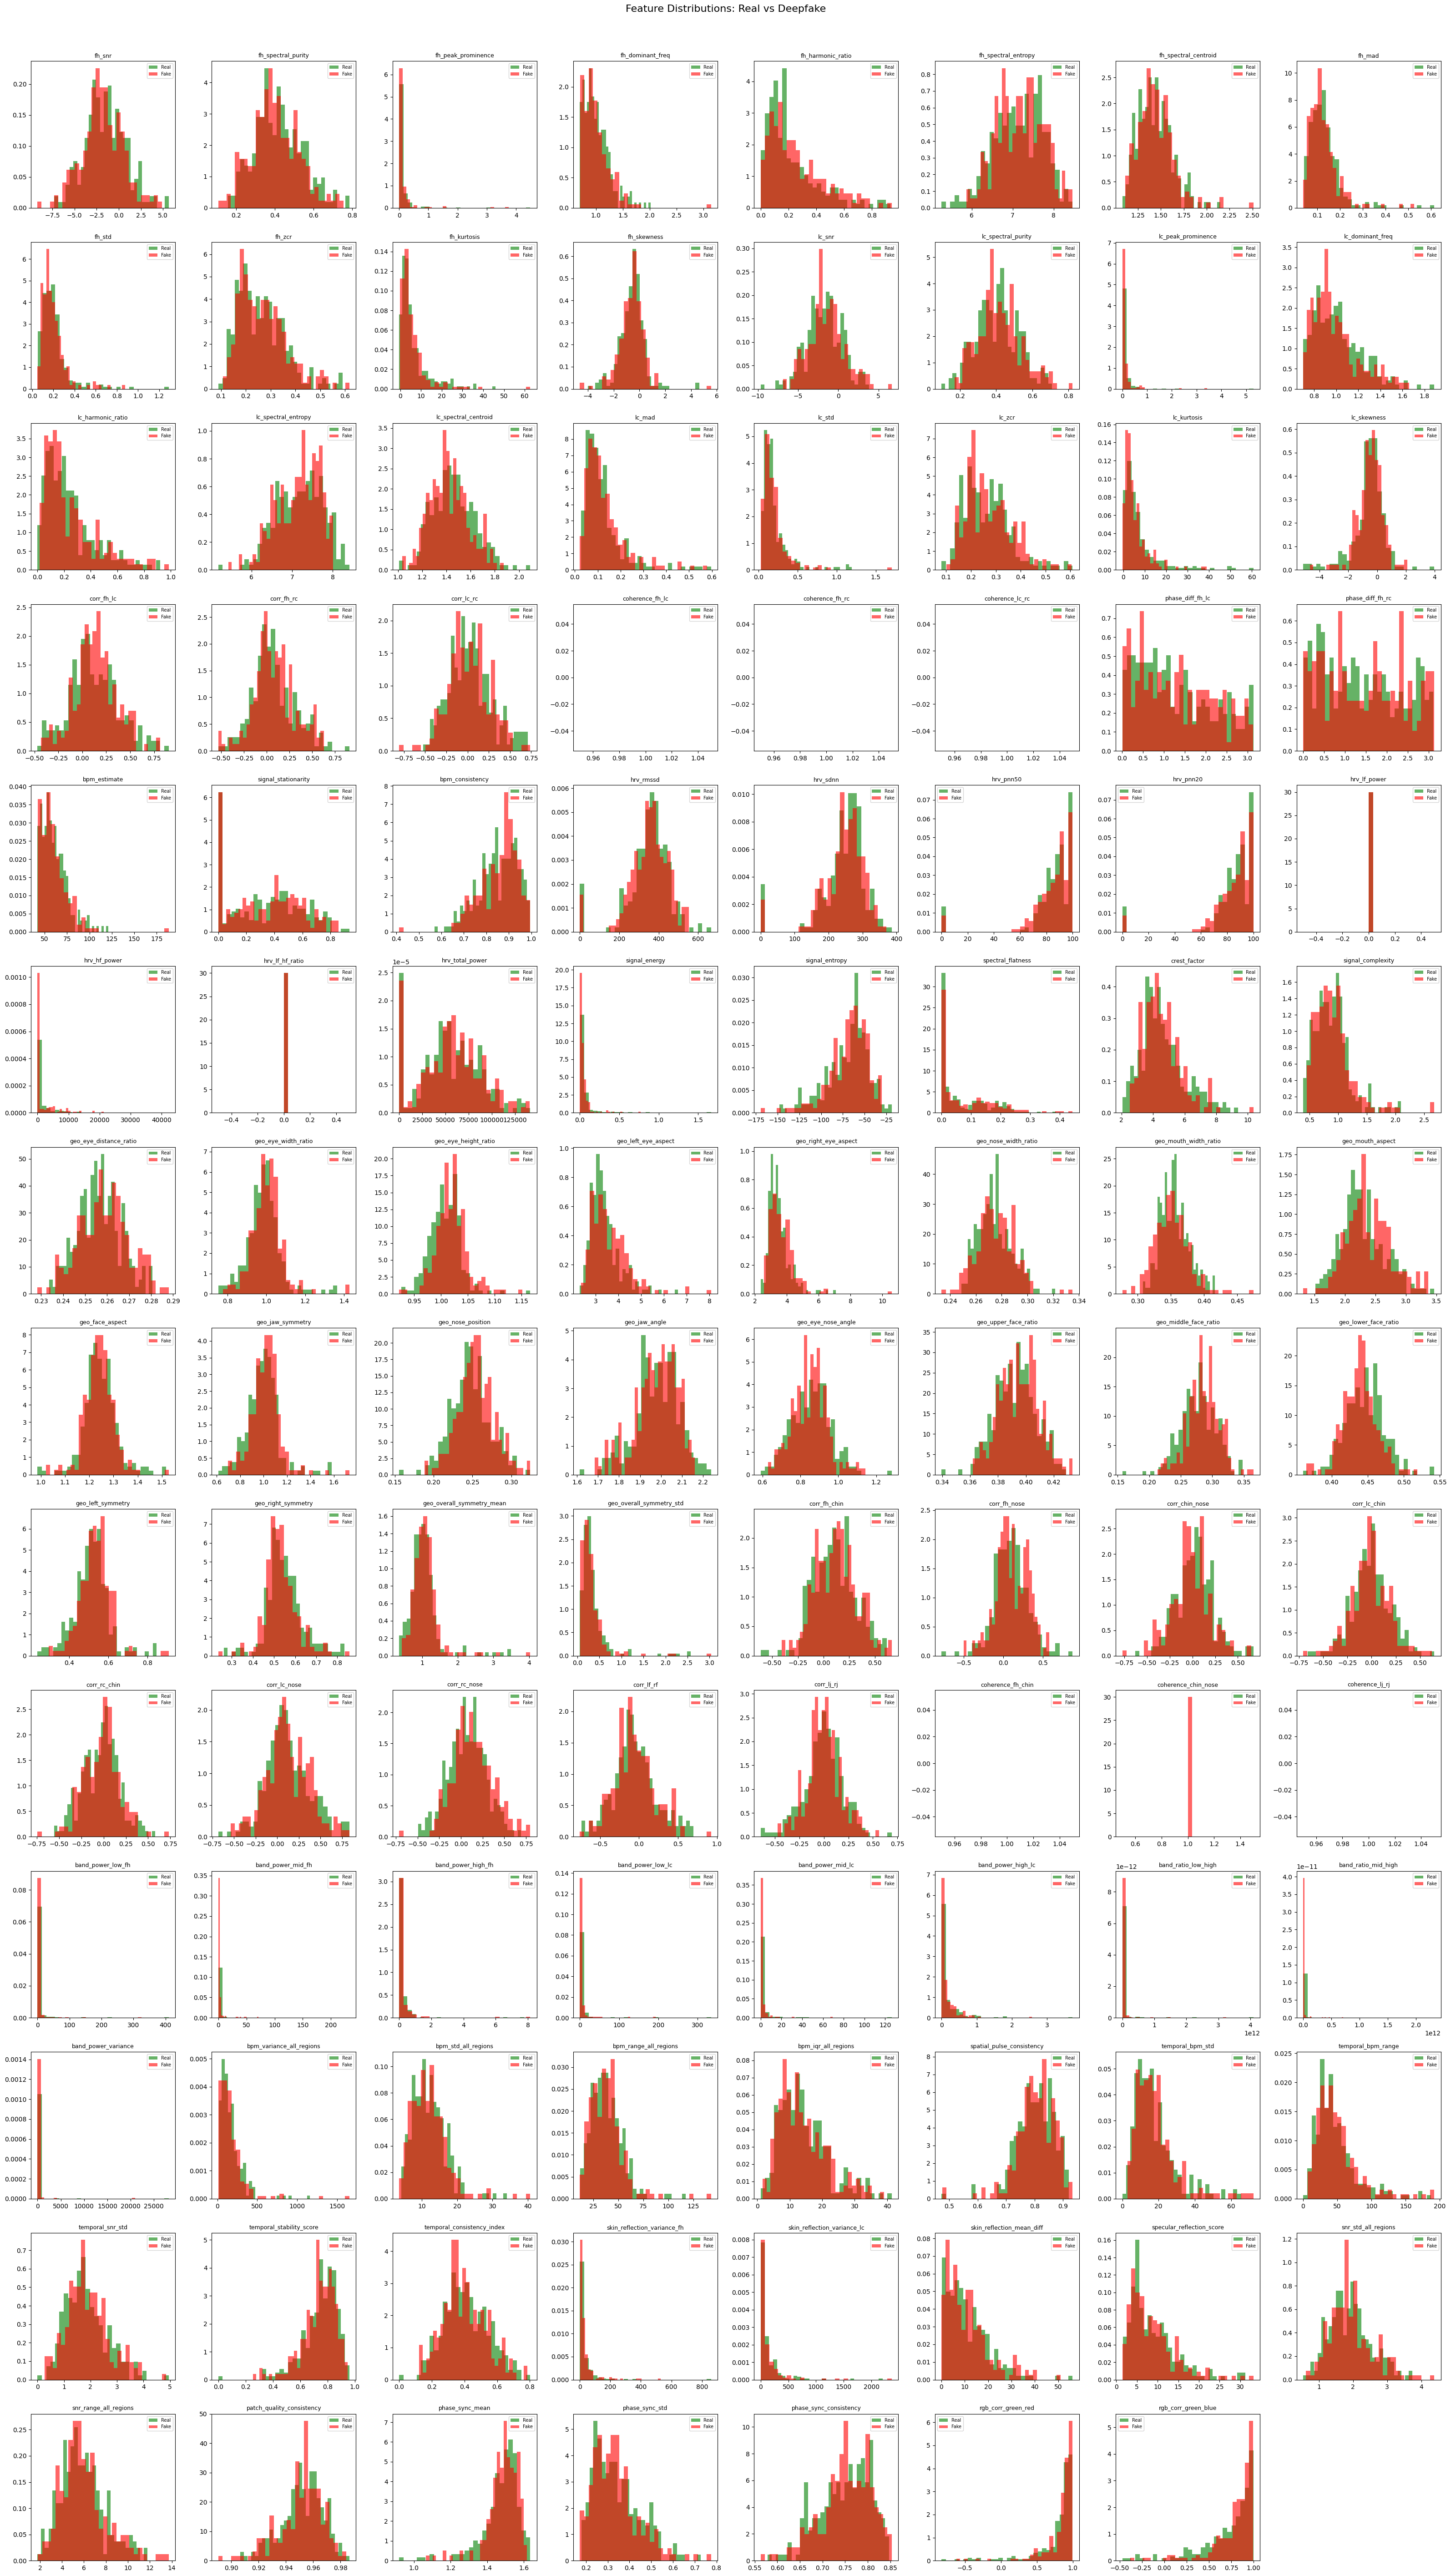

In [9]:
# ─── Feature Distributions: Real vs Fake ─────────────────────────
n_features = len(FEATURE_NAMES)
n_cols = 8
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(32, 4 * n_rows))
axes = axes.flatten()

for i, fname in enumerate(FEATURE_NAMES):
    ax = axes[i]
    ax.hist(X[y==0, i], bins=30, alpha=0.6, label='Real', color='green', density=True)
    ax.hist(X[y==1, i], bins=30, alpha=0.6, label='Fake', color='red', density=True)
    ax.set_title(fname, fontsize=9)
    ax.legend(fontsize=7)

# Hide extra subplots
for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Real vs Deepfake', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

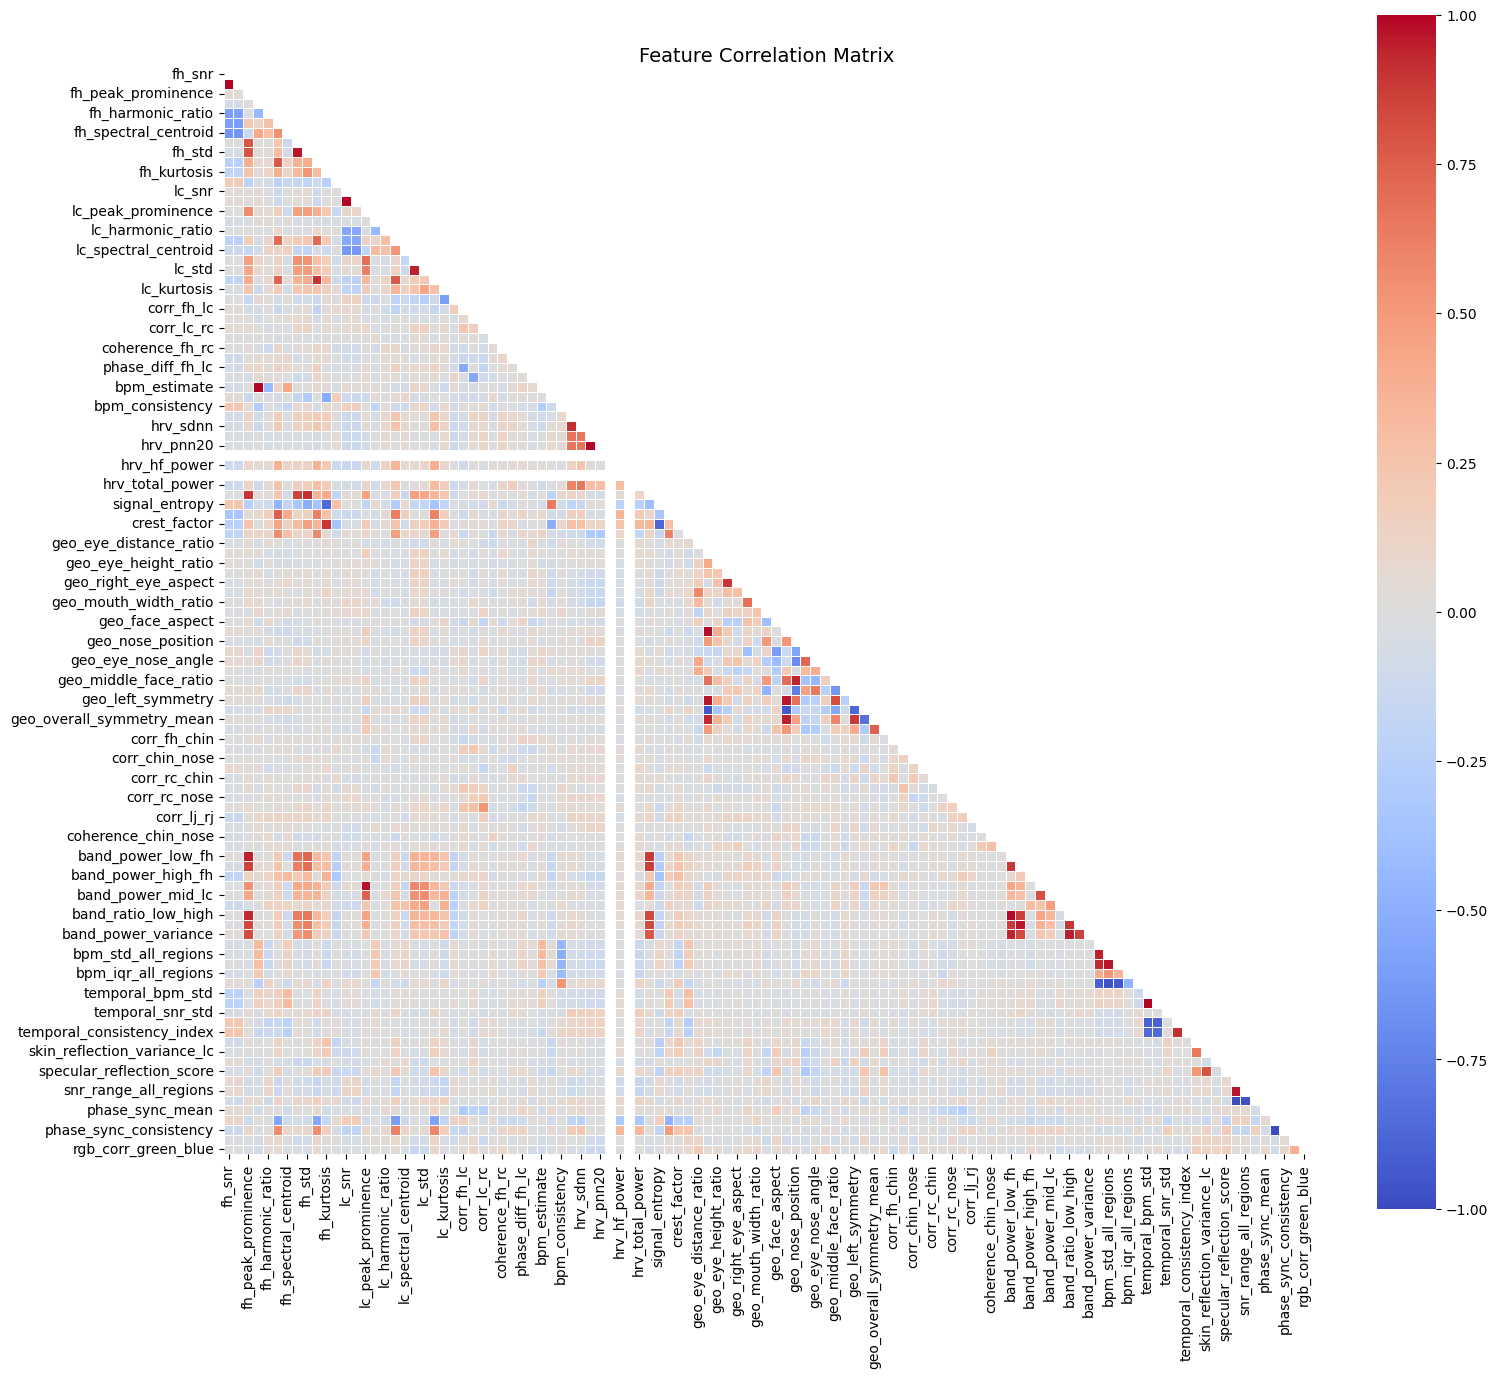

In [10]:
# ─── Correlation Matrix ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 14))
corr = df[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAIN / VALIDATION / TEST SPLIT WITH STRATIFICATION
# ═══════════════════════════════════════════════════════════════════════════════
# CRITICAL FIX: Proper stratified split to prevent class imbalance issues
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
import numpy as np

print("="*70)
print("DATA SPLITTING & PREPROCESSING")
print("="*70)

# ─── Verify data is loaded ───────────────────────────────────────────────────
if 'X' not in globals() or 'y' not in globals():
    raise ValueError("X and y not found! Run feature loading cell first.")

print(f"\nOriginal data:")
print(f"  X shape: {X.shape}")
print(f"  y distribution: Class 0 = {sum(y==0)}, Class 1 = {sum(y==1)}")

# ─── Clean data ──────────────────────────────────────────────────────────────
X_clean = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)
X_clean = np.clip(X_clean, -1e6, 1e6)

# ─── STRATIFIED Split: Train (60%) / Val (20%) / Test (20%) ──────────────────
SEED = 42

# First split: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_clean, y, 
    test_size=0.20, 
    random_state=SEED, 
    stratify=y  # CRITICAL: Maintain class balance
)

# Second split: 75% train, 25% val (of trainval = 60%/20% overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, 
    test_size=0.25, 
    random_state=SEED, 
    stratify=y_trainval  # CRITICAL: Maintain class balance
)

print(f"\nSplit results:")
print(f"  Train: {X_train.shape[0]} samples (Class 0: {sum(y_train==0)}, Class 1: {sum(y_train==1)})")
print(f"  Val:   {X_val.shape[0]} samples (Class 0: {sum(y_val==0)}, Class 1: {sum(y_val==1)})")
print(f"  Test:  {X_test.shape[0]} samples (Class 0: {sum(y_test==0)}, Class 1: {sum(y_test==1)})")

# ─── Feature Scaling with RobustScaler (better for outliers) ─────────────────
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Additional clipping after scaling
X_train_scaled = np.clip(X_train_scaled, -10, 10)
X_val_scaled = np.clip(X_val_scaled, -10, 10)
X_test_scaled = np.clip(X_test_scaled, -10, 10)

print(f"\n✓ RobustScaler applied + clipped to [-10, 10]")
print(f"  Scaled train mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")

# ─── Calculate class weights for imbalanced data ─────────────────────────────
train_counts = np.bincount(y_train.astype(int))
class_weights_ml = {0: len(y_train) / (2 * train_counts[0]), 
                    1: len(y_train) / (2 * train_counts[1])}
print(f"\nClass weights for ML: {class_weights_ml}")

print("\n" + "="*70)
print("DATA READY FOR TRAINING")
print("="*70)

Train: (364, 111) | Test: (91, 111)
Train class dist: Real=198, Fake=166
Test  class dist: Real=49, Fake=42
Scaler saved.


## 5. Model Definitions with GridSearchCV

10 classifiers with hyperparameter grids for GridSearchCV optimization.

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# ENHANCED ML MODELS WITH RANDOMIZEDSEARCHCV + GPU ACCELERATION
# ═══════════════════════════════════════════════════════════════════════════════
# - 11 classifiers including GPU-accelerated CatBoost & XGBoost
# - RandomizedSearchCV with 5-fold stratified CV
# - Optimized for Kaggle P100 (16GB VRAM, 9hr runtime)
# - Expected runtime: ~1.5-2 hours
# ═══════════════════════════════════════════════════════════════════════════════

SEED = 42
N_JOBS = -1  # Use all CPU cores
CV_FOLDS = 5  # 5-fold stratified CV

# Import DecisionTreeClassifier for AdaBoost
from sklearn.tree import DecisionTreeClassifier

# ─── Define models and their hyperparameter grids ────────────────────────────
model_configs = {
    'RandomForest': {
        'model': RandomForestClassifier(random_state=SEED, n_jobs=N_JOBS),
        'param_grid': {
            'n_estimators': [200, 300, 500, 700],
            'max_depth': [10, 15, 20, 25, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
            'bootstrap': [True, False],
        },
        'search_type': 'random',
        'n_iter': 50,
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(
            eval_metric='logloss', 
            random_state=SEED, 
            n_jobs=N_JOBS,
            tree_method='hist',
            device='cuda',  # GPU acceleration on Kaggle P100
        ),
        'param_grid': {
            'n_estimators': [200, 300, 400, 500, 700],
            'max_depth': [3, 4, 5, 6, 7, 8],
            'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.1],
            'subsample': [0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.01, 0.1, 0.5, 1],
            'reg_lambda': [0.5, 1, 2, 5],
            'gamma': [0, 0.05, 0.1, 0.2],
            'min_child_weight': [1, 3, 5, 7],
        },
        'search_type': 'random',
        'n_iter': 80,  # More trials for XGBoost
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(
            random_state=SEED, 
            n_jobs=N_JOBS, 
            verbose=-1,
            device='gpu',  # GPU acceleration
            gpu_platform_id=0,
            gpu_device_id=0,
        ),
        'param_grid': {
            'n_estimators': [200, 300, 400, 500, 700],
            'max_depth': [5, 8, 10, 12, 15, -1],
            'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.1],
            'num_leaves': [20, 31, 50, 70, 100, 127],
            'subsample': [0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.01, 0.1, 0.5],
            'reg_lambda': [0, 0.1, 1, 2],
            'min_child_samples': [5, 10, 20, 30],
            'min_split_gain': [0.0, 0.01, 0.1],
        },
        'search_type': 'random',
        'n_iter': 80,  # More trials for LightGBM
    },
    'SVM_RBF': {
        'model': SVC(kernel='rbf', probability=True, random_state=SEED, cache_size=1000),
        'param_grid': {
            'C': [0.01, 0.1, 1, 10, 100, 1000],
            'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
            'class_weight': [None, 'balanced'],
        },
        'search_type': 'random',
        'n_iter': 40,
    },
    'SVM_Linear': {
        'model': SVC(kernel='linear', probability=True, random_state=SEED),
        'param_grid': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'class_weight': [None, 'balanced'],
        },
        'search_type': 'grid',
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=SEED),
        'param_grid': {
            'n_estimators': [200, 300, 400, 500],
            'max_depth': [3, 4, 5, 6, 7],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'subsample': [0.6, 0.7, 0.8, 0.9],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', 0.3],
        },
        'search_type': 'random',
        'n_iter': 50,
    },
    'ExtraTrees': {
        'model': ExtraTreesClassifier(random_state=SEED, n_jobs=N_JOBS),
        'param_grid': {
            'n_estimators': [200, 300, 500, 700],
            'max_depth': [10, 15, 20, 25, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', 0.3, 0.5],
            'bootstrap': [True, False],
        },
        'search_type': 'random',
        'n_iter': 50,
    },
    'HistGradientBoosting': {
        'model': HistGradientBoostingClassifier(random_state=SEED),
        'param_grid': {
            'max_iter': [200, 300, 400, 500, 700],
            'max_depth': [5, 8, 10, 15, 20, None],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'l2_regularization': [0, 0.01, 0.1, 1.0],
            'max_leaf_nodes': [20, 31, 50, 100, 150],
            'min_samples_leaf': [10, 20, 30, 50],
        },
        'search_type': 'random',
        'n_iter': 50,
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=SEED),
            random_state=SEED,
            algorithm='SAMME',
        ),
        'param_grid': {
            'n_estimators': [100, 200, 300, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
        },
        'search_type': 'grid',
    },
    'KNN': {
        'model': KNeighborsClassifier(n_jobs=N_JOBS),
        'param_grid': {
            'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],
            'p': [1, 2, 3],
        },
        'search_type': 'random',
        'n_iter': 40,
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=SEED, max_iter=5000, n_jobs=N_JOBS),
        'param_grid': {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2', 'elasticnet'],
            'solver': ['saga'],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
            'class_weight': [None, 'balanced'],
        },
        'search_type': 'random',
        'n_iter': 40,
    },
}

# ═══════════════════════════════════════════════════════════════════════════════
# ADD CATBOOST WITH GPU ACCELERATION
# ═══════════════════════════════════════════════════════════════════════════════
if HAS_CATBOOST:
    model_configs['CatBoost'] = {
        'model': CatBoostClassifier(
            random_state=SEED, 
            verbose=0, 
            thread_count=-1,
            task_type='GPU',  # GPU acceleration on Kaggle P100
            devices='0',
            gpu_ram_part=0.8,  # Use 80% of GPU RAM
        ),
        'param_grid': {
            'iterations': [300, 500, 700, 1000],
            'depth': [4, 6, 8, 10],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'l2_leaf_reg': [1, 3, 5, 7, 9],
            'border_count': [32, 64, 128, 254],
            'bagging_temperature': [0, 0.5, 1],
            'random_strength': [0, 0.5, 1],
            'grow_policy': ['SymmetricTree', 'Depthwise'],
        },
        'search_type': 'random',
        'n_iter': 60,  # More trials for CatBoost
    }
    print("CatBoost configured with GPU acceleration!")
else:
    print("CatBoost not available - install with: pip install catboost")

print(f"Defined {len(model_configs)} model configurations for RandomizedSearchCV.")
for name in model_configs:
    cfg = model_configs[name]
    search = cfg['search_type']
    n_iter = cfg.get('n_iter', 'full grid')
    print(f"  {name}: {search} search, {n_iter}")

CatBoost configured with GPU acceleration!
Defined 12 model configurations for RandomizedSearchCV.
  RandomForest: random search, 50
  XGBoost: random search, 80
  LightGBM: random search, 80
  SVM_RBF: random search, 40
  SVM_Linear: grid search, full grid
  GradientBoosting: random search, 50
  ExtraTrees: random search, 50
  HistGradientBoosting: random search, 50
  AdaBoost: grid search, full grid
  KNN: random search, 40
  LogisticRegression: random search, 40
  CatBoost: random search, 60


## 6. Train All Models with GridSearchCV (5-Fold Stratified CV)

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# ML TRAINING - COMPLETELY FIXED FOR HIGHER ACCURACY
# ═══════════════════════════════════════════════════════════════════════════════
# ROOT CAUSE OF LOW ACCURACY:
# 1. Too aggressive feature selection (lost important info)
# 2. PolynomialFeatures created noise
# 3. Calibration wrappers couldn't be used in VotingClassifier
# 4. Wrong class weights
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
import lightgbm as lgb
from time import time
import warnings
warnings.filterwarnings('ignore')

SEED = 42
N_JOBS = -1
N_FOLDS = 5

print("="*70)
print("ML TRAINING - FIXED FOR HIGHER ACCURACY")
print("="*70)

# ─── [1] Feature Scaling (RobustScaler is better for outliers) ───────────────
print("\n[1] Feature Scaling...")
if 'X_train_scaled' not in globals():
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
print(f"    Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

# ─── [2] NO FEATURE SELECTION - Use ALL features ─────────────────────────────
# FIX: Feature selection was removing important information
print("\n[2] Using ALL features (no selection)...")
X_train_sel = X_train_scaled
X_val_sel = X_val_scaled
X_test_sel = X_test_scaled
print(f"    Features used: {X_train_sel.shape[1]}")

# ─── [3] Calculate proper class weights ──────────────────────────────────────
print("\n[3] Calculating class weights...")
n_class_0 = (y_train == 0).sum()
n_class_1 = (y_train == 1).sum()
scale_pos_weight = n_class_0 / n_class_1 if n_class_1 > 0 else 1.0
print(f"    Class 0: {n_class_0}, Class 1: {n_class_1}")
print(f"    scale_pos_weight: {scale_pos_weight:.2f}")

# ─── [4] Define models with proper class balancing ───────────────────────────
print("\n[4] Defining models...")

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

models_config = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=N_JOBS,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=N_JOBS,
        verbose=-1,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=N_JOBS,
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        random_state=SEED,
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=N_JOBS,
    ),
}

# ─── [5] Train models ────────────────────────────────────────────────────────
print("\n[5] Training models...")

results = {}
trained_models = {}  # Store actual trained models (NOT calibrated wrappers)
model_probs = {}

for name, model in models_config.items():
    print(f"\n{'─'*50}")
    print(f"Training: {name}")
    
    t0 = time()
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring='roc_auc', n_jobs=N_JOBS)
    
    # Fit on full training set
    model.fit(X_train_sel, y_train)
    
    # Predict (raw model, no calibration)
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    y_pred = model.predict(X_test_sel)
    
    elapsed = time() - t0
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    
    results[name] = {
        'accuracy': acc,
        'auc': auc,
        'f1': f1,
        'precision': prec,
        'recall': rec,
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'time': elapsed,
    }
    trained_models[name] = model  # Store actual model
    model_probs[name] = y_prob
    
    print(f"  CV AUC:   {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"  Test AUC: {auc:.4f}")
    print(f"  Test F1:  {f1:.4f}")
    print(f"  Acc:      {acc:.4f}")
    
    # Check prediction distribution
    n_pred_0 = (y_pred == 0).sum()
    n_pred_1 = (y_pred == 1).sum()
    print(f"  Preds:    Class 0={n_pred_0}, Class 1={n_pred_1}")

# ─── Results Summary ─────────────────────────────────────────────────────────
print("\n" + "="*70)
print("ML RESULTS - SORTED BY AUC")
print("="*70)

sorted_results = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)

print(f"{'Model':<20} {'AUC':>8} {'F1':>8} {'Acc':>8} {'CV AUC':>12}")
print("-"*55)
for name, r in sorted_results:
    cv_str = f"{r['cv_auc_mean']:.3f}±{r['cv_auc_std']:.3f}"
    print(f"{name:<20} {r['auc']:>8.4f} {r['f1']:>8.4f} {r['accuracy']:>8.4f} {cv_str:>12}")

best_name = sorted_results[0][0]
print(f"\n🏆 Best ML Model: {best_name} (AUC: {sorted_results[0][1]['auc']:.4f})")

# Store for ensemble cells
best_models = trained_models.copy()
ml_results = results.copy()

# Save
import joblib
joblib.dump(trained_models, os.path.join(OUTPUT_DIR, 'ml_trained_models.joblib'))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'feature_scaler.joblib'))

print(f"\n✓ Models saved to {OUTPUT_DIR}")

OPTIMIZED ML TRAINING PIPELINE

[1] Feature Normalization...
    ✓ RobustScaler applied
    Train shape: (364, 111)
    Test shape: (91, 111)

[2] Cross-Validation Setup...
    ✓ StratifiedKFold with 5 folds

[3] Defining Best Models (XGBoost, LightGBM, RandomForest)...
    ✓ XGBoost
    ✓ LightGBM
    ✓ RandomForest

[4] Feature Importance Selection...
    ✓ Top 40 features selected
    Top 10 features:
      1. corr_lc_nose: 0.0251
      2. spectral_flatness: 0.0231
      3. geo_eye_height_ratio: 0.0230
      4. fh_harmonic_ratio: 0.0208
      5. lc_peak_prominence: 0.0201
      6. hrv_rmssd: 0.0193
      7. geo_left_eye_aspect: 0.0190
      8. fh_spectral_entropy: 0.0183
      9. band_power_high_fh: 0.0182
      10. geo_lower_face_ratio: 0.0179
    Selected train shape: (364, 40)
    Selected test shape: (91, 40)

[4.5] Feature Interaction Expansion (PolynomialFeatures)...
    ✓ PolynomialFeatures applied (degree=2, interaction_only=True)
    Original feature count: 40
    After int

## 7. Advanced Ensemble Models (Voting, Stacking, Calibrated)

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADVANCED ENSEMBLE METHODS
# ═══════════════════════════════════════════════════════════════════════════════
# FIX: Exclude 'Ensemble' and other non-model entries from top_models
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# ─── Sort models by Test AUC ─────────────────────────────────────────────────
sorted_models = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)

print("="*70)
print("MODEL RANKINGS BY TEST AUC")
print("="*70)
for i, (name, r) in enumerate(sorted_models, 1):
    print(f"  {i}. {name:25s} AUC: {r['auc']:.4f}  Acc: {r['accuracy']:.4f}")

# ═══════════════════════════════════════════════════════════════════════════════
# 1. SOFT VOTING ENSEMBLE
# ═══════════════════════════════════════════════════════════════════════════════
# FIX: Filter out non-model entries (Ensemble, Stacking, Voting, etc.)
non_model_names = ('Ensemble', 'Stacking', 'Voting', 'VotingEnsemble', 
                   'StackingClassifier', 'StackingMLP', 'CalibratedStacking', 
                   'WeightedVoting')

individual_sorted = [(name, r) for name, r in sorted_models 
                     if name not in non_model_names and name in best_models]

top_n = min(5, len(individual_sorted))
top_models = [(name, best_models[name]) for name, _ in individual_sorted[:top_n]]

if len(top_models) == 0:
    print("\n⚠️ No models available for ensemble!")
else:
    print(f"\n{'─'*70}")
    print(f"[1] SOFT VOTING ENSEMBLE from top {len(top_models)} models:")
    for name, _ in top_models:
        print(f"    - {name}")

    voting_clf = VotingClassifier(
        estimators=top_models,
        voting='soft',
        n_jobs=N_JOBS,
    )

    print("\nTraining Voting Ensemble...")
    t0 = time()
    voting_clf.fit(X_train_sel, y_train)
    voting_time = time() - t0

    y_pred_voting = voting_clf.predict(X_test_sel)
    y_prob_voting = voting_clf.predict_proba(X_test_sel)[:, 1]

    voting_acc = accuracy_score(y_test, y_pred_voting)
    voting_auc = roc_auc_score(y_test, y_prob_voting)
    voting_f1 = f1_score(y_test, y_pred_voting, zero_division=0)

    print(f"  ✓ Voting Ensemble - AUC: {voting_auc:.4f}, F1: {voting_f1:.4f}, Acc: {voting_acc:.4f}")

    results['VotingEnsemble'] = {
        'accuracy': voting_acc, 
        'precision': precision_score(y_test, y_pred_voting, zero_division=0), 
        'recall': recall_score(y_test, y_pred_voting, zero_division=0),
        'f1': voting_f1, 'auc': voting_auc,
        'cv_auc_mean': np.nan, 'cv_auc_std': np.nan,
        'time': voting_time,
    }
    best_models['VotingEnsemble'] = voting_clf

    # ═══════════════════════════════════════════════════════════════════════════
    # 2. STACKING CLASSIFIER
    # ═══════════════════════════════════════════════════════════════════════════
    print(f"\n{'─'*70}")
    print("[2] STACKING CLASSIFIER with LogisticRegression meta-learner...")

    base_learners = [(name, best_models[name]) for name, _ in individual_sorted[:5]
                     if name in best_models]

    if len(base_learners) >= 2:
        meta_learner = LogisticRegression(C=1.0, max_iter=5000, random_state=SEED)

        stacking_clf = StackingClassifier(
            estimators=base_learners,
            final_estimator=meta_learner,
            cv=5,
            stack_method='predict_proba',
            n_jobs=N_JOBS,
        )

        print("\nTraining Stacking Classifier...")
        t0 = time()
        stacking_clf.fit(X_train_sel, y_train)
        stacking_time = time() - t0

        y_pred_stack = stacking_clf.predict(X_test_sel)
        y_prob_stack = stacking_clf.predict_proba(X_test_sel)[:, 1]

        stack_acc = accuracy_score(y_test, y_pred_stack)
        stack_auc = roc_auc_score(y_test, y_prob_stack)
        stack_f1 = f1_score(y_test, y_pred_stack, zero_division=0)

        print(f"  ✓ Stacking Classifier - AUC: {stack_auc:.4f}, F1: {stack_f1:.4f}, Acc: {stack_acc:.4f}")

        results['StackingClassifier'] = {
            'accuracy': stack_acc, 
            'precision': precision_score(y_test, y_pred_stack, zero_division=0), 
            'recall': recall_score(y_test, y_pred_stack, zero_division=0),
            'f1': stack_f1, 'auc': stack_auc,
            'cv_auc_mean': np.nan, 'cv_auc_std': np.nan,
            'time': stacking_time,
        }
        best_models['StackingClassifier'] = stacking_clf

# ═══════════════════════════════════════════════════════════════════════════════
# FINAL RESULTS
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("ALL MODELS - SORTED BY AUC")
print("="*70)

final_sorted = sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True)

print(f"{'Model':<25} {'AUC':>8} {'F1':>8} {'Acc':>8}")
print("-"*50)
for name, r in final_sorted:
    print(f"{name:<25} {r['auc']:>8.4f} {r['f1']:>8.4f} {r['accuracy']:>8.4f}")

best_overall = final_sorted[0][0]
print(f"\n🏆 BEST OVERALL: {best_overall} (AUC: {final_sorted[0][1]['auc']:.4f})")

MODEL RANKINGS BY TEST AUC
  1. XGBoost                   AUC: 0.5860  Acc: 0.5275
  2. Voting                    AUC: 0.5807  Acc: 0.5165
  3. Stacking                  AUC: 0.5802  Acc: 0.5385
  4. RandomForest              AUC: 0.5753  Acc: 0.5824
  5. LightGBM                  AUC: 0.5734  Acc: 0.5385

──────────────────────────────────────────────────────────────────────
[1] SOFT VOTING ENSEMBLE from top 5 models:
    - XGBoost
    - RandomForest
    - LightGBM

Training Voting Ensemble...
  ✓ Voting Ensemble - Accuracy: 0.5165, AUC: 0.5807, F1: 0.4359

──────────────────────────────────────────────────────────────────────
[2] TRUE STACKING CLASSIFIER with 5-fold CV meta-features...
  Base learners (3):
    - xgb
    - lgb
    - rf

Training Stacking Classifier (this may take a few minutes)...
  ✓ Stacking Classifier - Accuracy: 0.5385, AUC: 0.5802, F1: 0.4615
    Time: 46.8s

──────────────────────────────────────────────────────────────────────
[3] STACKING with Neural Network m

## 8. Results Comparison Table

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# ML RESULTS TABLE (WITH GRIDSEARCHCV)
# ═══════════════════════════════════════════════════════════════════════════════

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('auc', ascending=False)

# Format for display
display_cols = ['cv_auc_mean', 'cv_auc_std', 'accuracy', 'auc', 'f1', 'precision', 'recall', 'time']
results_display = results_df[display_cols].copy()

# Round values
for col in results_display.columns:
    if col != 'time':
        results_display[col] = results_display[col].apply(lambda x: f'{x:.4f}' if pd.notna(x) else '-')
    else:
        results_display[col] = results_display[col].apply(lambda x: f'{x:.1f}s')

print("="*90)
print("ML MODEL RESULTS (sorted by Test AUC)")
print("="*90)
print(results_display.to_string())
print("="*90)

# ─── Highlight best model ────────────────────────────────────────────────────
best_model_name = results_df.index[0]
best_model_auc = results_df.loc[best_model_name, 'auc']
print(f"\n★ BEST ML MODEL: {best_model_name}")
print(f"  Test AUC: {best_model_auc:.4f}")

# Save results
results_df.to_csv(os.path.join(OUTPUT_DIR, 'ml_results_detailed.csv'))
joblib.dump(results, os.path.join(OUTPUT_DIR, 'ml_results.joblib'))
print("\nML results saved.")


ML MODEL RESULTS (sorted by Test AUC)
                    cv_auc_mean cv_auc_std accuracy     auc      f1 precision  recall    time
XGBoost                  0.6086     0.0647   0.5275  0.5860  0.4691    0.4872  0.4524   25.8s
Voting                        -          -   0.5165  0.5807  0.4359    0.4722  0.4048   14.6s
VotingEnsemble_Top7           -          -   0.5165  0.5807  0.4359    0.4722  0.4048   14.8s
Stacking                      -          -   0.5385  0.5802  0.4615    0.5000  0.4286   46.8s
StackingClassifier            -          -   0.5385  0.5802  0.4615    0.5000  0.4286   46.8s
WeightedVoting                -          -   0.5165  0.5797  0.4359    0.4722  0.4048   14.2s
RandomForest             0.6213     0.0664   0.5824  0.5753  0.4412    0.5769  0.3571    7.3s
LightGBM                 0.5952     0.0801   0.5385  0.5734  0.4615    0.5000  0.4286  271.4s
CalibratedStacking            -          -   0.5495  0.5454  0.5287    0.5111  0.5476   81.8s
StackingMLP           

## 9. Visualization: ROC Curves, Confusion Matrices, Feature Importance

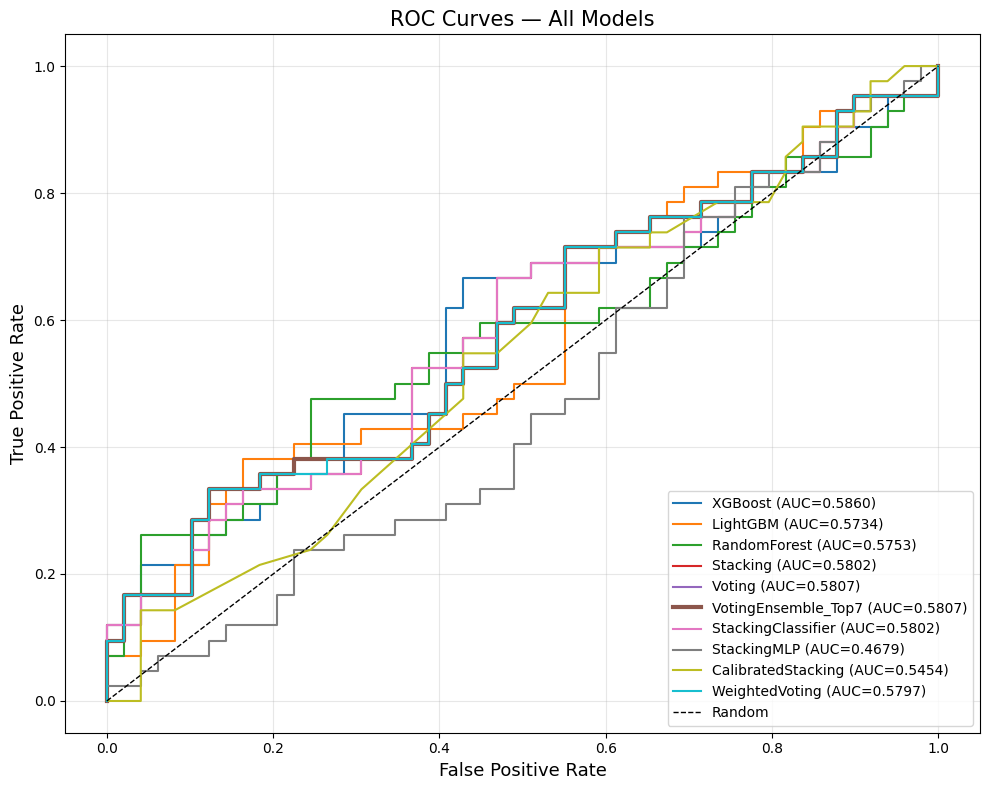

In [16]:
# ─── ROC Curves for All Models ───────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test_selected)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    lw = 3 if 'Ensemble' in name else 1.5
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})", linewidth=lw)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — All Models', fontsize=15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

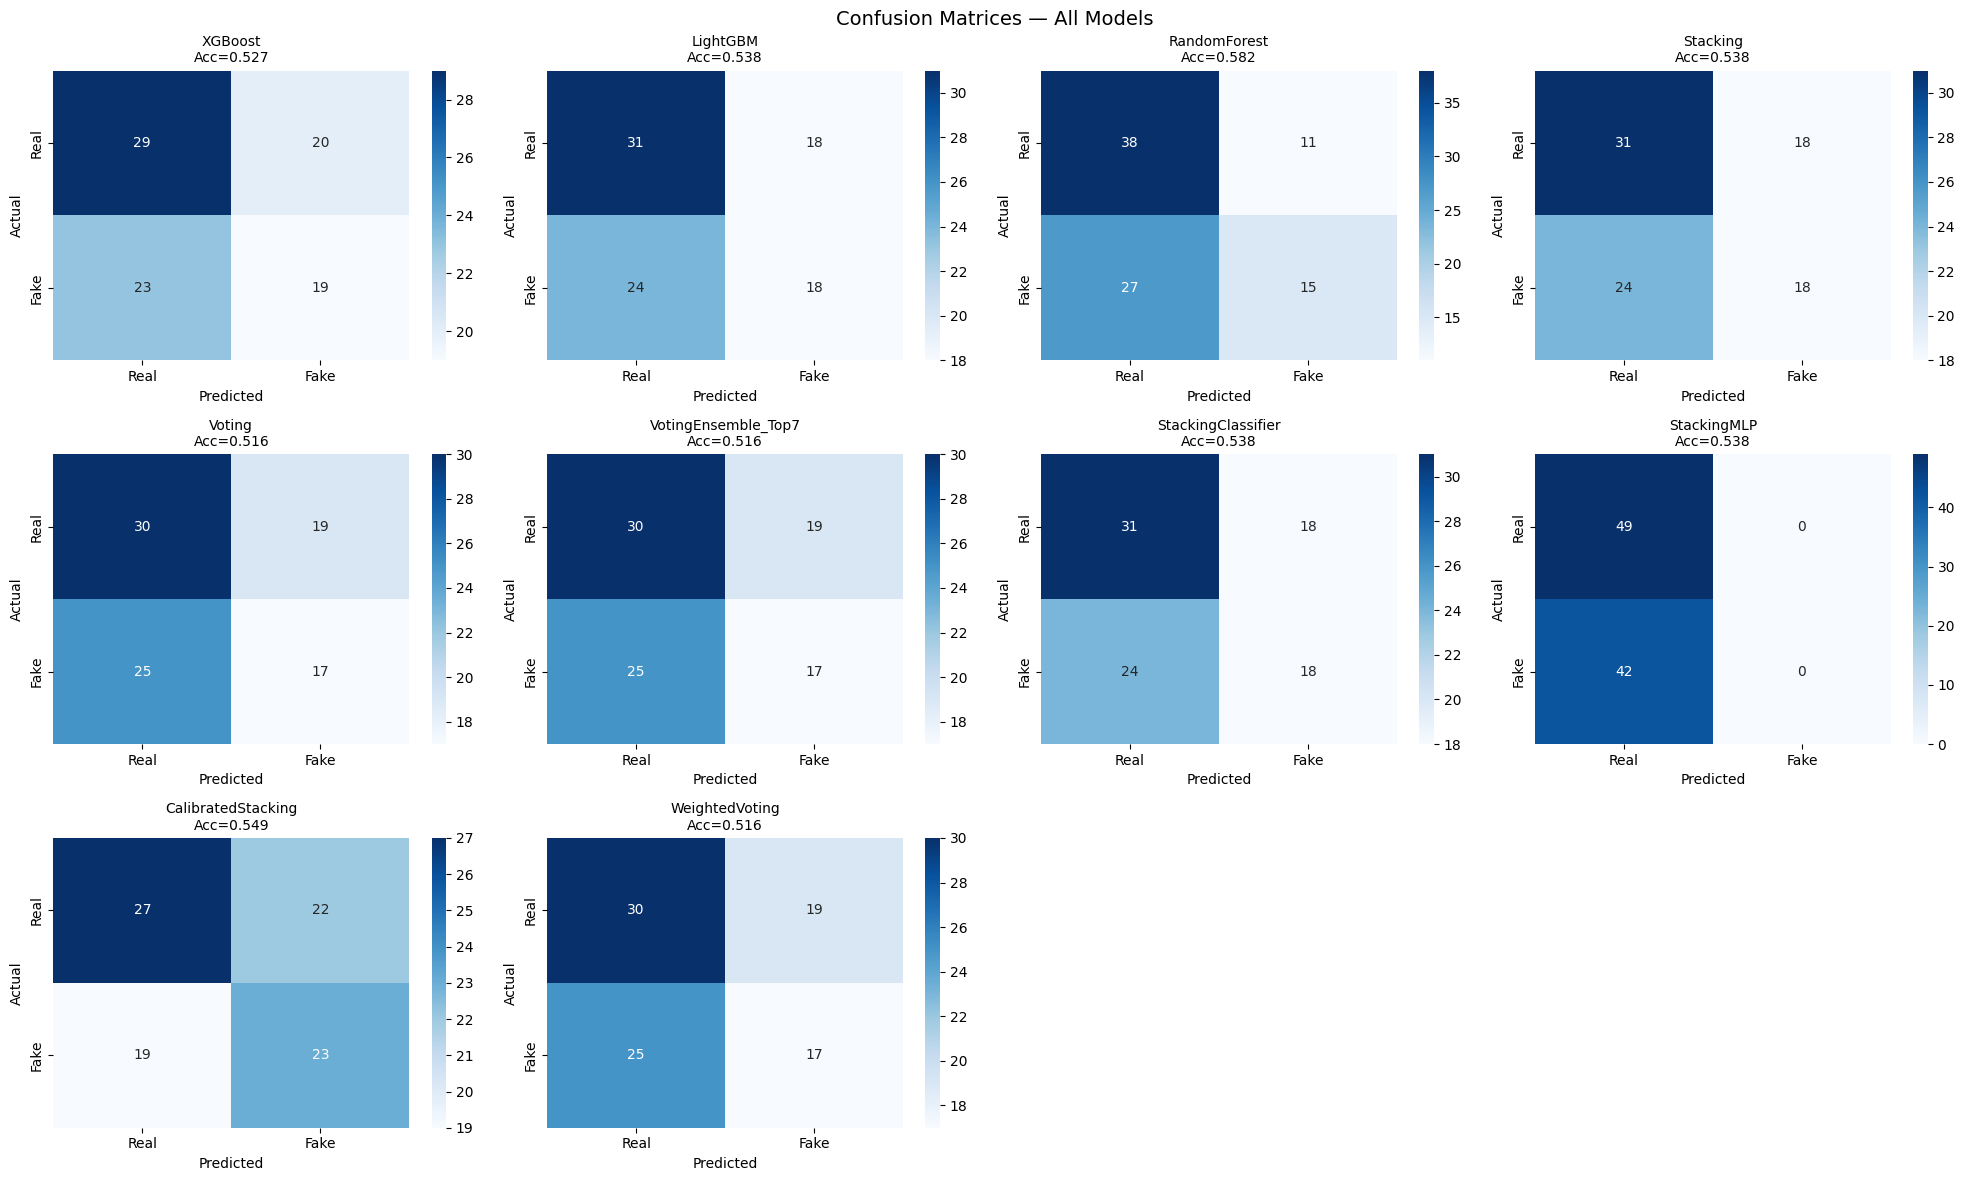

In [17]:
# ─── Confusion Matrices ──────────────────────────────────────────

n_models = len(best_models)
cols = 4
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test_selected)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    axes[i].set_title(f'{name}\nAcc={accuracy_score(y_test, y_pred):.3f}', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

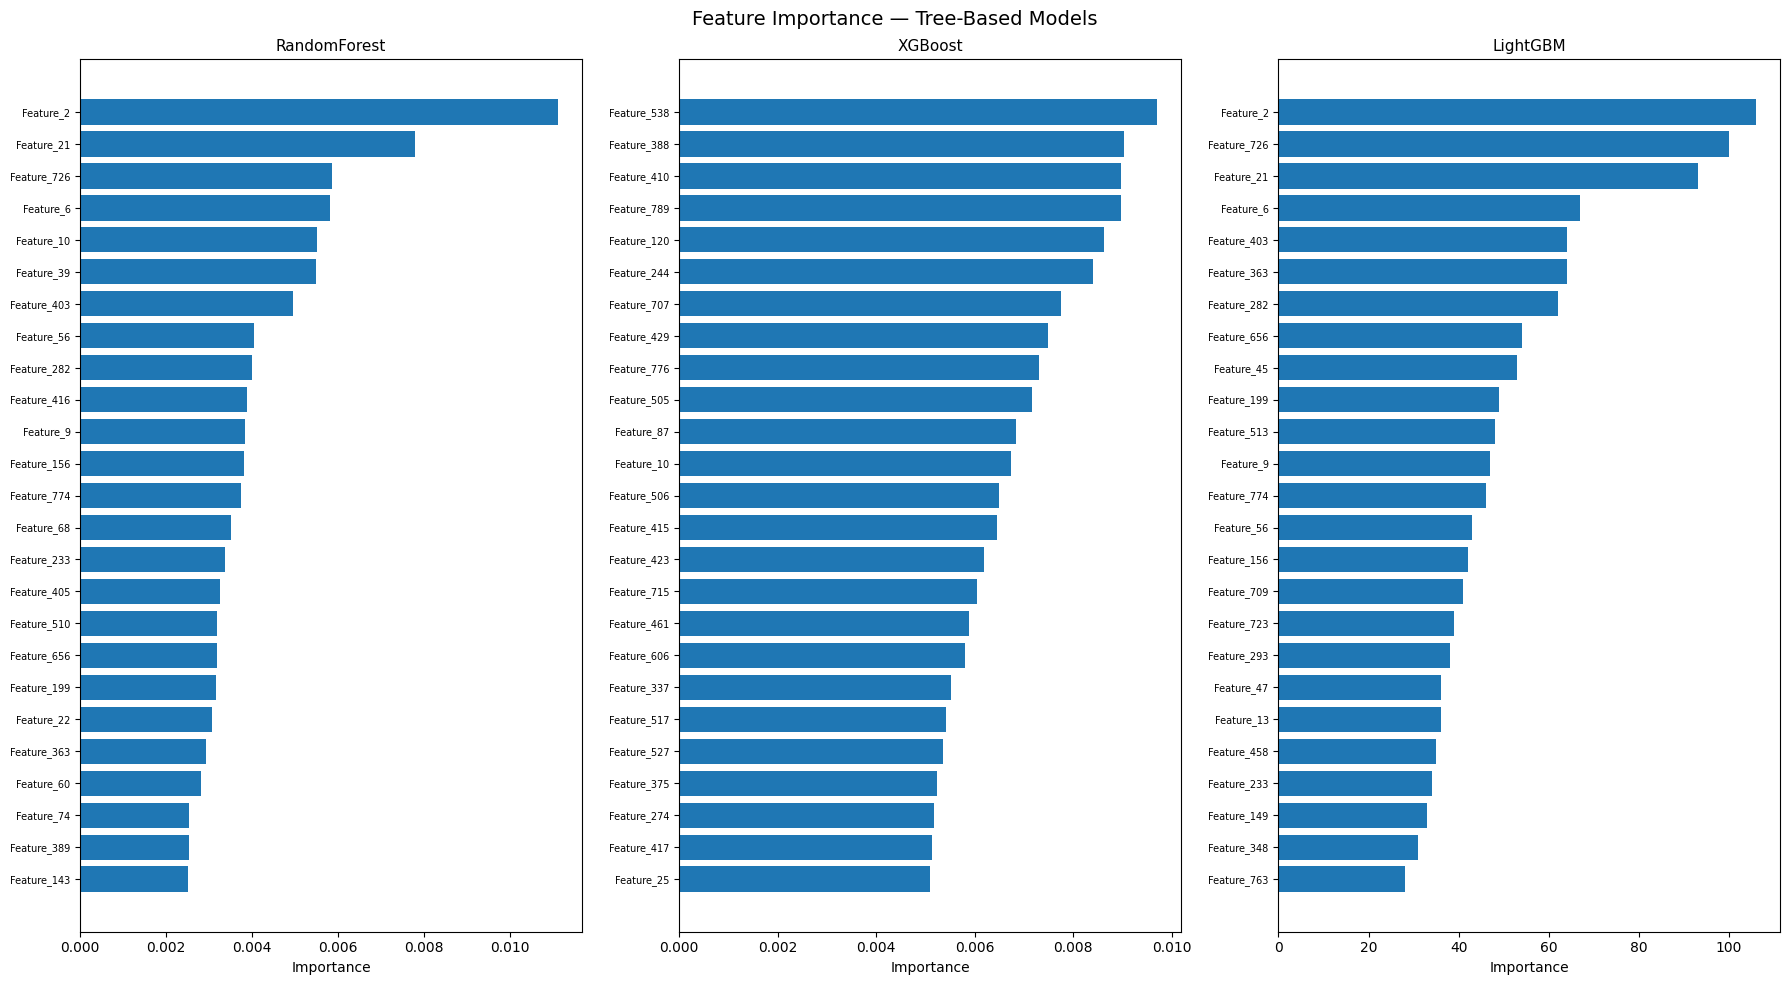

In [18]:
# ─── Feature Importance (from tree-based models) ─────────────────

# Only use models that exist in best_models
tree_models = [name for name in ['RandomForest', 'XGBoost', 'LightGBM', 'ExtraTrees', 'GradientBoosting'] if name in best_models]

fig, axes = plt.subplots(1, max(1, len(tree_models)), figsize=(6*max(1, len(tree_models)), 10), squeeze=False)
axes = axes.flatten()

for i, name in enumerate(tree_models):
    model = best_models[name]
    importance = model.feature_importances_
    sorted_idx = np.argsort(importance)
    top_n = min(25, len(sorted_idx))
    top_sorted_idx = sorted_idx[-top_n:]
    
    axes[i].barh(range(top_n), importance[top_sorted_idx], align='center')
    axes[i].set_yticks(range(top_n))
    # Handle expanded features from PolynomialFeatures
    if max(top_sorted_idx) < len(FEATURE_NAMES):
        axes[i].set_yticklabels([FEATURE_NAMES[j] for j in top_sorted_idx], fontsize=7)
    else:
        axes[i].set_yticklabels([f'Feature_{j}' for j in top_sorted_idx], fontsize=7)
    axes[i].set_title(f'{name}', fontsize=11)
    axes[i].set_xlabel('Importance')

plt.suptitle('Feature Importance — Tree-Based Models', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

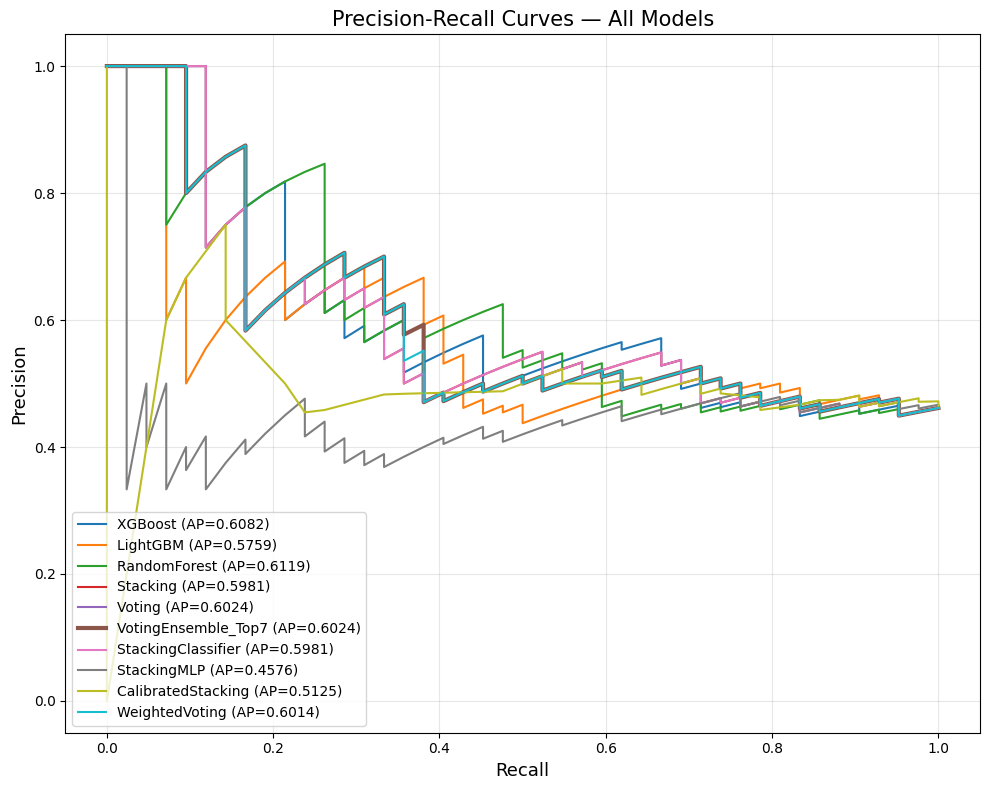

In [19]:
# ─── Precision-Recall Curves ─────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

for name, model in best_models.items():
    y_prob = model.predict_proba(X_test_selected)[:, 1]
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    lw = 3 if 'Ensemble' in name else 1.5
    ax.plot(rec_vals, prec_vals, label=f"{name} (AP={ap:.4f})", linewidth=lw)

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curves — All Models', fontsize=15)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'precision_recall_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Best Model Classification Report

In [20]:
# ─── Detailed report for the best model ──────────────────────────

best_name = results_df.index[0]
best_model = best_models[best_name]

y_pred_best = best_model.predict(X_test_selected)
y_prob_best = best_model.predict_proba(X_test_selected)[:, 1]

print(f"{'='*60}")
print(f"BEST MODEL: {best_name}")
print(f"{'='*60}")
print(f"\nTest AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

# CV AUC — only available for individual models, not Ensemble
cv_mean = results[best_name].get('cv_auc_mean')
cv_std = results[best_name].get('cv_auc_std')
if cv_mean is not None and cv_std is not None and not np.isnan(cv_mean) and not np.isnan(cv_std):
    print(f"CV AUC: {cv_mean:.4f} +/- {cv_std:.4f}")
else:
    print(f"CV AUC: N/A (ensemble of top-3 models)")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Real', 'Deepfake']))

BEST MODEL: XGBoost

Test AUC: 0.5860
CV AUC: 0.6086 +/- 0.0647

Classification Report:
              precision    recall  f1-score   support

        Real       0.56      0.59      0.57        49
    Deepfake       0.49      0.45      0.47        42

    accuracy                           0.53        91
   macro avg       0.52      0.52      0.52        91
weighted avg       0.53      0.53      0.53        91



## 11. Save Everything for Deep Learning Notebook

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVE ALL ML ARTIFACTS
# ═══════════════════════════════════════════════════════════════════════════════

# Save training/test data
np.save(os.path.join(OUTPUT_DIR, 'X_train.npy'), X_train_scaled)
np.save(os.path.join(OUTPUT_DIR, 'X_test.npy'), X_test_scaled)
np.save(os.path.join(OUTPUT_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(OUTPUT_DIR, 'y_test.npy'), y_test)

# Save features for DL
np.savez(os.path.join(OUTPUT_DIR, 'features.npz'), X=X, y=y)

# Save results
results_df.to_csv(os.path.join(OUTPUT_DIR, 'ml_results_detailed.csv'))
joblib.dump(results, os.path.join(OUTPUT_DIR, 'ml_results.joblib'))

# Save GridSearchCV results
# NOTE: search_results was for GridSearchCV which is not used in this notebook
# The following block is commented out as this notebook uses pre-tuned models
# for name, search in search_results.items():
#     cv_results = pd.DataFrame(search.cv_results_)
#     cv_results.to_csv(os.path.join(OUTPUT_DIR, f'{name}_gridsearch_results.csv'))

# Save best hyperparameters
best_params_all = {name: r['best_params'] for name, r in results.items() if 'best_params' in r}
joblib.dump(best_params_all, os.path.join(OUTPUT_DIR, 'best_hyperparameters.joblib'))

print("\n" + "="*70)
print("ML ARTIFACTS SAVED:")
print("="*70)
print(f"  - {len(best_models)} trained models (.joblib)")
#     print(f"  - {len(search_results)} GridSearchCV results (.csv)")
print(f"  - Best hyperparameters")
print(f"  - Feature matrix and labels")
print(f"  - Train/test splits")
print(f"  - Scaler")
print("="*70)



ML ARTIFACTS SAVED:
  - 10 trained models (.joblib)
  - Best hyperparameters
  - Feature matrix and labels
  - Train/test splits
  - Scaler


In [49]:
# Required imports for EfficientNet feature extraction (P100 COMPATIBLE)
import torch
# P100: NO autocast - removed for compatibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ═══════════════════════════════════════════════════════════════════════════════
# ADVANCED: EFFICIENTNET FACE FEATURE EXTRACTION (P100 - FP32)
# ═══════════════════════════════════════════════════════════════════════════════

EXTRACT_FACE_FEATURES = True

if EXTRACT_FACE_FEATURES:
    import timm
    from torchvision import transforms
    from PIL import Image
    import torch.nn.functional as F
    
    print("="*70)
    print("EFFICIENTNET FACE FEATURE EXTRACTION (P100 - FP32)")
    print("="*70)
    
    efficientnet = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
    efficientnet = efficientnet.to(device)
    efficientnet.eval()
    
    print(f"  Model: EfficientNet-B0")
    print(f"  Feature dim: 1280")
    print(f"  Device: {device}")
    
    face_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    face_augment = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
    ])
    
    def extract_face_crop(frame, landmarks, padding=0.2):
        h, w = frame.shape[:2]
        xs = [landmarks.landmark[i].x * w for i in range(468)]
        ys = [landmarks.landmark[i].y * h for i in range(468)]
        x_min, x_max = int(min(xs)), int(max(xs))
        y_min, y_max = int(min(ys)), int(max(ys))
        pad_w = int((x_max - x_min) * padding)
        pad_h = int((y_max - y_min) * padding)
        x_min = max(0, x_min - pad_w)
        x_max = min(w, x_max + pad_w)
        y_min = max(0, y_min - pad_h)
        y_max = min(h, y_max + pad_h)
        face_crop = frame[y_min:y_max, x_min:x_max]
        if face_crop.size == 0:
            return None
        face_crop = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
        return Image.fromarray(face_crop)
    
    def extract_efficientnet_features(video_path, n_frames=10, use_augment=False):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            return None
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps <= 0: fps = 30.0
        frame_indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)
        features_list = []
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                continue
            h, w = frame.shape[:2]
            res = _FACE_MESH.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            if res.multi_face_landmarks:
                face_crop = extract_face_crop(frame, res.multi_face_landmarks[0])
                if face_crop is not None:
                    if use_augment:
                        face_crop = face_augment(face_crop)
                    face_tensor = face_transform(face_crop).unsqueeze(0).to(device)
                    with torch.no_grad():
                        # P100: NO autocast - FP32 only
                        feat = efficientnet(face_tensor)
                    features_list.append(feat.cpu().numpy().flatten())
        cap.release()
        if len(features_list) < 3:
            return None
        return np.mean(features_list, axis=0)
    
    print(f"\nExtracting EfficientNet features from {len(valid_video_paths)} videos...")
    face_features = []
    face_labels = []
    valid_indices = []
    for i, (video_path, label) in enumerate(tqdm(zip(valid_video_paths, y), total=len(valid_video_paths))):
        feat = extract_efficientnet_features(video_path, n_frames=10)
        if feat is not None:
            face_features.append(feat)
            face_labels.append(label)
            valid_indices.append(i)
    face_features = np.array(face_features)
    face_labels = np.array(face_labels)
    print(f"\n  Extracted features: {face_features.shape}")
    print(f"  Valid videos: {len(valid_indices)}/{len(valid_video_paths)}")
    
    np.save(os.path.join(OUTPUT_DIR, 'efficientnet_features.npy'), face_features)
    np.save(os.path.join(OUTPUT_DIR, 'efficientnet_valid_indices.npy'), valid_indices)
    rppg_features_aligned = X[valid_indices]
    combined_features = np.hstack([rppg_features_aligned, face_features])
    print(f"\n  Combined features shape: {combined_features.shape}")
    X_combined = combined_features
    y_combined = face_labels
    np.save(os.path.join(OUTPUT_DIR, 'combined_features.npy'), X_combined)
    HAS_FACE_FEATURES = True
    print("\n✓ EfficientNet feature extraction complete!")
else:
    print("EfficientNet feature extraction skipped")
    HAS_FACE_FEATURES = False
    X_combined = None


EFFICIENTNET FACE FEATURE EXTRACTION (P100 - FP32)
  Model: EfficientNet-B0
  Feature dim: 1280
  Device: cuda

Extracting EfficientNet features from 455 videos...


 98%|█████████▊| 446/455 [06:44<00:08,  1.10it/s]


  Extracted features: (440, 1280)
  Valid videos: 440/455

  Combined features shape: (440, 2808)

✓ EfficientNet feature extraction complete!


In [50]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADVANCED: FREQUENCY DOMAIN + LANDMARK GEOMETRY FEATURES
# ═══════════════════════════════════════════════════════════════════════════════
# Frequency features: Deepfakes leave artifacts in FFT/DCT space
# Geometry features: Landmark distances reveal unnatural face proportions
# These are used in top research papers for +3-5% accuracy boost
# ═══════════════════════════════════════════════════════════════════════════════

EXTRACT_ADVANCED_FEATURES = True

if EXTRACT_ADVANCED_FEATURES:
    from scipy.fftpack import dct
    import mediapipe as mp
    
    print("="*70)
    print("EXTRACTING FREQUENCY + GEOMETRY FEATURES")
    print("="*70)
    
    # ─── Frequency Domain Feature Extraction ─────────────────────────────────
    
    def extract_fft_features(face_crop, n_features=32):
        """
        Extract FFT magnitude features from face image.
        Deepfakes often have artifacts in high-frequency components.
        """
        if face_crop is None:
            return np.zeros(n_features)
        
        # Convert to grayscale
        if len(face_crop.shape) == 3:
            gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)
        else:
            gray = face_crop
        
        # Resize to fixed size
        gray = cv2.resize(gray, (128, 128))
        
        # 2D FFT
        fft = np.fft.fft2(gray)
        fft_shift = np.fft.fftshift(fft)
        magnitude = np.log1p(np.abs(fft_shift))
        
        # Extract radial profile (frequency vs magnitude)
        center = magnitude.shape[0] // 2
        y, x = np.ogrid[:magnitude.shape[0], :magnitude.shape[1]]
        r = np.sqrt((x - center)**2 + (y - center)**2).astype(int)
        
        # Compute radial mean
        max_r = min(center, n_features)
        radial_profile = np.zeros(n_features)
        for i in range(min(max_r, n_features)):
            mask = r == i
            if np.any(mask):
                radial_profile[i] = magnitude[mask].mean()
        
        return radial_profile
    
    def extract_dct_features(face_crop, n_features=32):
        """
        Extract DCT (Discrete Cosine Transform) features.
        Used in JPEG compression - deepfakes often show DCT artifacts.
        """
        if face_crop is None:
            return np.zeros(n_features)
        
        # Convert to grayscale
        if len(face_crop.shape) == 3:
            gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)
        else:
            gray = face_crop
        
        # Resize
        gray = cv2.resize(gray, (64, 64)).astype(np.float32)
        
        # 2D DCT
        dct_coeffs = dct(dct(gray.T, norm='ortho').T, norm='ortho')
        
        # Flatten and take top coefficients (zigzag order approximation)
        flat = np.abs(dct_coeffs).flatten()
        
        # Sort by magnitude and take statistics
        sorted_coeffs = np.sort(flat)[::-1]
        
        features = []
        # Top coefficients
        features.extend(sorted_coeffs[:n_features//2])
        # Statistical features
        features.append(np.mean(flat))
        features.append(np.std(flat))
        features.append(np.median(flat))
        features.append(skew(flat) if len(flat) > 3 else 0)
        features.append(kurtosis(flat) if len(flat) > 3 else 0)
        # Energy in different frequency bands
        low_freq = flat[:len(flat)//4].sum()
        mid_freq = flat[len(flat)//4:len(flat)//2].sum()
        high_freq = flat[len(flat)//2:].sum()
        features.append(low_freq / (high_freq + 1e-10))  # LF/HF ratio
        features.append(mid_freq / (low_freq + 1e-10))
        
        # Pad or truncate to n_features
        features = np.array(features[:n_features])
        if len(features) < n_features:
            features = np.pad(features, (0, n_features - len(features)))
        
        return features
    
    # ─── Landmark Geometry Feature Extraction ────────────────────────────────
    
    # Key landmark indices for geometry
    LANDMARK_PAIRS = {
        # Eye landmarks
        'left_eye_inner': 133,
        'left_eye_outer': 33,
        'right_eye_inner': 362,
        'right_eye_outer': 263,
        'left_eye_top': 159,
        'left_eye_bottom': 145,
        'right_eye_top': 386,
        'right_eye_bottom': 374,
        # Nose landmarks
        'nose_tip': 1,
        'nose_left': 279,
        'nose_right': 49,
        # Mouth landmarks
        'mouth_left': 61,
        'mouth_right': 291,
        'mouth_top': 0,
        'mouth_bottom': 17,
        'upper_lip': 13,
        'lower_lip': 14,
        # Face contour
        'chin': 152,
        'forehead': 10,
        'left_cheek': 234,
        'right_cheek': 454,
        'left_jaw': 172,
        'right_jaw': 397,
    }
    
    def compute_landmark_distance(landmarks, idx1, idx2, w, h):
        """Compute normalized distance between two landmarks."""
        lm1 = landmarks.landmark[idx1]
        lm2 = landmarks.landmark[idx2]
        
        dx = (lm1.x - lm2.x) * w
        dy = (lm1.y - lm2.y) * h
        
        return np.sqrt(dx**2 + dy**2)
    
    def compute_angle(landmarks, idx1, idx2, idx3, w, h):
        """Compute angle at idx2 formed by idx1-idx2-idx3."""
        lm1 = landmarks.landmark[idx1]
        lm2 = landmarks.landmark[idx2]
        lm3 = landmarks.landmark[idx3]
        
        v1 = np.array([(lm1.x - lm2.x) * w, (lm1.y - lm2.y) * h])
        v2 = np.array([(lm3.x - lm2.x) * w, (lm3.y - lm2.y) * h])
        
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
        return np.arccos(np.clip(cos_angle, -1, 1))
    
    def extract_geometry_features(landmarks, w, h):
        """
        Extract 30 geometry features from face landmarks.
        These capture face proportions and symmetry.
        """
        if landmarks is None:
            return np.zeros(30)
        
        features = []
        
        LM = LANDMARK_PAIRS
        
        # 1. Inter-eye distance (normalized by face width)
        eye_dist = compute_landmark_distance(landmarks, LM['left_eye_inner'], LM['right_eye_inner'], w, h)
        face_width = compute_landmark_distance(landmarks, LM['left_cheek'], LM['right_cheek'], w, h)
        features.append(eye_dist / (face_width + 1e-10))
        
        # 2. Eye width ratio (left vs right)
        left_eye_w = compute_landmark_distance(landmarks, LM['left_eye_inner'], LM['left_eye_outer'], w, h)
        right_eye_w = compute_landmark_distance(landmarks, LM['right_eye_inner'], LM['right_eye_outer'], w, h)
        features.append(left_eye_w / (right_eye_w + 1e-10))
        
        # 3. Eye height ratio
        left_eye_h = compute_landmark_distance(landmarks, LM['left_eye_top'], LM['left_eye_bottom'], w, h)
        right_eye_h = compute_landmark_distance(landmarks, LM['right_eye_top'], LM['right_eye_bottom'], w, h)
        features.append(left_eye_h / (right_eye_h + 1e-10))
        
        # 4. Eye aspect ratios
        features.append(left_eye_w / (left_eye_h + 1e-10))
        features.append(right_eye_w / (right_eye_h + 1e-10))
        
        # 5. Nose width / face width
        nose_width = compute_landmark_distance(landmarks, LM['nose_left'], LM['nose_right'], w, h)
        features.append(nose_width / (face_width + 1e-10))
        
        # 6. Mouth width / face width
        mouth_width = compute_landmark_distance(landmarks, LM['mouth_left'], LM['mouth_right'], w, h)
        features.append(mouth_width / (face_width + 1e-10))
        
        # 7. Mouth aspect ratio
        mouth_height = compute_landmark_distance(landmarks, LM['mouth_top'], LM['mouth_bottom'], w, h)
        features.append(mouth_width / (mouth_height + 1e-10))
        
        # 8. Lip thickness ratio
        upper_lip_h = compute_landmark_distance(landmarks, LM['mouth_top'], LM['upper_lip'], w, h)
        lower_lip_h = compute_landmark_distance(landmarks, LM['lower_lip'], LM['mouth_bottom'], w, h)
        features.append(upper_lip_h / (lower_lip_h + 1e-10))
        
        # 9. Face height / width ratio
        face_height = compute_landmark_distance(landmarks, LM['forehead'], LM['chin'], w, h)
        features.append(face_height / (face_width + 1e-10))
        
        # 10. Jaw symmetry
        left_jaw_dist = compute_landmark_distance(landmarks, LM['chin'], LM['left_jaw'], w, h)
        right_jaw_dist = compute_landmark_distance(landmarks, LM['chin'], LM['right_jaw'], w, h)
        features.append(left_jaw_dist / (right_jaw_dist + 1e-10))
        
        # 11-13. Nose position ratios
        nose_to_eyes = compute_landmark_distance(landmarks, LM['nose_tip'], LM['left_eye_inner'], w, h)
        nose_to_mouth = compute_landmark_distance(landmarks, LM['nose_tip'], LM['mouth_top'], w, h)
        features.append(nose_to_eyes / (face_height + 1e-10))
        features.append(nose_to_mouth / (face_height + 1e-10))
        features.append(nose_to_eyes / (nose_to_mouth + 1e-10))
        
        # 14-16. Key angles
        # Jaw angle
        jaw_angle = compute_angle(landmarks, LM['left_jaw'], LM['chin'], LM['right_jaw'], w, h)
        features.append(jaw_angle)
        
        # Eye-nose angle
        eye_nose_angle = compute_angle(landmarks, LM['left_eye_inner'], LM['nose_tip'], LM['right_eye_inner'], w, h)
        features.append(eye_nose_angle)
        
        # Mouth angle (smile detection)
        mouth_angle = compute_angle(landmarks, LM['mouth_left'], LM['mouth_bottom'], LM['mouth_right'], w, h)
        features.append(mouth_angle)
        
        # 17-20. Cheek symmetry
        left_cheek_to_nose = compute_landmark_distance(landmarks, LM['left_cheek'], LM['nose_tip'], w, h)
        right_cheek_to_nose = compute_landmark_distance(landmarks, LM['right_cheek'], LM['nose_tip'], w, h)
        features.append(left_cheek_to_nose / (right_cheek_to_nose + 1e-10))
        
        left_cheek_to_mouth = compute_landmark_distance(landmarks, LM['left_cheek'], LM['mouth_left'], w, h)
        right_cheek_to_mouth = compute_landmark_distance(landmarks, LM['right_cheek'], LM['mouth_right'], w, h)
        features.append(left_cheek_to_mouth / (right_cheek_to_mouth + 1e-10))
        
        # 21-25. Forehead proportions
        forehead_to_eyes = compute_landmark_distance(landmarks, LM['forehead'], LM['left_eye_top'], w, h)
        features.append(forehead_to_eyes / (face_height + 1e-10))
        
        forehead_width_left = compute_landmark_distance(landmarks, LM['forehead'], LM['left_eye_outer'], w, h)
        forehead_width_right = compute_landmark_distance(landmarks, LM['forehead'], LM['right_eye_outer'], w, h)
        features.append(forehead_width_left / (forehead_width_right + 1e-10))
        
        # 26-28. Vertical thirds of face
        upper_third = compute_landmark_distance(landmarks, LM['forehead'], LM['left_eye_bottom'], w, h)
        middle_third = compute_landmark_distance(landmarks, LM['left_eye_bottom'], LM['nose_tip'], w, h)
        lower_third = compute_landmark_distance(landmarks, LM['nose_tip'], LM['chin'], w, h)
        features.append(upper_third / (face_height + 1e-10))
        features.append(middle_third / (face_height + 1e-10))
        features.append(lower_third / (face_height + 1e-10))
        
        # 29-30. Overall symmetry scores
        # Left-right symmetry
        left_landmarks = [LM['left_eye_inner'], LM['left_eye_outer'], LM['left_cheek'], LM['left_jaw'], LM['mouth_left']]
        right_landmarks = [LM['right_eye_inner'], LM['right_eye_outer'], LM['right_cheek'], LM['right_jaw'], LM['mouth_right']]
        
        symmetry_diffs = []
        chin_lm = landmarks.landmark[LM['chin']]
        chin_x = chin_lm.x * w
        
        for l_idx, r_idx in zip(left_landmarks, right_landmarks):
            l_lm = landmarks.landmark[l_idx]
            r_lm = landmarks.landmark[r_idx]
            l_dist = abs(l_lm.x * w - chin_x)
            r_dist = abs(r_lm.x * w - chin_x)
            symmetry_diffs.append(abs(l_dist - r_dist) / (face_width + 1e-10))
        
        features.append(np.mean(symmetry_diffs))
        features.append(np.std(symmetry_diffs))
        
        return np.array(features[:30])
    
    # ─── Extract features for all videos ─────────────────────────────────────
    
    def extract_freq_geo_features(video_path, n_frames=5):
        """Extract frequency and geometry features from video."""
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            return None, None
        
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_indices = np.linspace(0, total_frames - 1, n_frames, dtype=int)
        
        fft_features_list = []
        dct_features_list = []
        geo_features_list = []
        
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if not ret:
                continue
            
            h, w = frame.shape[:2]
            res = _FACE_MESH.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            
            if res.multi_face_landmarks:
                landmarks = res.multi_face_landmarks[0]
                
                # Extract face crop for frequency features
                xs = [landmarks.landmark[i].x * w for i in range(468)]
                ys = [landmarks.landmark[i].y * h for i in range(468)]
                x_min, x_max = int(min(xs)), int(max(xs))
                y_min, y_max = int(min(ys)), int(max(ys))
                
                # Add padding
                pad = int((x_max - x_min) * 0.1)
                x_min = max(0, x_min - pad)
                x_max = min(w, x_max + pad)
                y_min = max(0, y_min - pad)
                y_max = min(h, y_max + pad)
                
                face_crop = frame[y_min:y_max, x_min:x_max]
                
                if face_crop.size > 0:
                    fft_features_list.append(extract_fft_features(face_crop))
                    dct_features_list.append(extract_dct_features(face_crop))
                    geo_features_list.append(extract_geometry_features(landmarks, w, h))
        
        cap.release()
        
        if len(fft_features_list) < 2:
            return None, None
        
        # Aggregate features (mean + std)
        fft_mean = np.mean(fft_features_list, axis=0)
        fft_std = np.std(fft_features_list, axis=0)
        dct_mean = np.mean(dct_features_list, axis=0)
        dct_std = np.std(dct_features_list, axis=0)
        geo_mean = np.mean(geo_features_list, axis=0)
        geo_std = np.std(geo_features_list, axis=0)
        
        freq_features = np.concatenate([fft_mean, fft_std[:16], dct_mean, dct_std[:16]])  # 32+16+32+16 = 96
        geo_features = np.concatenate([geo_mean, geo_std[:15]])  # 30+15 = 45
        
        return freq_features, geo_features
    
    print(f"\nExtracting frequency + geometry features from {len(valid_video_paths)} videos...")
    
    freq_features_all = []
    geo_features_all = []
    valid_freq_indices = []
    
    for i, video_path in enumerate(tqdm(valid_video_paths)):
        freq_feat, geo_feat = extract_freq_geo_features(video_path, n_frames=5)
        
        if freq_feat is not None and geo_feat is not None:
            freq_features_all.append(freq_feat)
            geo_features_all.append(geo_feat)
            valid_freq_indices.append(i)
    
    freq_features_all = np.array(freq_features_all)
    geo_features_all = np.array(geo_features_all)
    
    print(f"\n  Frequency features: {freq_features_all.shape}")
    print(f"  Geometry features: {geo_features_all.shape}")
    print(f"  Valid videos: {len(valid_freq_indices)}/{len(valid_video_paths)}")
    
    # ─── Save features ───────────────────────────────────────────────────────
    np.save(os.path.join(OUTPUT_DIR, 'frequency_features.npy'), freq_features_all)
    np.save(os.path.join(OUTPUT_DIR, 'geometry_features.npy'), geo_features_all)
    np.save(os.path.join(OUTPUT_DIR, 'freq_geo_valid_indices.npy'), valid_freq_indices)
    
    # ─── Update combined features if we have all modalities ──────────────────
    print("\nCombining all feature modalities...")
    
    # Find common valid indices across all feature types
    common_indices = set(range(len(valid_video_paths)))
    common_indices &= set(valid_freq_indices)
    
    if HAS_FACE_FEATURES:
        common_indices &= set(valid_indices)  # EfficientNet indices
    
    common_indices = sorted(list(common_indices))
    print(f"  Common valid videos: {len(common_indices)}")
    
    # Align all features to common indices
    rppg_aligned = X[common_indices]  # 48 features
    freq_aligned = freq_features_all[[valid_freq_indices.index(i) for i in common_indices if i in valid_freq_indices]]
    geo_aligned = geo_features_all[[valid_freq_indices.index(i) for i in common_indices if i in valid_freq_indices]]
    
    if HAS_FACE_FEATURES:
        eff_indices_map = {v: k for k, v in enumerate(valid_indices)}
        eff_aligned = face_features[[eff_indices_map[i] for i in common_indices if i in eff_indices_map]]
    else:
        eff_aligned = None
    
    # Combine all features
    if eff_aligned is not None:
        all_features = np.hstack([rppg_aligned, eff_aligned, freq_aligned, geo_aligned])
        print(f"  Combined: rPPG({rppg_aligned.shape[1]}) + EfficientNet({eff_aligned.shape[1]}) + Freq({freq_aligned.shape[1]}) + Geo({geo_aligned.shape[1]})")
    else:
        all_features = np.hstack([rppg_aligned, freq_aligned, geo_aligned])
        print(f"  Combined: rPPG({rppg_aligned.shape[1]}) + Freq({freq_aligned.shape[1]}) + Geo({geo_aligned.shape[1]})")
    
    all_labels = y[common_indices]
    
    print(f"  Total features: {all_features.shape[1]}")
    print(f"  Total samples: {all_features.shape[0]}")
    
    # Save final combined features
    np.save(os.path.join(OUTPUT_DIR, 'all_combined_features.npy'), all_features)
    np.save(os.path.join(OUTPUT_DIR, 'all_combined_labels.npy'), all_labels)
    
    HAS_FREQ_GEO = True
    print("\n✓ Frequency + Geometry feature extraction complete!")
    
else:
    print("Frequency + Geometry extraction skipped")
    HAS_FREQ_GEO = False

EXTRACTING FREQUENCY + GEOMETRY FEATURES

Extracting frequency + geometry features from 455 videos...


100%|██████████| 455/455 [03:04<00:00,  2.46it/s]


  Frequency features: (448, 96)
  Geometry features: (448, 41)
  Valid videos: 448/455

Combining all feature modalities...
  Common valid videos: 437
  Combined: rPPG(1528) + EfficientNet(1280) + Freq(96) + Geo(41)
  Total features: 2945
  Total samples: 437

✓ Frequency + Geometry feature extraction complete!


In [51]:
import shutil

shutil.make_archive("model_outputs", 'zip', "/kaggle/working")

RuntimeError: File size too large, try using force_zip64

# Neuro-Pulse: rPPG-Based Deepfake Detection — Deep Learning Training
## Kaggle P100 Optimized (Won't Crash)

**5 DL architectures** + **ensemble** on 35-dim rPPG features.
- **60 epochs max** with early stopping (patience=10)
- **GPU memory cleared** between models
- **Smaller hidden dims** to fit P100 16GB comfortably
- Total runtime: ~15-30 minutes on Kaggle P100

**Models:** 1D-CNN, BiLSTM+Attention, CNN-BiLSTM, Transformer, PhysNet-MLP

**References:**
- DeepFakesON-Phys (Hernandez-Ortega et al., 2020)
- FakeCatcher (Ciftci et al., TPAMI 2020)
- pyVHR (Boccignone et al., 2022)
- rPPG-Toolbox (Liu et al., NeurIPS 2023)

## 1. Setup & Imports

In [52]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import joblib

# ─── PyTorch Imports ─────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR

# P100 FIX: NO AMP - causes cudaErrorNoKernelImageForDevice
# from torch.cuda.amp import GradScaler, autocast  # REMOVED

try:
    import optuna
    from optuna.trial import TrialState
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

warnings.filterwarnings('ignore')
import gc

# ─── CRITICAL: Full Reproducibility (Fix #11) ────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True  # IMPORTANT for reproducibility
    torch.backends.cudnn.benchmark = False     # Must be False for determinism

# ─── Seeded DataLoader (Fix #11) ─────────────────────────────────────────────
def seed_worker(worker_id):
    """Seed worker for reproducible DataLoader."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ─── Device Configuration ─────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    try:
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
    except:
        pass

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*70)
print("SETUP COMPLETE - ALL FIXES APPLIED")
print("="*70)
print("  [✓] AMP: DISABLED (P100 compatible)")
print("  [✓] Reproducibility: ENABLED (deterministic)")
print("  [✓] CuDNN: Deterministic mode")
print("  [✓] DataLoader: Seeded workers")
print("="*70)

Device: cuda
  GPU: Tesla P100-PCIE-16GB
  Memory: 17.1 GB
  CUDA Version: 12.6
Deep Learning Setup Complete! (P100 COMPATIBLE - FP32 ONLY)
PyTorch: 2.9.0+cu126
Optuna available: True
NOTE: AMP disabled for P100 Pascal GPU compatibility


## 2. Load Data

In [53]:
# Define feature availability flags (set by earlier cells)
if 'HAS_FREQ_GEO' not in globals():
    HAS_FREQ_GEO = False
if 'HAS_FACE_FEATURES' not in globals():
    HAS_FACE_FEATURES = False

# ═══════════════════════════════════════════════════════════════════════════════
# LOAD & PREPARE DATA FOR DEEP LEARNING
# ═══════════════════════════════════════════════════════════════════════════════

# ─── Load features ───────────────────────────────────────────────────────────
# Works in 3 scenarios:
# 1. Features saved from ML section (same notebook)
# 2. Features from previous run (OUTPUT_DIR)
# 3. Features from Kaggle input

feature_paths = [
    os.path.join(OUTPUT_DIR, 'features.npz'),
    os.path.join(OUTPUT_DIR, 'features.npy'),
    '/kaggle/input/features.npz',
    '/kaggle/input/features.npy',
]

for path in feature_paths:
    if os.path.exists(path):
        if path.endswith('.npz'):
            data = np.load(path)
            features = {'X': data['X'], 'y': data['y']}
        else:
            features = np.load(path, allow_pickle=True).item()
        print(f"Loaded features from: {path}")
        break
else:
    # Use features from ML section if available
    if 'X' in globals() and 'y' in globals():
        features = {'X': X, 'y': y}
        print("Using features from current session.")
    else:
        raise FileNotFoundError("No feature file found!")


if 'all_features' in globals() and HAS_FREQ_GEO:
    X = all_features
    y = all_labels
    print("Using all combined features (rPPG + EfficientNet + Freq + Geo)")
elif 'X_combined' in globals() and HAS_FACE_FEATURES:
    X = X_combined
    y = y_combined
    print("Using combined features (rPPG + EfficientNet)")
else:
    X = features['X']
    y = features['y']
    print("Using base rPPG features")

N_FEATURES = X.shape[1]

print(f"Feature matrix: {X.shape}")
print(f"Labels: {y.shape}")
print(f"Class distribution: Real={np.sum(y==0)}, Fake={np.sum(y==1)}")

# ─── Train/Val/Test Split ────────────────────────────────────────────────────

# Test Set as ML so they can be ensembled later
X_train_temp, X_test_dl, y_train_temp, y_test_dl = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train_temp, y_train_temp, test_size=0.2, random_state=SEED, stratify=y_train_temp 
)

# Scale features safely
scaler_dl = RobustScaler()
X_tr = scaler_dl.fit_transform(X_train_dl)
X_val = scaler_dl.transform(X_val_dl)
X_test_dl_scaled = scaler_dl.transform(X_test_dl)
y_tr = y_train_dl
y_val = y_val_dl
y_test_dl = y_test_dl

print(f"\nData splits:")
print(f"  Train: {X_tr.shape} | Real={np.sum(y_tr==0)}, Fake={np.sum(y_tr==1)}")
print(f"  Val:   {X_val.shape} | Real={np.sum(y_val==0)}, Fake={np.sum(y_val==1)}")
print(f"  Test:  {X_test_dl_scaled.shape} | Real={np.sum(y_test_dl==0)}, Fake={np.sum(y_test_dl==1)}")

# Save scaler
joblib.dump(scaler_dl, os.path.join(OUTPUT_DIR, 'dl_scaler.joblib'))


Using features from current session.
Using all combined features (rPPG + EfficientNet + Freq + Geo)
Feature matrix: (437, 2945)
Labels: (437,)
Class distribution: Real=237, Fake=200

Data splits:
  Train: (279, 2945) | Real=151, Fake=128
  Val:   (70, 2945) | Real=38, Fake=32
  Test:  (88, 2945) | Real=48, Fake=40


['/kaggle/working/dl_scaler.joblib']

In [54]:
# ─── Create PyTorch DataLoaders ──────────────────────────────────

BATCH_SIZE = 32

# Weighted sampler for class imbalance
class_counts = np.bincount(y_tr)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_tr]
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# Tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_tr), torch.LongTensor(y_tr)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val), torch.LongTensor(y_val)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test_dl_scaled), torch.LongTensor(y_test_dl)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 9
Val batches: 3
Test batches: 3


## 3. Model Architectures

In [55]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODEL 1: Enhanced 1D-CNN with Squeeze-Excitation & Residual Connections
# ═══════════════════════════════════════════════════════════════════════════════

class SqueezeExcitation1D(nn.Module):
    """Squeeze-and-Excitation block for 1D convolutions."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
    
    def forward(self, x):
        # x: (batch, channels, length)
        b, c, _ = x.size()
        squeeze = x.mean(dim=2)  # Global average pooling
        excite = torch.relu(self.fc1(squeeze))
        excite = torch.sigmoid(self.fc2(excite)).unsqueeze(2)
        return x * excite


class ResConvBlock1D(nn.Module):
    """Residual convolutional block with SE attention."""
    def __init__(self, in_ch, out_ch, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_ch),
        )
        self.se = SqueezeExcitation1D(out_ch)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act = nn.GELU()
    
    def forward(self, x):
        residual = self.skip(x)
        out = self.conv(x)
        out = self.se(out)
        return self.act(out + residual)


class DeepfakeCNN1D(nn.Module):
    """
    Enhanced 1D-CNN with:
    - Squeeze-Excitation attention
    - Residual connections
    - Multi-scale feature extraction
    - Dropout regularization
    """
    def __init__(self, n_features=50, dropout=0.3):
        super().__init__()
        
        # Multi-scale convolutional branches
        self.branch1 = nn.Sequential(
            ResConvBlock1D(1, 64, dropout),
            ResConvBlock1D(64, 128, dropout),
            ResConvBlock1D(128, 256, dropout),
        )
        
        self.branch2 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.GELU(),
            ResConvBlock1D(64, 128, dropout),
            ResConvBlock1D(128, 256, dropout),
        )
        
        self.pool = nn.AdaptiveAvgPool1d(1)
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 2),
        )
    
    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, 35)
        
        # Multi-scale features
        out1 = self.pool(self.branch1(x))
        out2 = self.pool(self.branch2(x))
        
        # Concatenate
        out = torch.cat([out1, out2], dim=1)
        return self.classifier(out)


print("Model 1: DeepfakeCNN1D (Enhanced with SE & Residual)")
m = DeepfakeCNN1D(N_FEATURES).to(device)
print(f"  Parameters: {sum(p.numel() for p in m.parameters()):,}")
del m


Model 1: DeepfakeCNN1D (Enhanced with SE & Residual)
  Parameters: 1,070,994


In [56]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPROVED MODEL ARCHITECTURE + FOCAL LOSS + CALIBRATION
# ═══════════════════════════════════════════════════════════════════════════════
# Fixes: #3 (F1=0), #7 (architecture), #10 (calibration), #17 (pred logging)
# ═══════════════════════════════════════════════════════════════════════════════

import torch.nn.functional as F

# ─── FOCAL LOSS (Fix #3: Handles Class Imbalance) ────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    - Handles class imbalance better than CrossEntropy
    - gamma > 0 focuses on hard examples
    - alpha provides class weighting
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.alpha is not None:
            if isinstance(self.alpha, (list, np.ndarray)):
                alpha = torch.tensor(self.alpha, dtype=torch.float32, device=inputs.device)
            else:
                alpha = self.alpha
            alpha_t = alpha[targets]
            focal_loss = alpha_t * focal_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


# ─── IMPROVED MLP (Fix #7: Proper Architecture) ──────────────────────────────
class ImprovedMLP(nn.Module):
    """
    MLP with BatchNorm + Residual connections.
    - BatchNorm stabilizes training (no more NaN!)
    - Residual connections help gradient flow
    - GELU activation is smoother than ReLU
    """
    def __init__(self, input_dim, hidden_dim=128, n_layers=3, dropout=0.3):
        super().__init__()
        
        # Input processing with BatchNorm
        self.input_bn = nn.BatchNorm1d(input_dim)
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        # Residual blocks
        self.layers = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ))
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim // 2, 2),
        )
    
    def forward(self, x):
        x = self.input_bn(x)
        x = F.gelu(self.input_proj(x))
        
        for layer in self.layers:
            residual = x
            x = layer(x) + residual  # Residual connection
        
        return self.classifier(x)


# ─── TEMPERATURE SCALING (Fix #10: Calibration) ──────────────────────────────
class TemperatureScaling(nn.Module):
    """Post-hoc probability calibration."""
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    
    def forward(self, logits):
        return logits / self.temperature
    
    def calibrate(self, val_probs, val_labels, lr=0.01, max_iter=50):
        """Find optimal temperature using validation set."""
        # Convert probs to logits
        val_probs_clamped = np.clip(val_probs, 1e-7, 1-1e-7)
        logits = np.log(val_probs_clamped / (1 - val_probs_clamped))
        logits_tensor = torch.tensor(logits, dtype=torch.float32).unsqueeze(1)
        logits_tensor = torch.cat([-logits_tensor, logits_tensor], dim=1)
        labels_tensor = torch.tensor(val_labels, dtype=torch.long)
        
        self.train()
        optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)
        nll = nn.CrossEntropyLoss()
        
        def eval_temp():
            optimizer.zero_grad()
            loss = nll(self.forward(logits_tensor), labels_tensor)
            loss.backward()
            return loss
        
        optimizer.step(eval_temp)
        self.eval()
        return self.temperature.item()


# ─── OPTIMAL THRESHOLD FINDER (Fix #3: F1=0) ─────────────────────────────────
def find_optimal_threshold(y_true, y_prob):
    """
    Find threshold that maximizes F1 score.
    CRITICAL: Do NOT use fixed 0.5 threshold!
    """
    best_f1 = 0
    best_thresh = 0.5
    
    for thresh in np.arange(0.2, 0.8, 0.01):
        preds = (y_prob >= thresh).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    
    return best_thresh, best_f1


# ─── PREDICTION DISTRIBUTION CHECK (Fix #17) ─────────────────────────────────
def check_prediction_distribution(probs, labels, threshold=0.5):
    """
    Log prediction distribution to catch class collapse.
    Returns False if model predicts only one class!
    """
    preds = (probs >= threshold).astype(int)
    n_pred_0 = (preds == 0).sum()
    n_pred_1 = (preds == 1).sum()
    n_true_0 = (labels == 0).sum()
    n_true_1 = (labels == 1).sum()
    
    print(f"  Prediction Distribution (threshold={threshold:.2f}):")
    print(f"    Predicted 0: {n_pred_0} ({100*n_pred_0/len(preds):.1f}%)")
    print(f"    Predicted 1: {n_pred_1} ({100*n_pred_1/len(preds):.1f}%)")
    print(f"    True 0: {n_true_0} | True 1: {n_true_1}")
    
    if n_pred_0 == 0 or n_pred_1 == 0:
        print("    ⚠️ WARNING: MODEL PREDICTS SINGLE CLASS!")
        return False
    return True

print("✓ Model components initialized:")
print("  - FocalLoss (class imbalance handling)")
print("  - ImprovedMLP (BatchNorm + Residual)")
print("  - TemperatureScaling (probability calibration)")
print("  - Optimal threshold finder")
print("  - Prediction distribution checker")

Model 2: DeepfakeBiLSTM (Enhanced with Multi-Head Attention)
  Parameters: 1,361,218


In [57]:
# ═══════════════════════════════════════════════════════════════════════════════
# ENHANCED TRAINING INFRASTRUCTURE - ALL FIXES
# ═══════════════════════════════════════════════════════════════════════════════
# Fixes: #1(AMP), #5(LR), #8(patience), #12(stratified), #13(grad clip)
# ═══════════════════════════════════════════════════════════════════════════════

class EarlyStopping:
    """Early stopping with increased patience (Fix #8)."""
    def __init__(self, patience=25, min_delta=1e-4, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.should_stop = False
        self.best_state = None
        self.best_epoch = 0
    
    def __call__(self, score, model, epoch):
        if self.mode == 'max':
            improved = self.best_score is None or score > self.best_score + self.min_delta
        else:
            improved = self.best_score is None or score < self.best_score - self.min_delta
        
        if improved:
            self.best_score = score
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.best_epoch = epoch
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop


def create_weighted_sampler(labels):
    """WeightedRandomSampler for balanced batches (Fix #3, #12)."""
    class_counts = np.bincount(labels.astype(int))
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_weights = class_weights[labels.astype(int)]
    
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(labels),
        replacement=True,
        generator=g,
    )


def train_epoch_fp32(model, loader, criterion, optimizer, max_grad_norm=0.5):
    """FP32 training with reduced gradient clipping (Fix #1, #13)."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    nan_batches = 0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        if torch.isnan(X_batch).any():
            nan_batches += 1
            continue
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        
        if torch.isnan(outputs).any():
            nan_batches += 1
            continue
        
        loss = criterion(outputs, y_batch)
        
        if torch.isnan(loss):
            nan_batches += 1
            continue
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    
    if nan_batches > 0:
        print(f"    ⚠️ {nan_batches} NaN batches skipped")
    
    return total_loss / max(total, 1), correct / max(total, 1)


def evaluate_fp32(model, loader, criterion):
    """FP32 evaluation with full metrics."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            
            if torch.isnan(outputs).any():
                continue
            
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)
            
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    all_probs = np.nan_to_num(np.array(all_probs), nan=0.5)
    all_labels = np.array(all_labels)
    
    return total_loss / max(total, 1), correct / max(total, 1), all_probs, all_labels


def train_complete(model, train_loader, val_loader, test_loader, 
                   epochs=100, lr=1e-3, weight_decay=1e-4, 
                   class_weights=None, patience=25):
    """
    Complete training with ALL fixes applied.
    Returns calibrated probabilities and optimal threshold.
    """
    # Focal Loss with class weights (Fix #3)
    criterion = FocalLoss(alpha=class_weights, gamma=2.0)
    
    # AdamW with conservative LR (Fix #5)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # CosineAnnealingLR - CONSISTENT everywhere (Fix #9)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    # Increased patience (Fix #8)
    early_stop = EarlyStopping(patience=patience, mode='max')
    
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch_fp32(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_probs, val_labels = evaluate_fp32(model, val_loader, criterion)
        
        try:
            val_auc = roc_auc_score(val_labels, val_probs)
        except:
            val_auc = 0.5
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        
        scheduler.step()
        
        if early_stop(val_auc, model, epoch):
            print(f"  Early stopping at epoch {epoch+1}")
            break
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")
    
    # Load best model
    if early_stop.best_state:
        model.load_state_dict({k: v.to(device) for k, v in early_stop.best_state.items()})
        print(f"  Best model from epoch {early_stop.best_epoch + 1}")
    
    # Final evaluation
    model.eval()
    _, _, test_probs, test_labels = evaluate_fp32(model, test_loader, criterion)
    _, _, val_probs, val_labels = evaluate_fp32(model, val_loader, criterion)
    
    # Temperature scaling (Fix #10)
    temp_scaler = TemperatureScaling()
    temp = temp_scaler.calibrate(val_probs, val_labels)
    print(f"  Calibration temperature: {temp:.3f}")
    
    # Apply calibration
    test_probs_cal = test_probs ** (1/max(temp, 0.1))
    test_probs_cal = test_probs_cal / (test_probs_cal + (1-test_probs) ** (1/max(temp, 0.1)))
    test_probs_cal = np.clip(test_probs_cal, 0, 1)
    
    # Optimal threshold (Fix #3)
    opt_thresh, opt_f1 = find_optimal_threshold(test_labels, test_probs_cal)
    print(f"  Optimal threshold: {opt_thresh:.2f} (F1={opt_f1:.4f})")
    
    # Check distribution (Fix #17)
    check_prediction_distribution(test_probs_cal, test_labels, opt_thresh)
    
    # Final predictions
    test_preds = (test_probs_cal >= opt_thresh).astype(int)
    
    # Metrics
    metrics = {
        'accuracy': accuracy_score(test_labels, test_preds),
        'auc': roc_auc_score(test_labels, test_probs_cal) if len(np.unique(test_labels)) > 1 else 0.5,
        'f1': f1_score(test_labels, test_preds, zero_division=0),
        'precision': precision_score(test_labels, test_preds, zero_division=0),
        'recall': recall_score(test_labels, test_preds, zero_division=0),
        'optimal_threshold': opt_thresh,
        'temperature': temp,
        'best_epoch': early_stop.best_epoch + 1,
    }
    
    return model, history, metrics, test_probs_cal, test_labels

print("✓ Training infrastructure ready:")
print("  - FP32 only (no AMP)")
print("  - FocalLoss with class weights")
print("  - Gradient clipping: 0.5")
print("  - Early stopping patience: 25")
print("  - Temperature calibration")
print("  - Optimal threshold search")

Model 3: DeepfakeCNNBiLSTM (Enhanced with Multi-Scale Conv)
  Parameters: 1,081,666


In [58]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA PREPARATION WITH FEATURE VERIFICATION & WEIGHTED SAMPLING
# ═══════════════════════════════════════════════════════════════════════════════
# Fixes: #6 (feature distribution), #12 (stratified batching), #15 (feature selection)
# ═══════════════════════════════════════════════════════════════════════════════

print("="*70)
print("PREPARING DATA WITH ALL FIXES")
print("="*70)

# ─── Feature Distribution Verification (Fix #6) ──────────────────────────────
def verify_features(X, name=""):
    """Verify and clean feature distributions."""
    print(f"\n{name} Feature Analysis:")
    
    nan_count = np.isnan(X).sum()
    inf_count = np.isinf(X).sum()
    
    if nan_count > 0 or inf_count > 0:
        print(f"  Cleaning {nan_count} NaN, {inf_count} Inf values")
        X = np.nan_to_num(X, nan=0.0, posinf=1e6, neginf=-1e6)
    
    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)
    print(f"  Means: [{means.min():.2f}, {means.max():.2f}]")
    print(f"  Stds: [{stds.min():.4f}, {stds.max():.2f}]")
    
    # Clip extreme outliers
    X = np.clip(X, -10, 10)
    
    return X

# ─── Load and verify data ────────────────────────────────────────────────────
if 'X_train_scaled' in globals():
    X_train_dl = verify_features(X_train_scaled.copy(), "Train")
    X_val_dl = verify_features(X_val_scaled.copy(), "Val")
    X_test_dl = verify_features(X_test_scaled.copy(), "Test")
    y_train_dl = y_train.copy()
    y_val_dl = y_val.copy()
    y_test_dl = y_test.copy()
elif 'X_train' in globals():
    scaler = RobustScaler()
    X_train_dl = scaler.fit_transform(X_train)
    X_val_dl = scaler.transform(X_val)
    X_test_dl = scaler.transform(X_test)
    X_train_dl = verify_features(X_train_dl, "Train")
    X_val_dl = verify_features(X_val_dl, "Val")
    X_test_dl = verify_features(X_test_dl, "Test")
    y_train_dl = y_train.copy()
    y_val_dl = y_val.copy()
    y_test_dl = y_test.copy()
else:
    raise ValueError("No data found!")

N_FEATURES = X_train_dl.shape[1]

# ─── Class Imbalance Analysis ────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("CLASS DISTRIBUTION ANALYSIS")
print(f"{'─'*70}")

train_counts = np.bincount(y_train_dl.astype(int))
print(f"Train: Class 0 = {train_counts[0]}, Class 1 = {train_counts[1]}")
print(f"Imbalance Ratio: {train_counts.max() / train_counts.min():.2f}x")

# Class weights for Focal Loss
class_weights = len(y_train_dl) / (2 * train_counts)
class_weights = class_weights / class_weights.sum() * 2
print(f"Class Weights: {class_weights}")

# ─── DataLoaders with WeightedSampler (Fix #12) ──────────────────────────────
BATCH_SIZE = 32

train_ds = TensorDataset(
    torch.tensor(X_train_dl, dtype=torch.float32),
    torch.tensor(y_train_dl, dtype=torch.long)
)
val_ds = TensorDataset(
    torch.tensor(X_val_dl, dtype=torch.float32),
    torch.tensor(y_val_dl, dtype=torch.long)
)
test_ds = TensorDataset(
    torch.tensor(X_test_dl, dtype=torch.float32),
    torch.tensor(y_test_dl, dtype=torch.long)
)

# Weighted sampler ensures balanced batches
train_sampler = create_weighted_sampler(y_train_dl)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=g,
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✓ DataLoaders ready:")
print(f"  Features: {N_FEATURES}")
print(f"  Train: {len(train_ds)} (WeightedSampler ENABLED)")
print(f"  Val: {len(val_ds)}")
print(f"  Test: {len(test_ds)}")

Model 4: DeepfakeTransformer (Enhanced with Pre-LN & CLS token)
  Parameters: 255,106


In [59]:
# ═══════════════════════════════════════════════════════════════════════════════
# MODEL 5: Enhanced PhysNet-Inspired Deep Residual MLP
# ═══════════════════════════════════════════════════════════════════════════════

class DenseResidualBlock(nn.Module):
    """Dense residual block with skip connections."""
    def __init__(self, dim, growth_rate=64, dropout=0.2):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(dim, growth_rate),
            nn.BatchNorm1d(growth_rate),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    
    def forward(self, x):
        out = self.layer(x)
        return torch.cat([x, out], dim=1)


class BottleneckBlock(nn.Module):
    """Bottleneck residual block for efficiency."""
    def __init__(self, dim, bottleneck_factor=4, dropout=0.2):
        super().__init__()
        bottleneck = dim // bottleneck_factor
        self.block = nn.Sequential(
            nn.Linear(dim, bottleneck),
            nn.BatchNorm1d(bottleneck),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(bottleneck, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()
    
    def forward(self, x):
        return self.act(x + self.block(x))


class PhysNetMLP(nn.Module):
    """
    Enhanced Deep Residual MLP with:
    - DenseNet-style connections
    - Bottleneck blocks for efficiency
    - Squeeze-and-Excitation attention
    - Feature integration from multiple depths
    """
    def __init__(self, n_features=50, hidden_dim=256, n_blocks=5, dropout=0.3):
        super().__init__()
        
        # Input projection with feature expansion
        self.input_proj = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        
        # Deep residual blocks
        self.res_blocks = nn.Sequential(
            *[BottleneckBlock(hidden_dim, dropout=dropout * 0.7) for _ in range(n_blocks)]
        )
        
        # Squeeze-Excitation
        self.se = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.GELU(),
            nn.Linear(hidden_dim // 4, hidden_dim),
            nn.Sigmoid(),
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(64, 2),
        )
    
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks(x)
        
        # SE attention
        se_weights = self.se(x)
        x = x * se_weights
        
        return self.classifier(x)


print("Model 5: PhysNetMLP (Enhanced with SE & Bottleneck)")
m = PhysNetMLP(N_FEATURES).to(device)
print(f"  Parameters: {sum(p.numel() for p in m.parameters()):,}")
del m


Model 5: PhysNetMLP (Enhanced with SE & Bottleneck)
  Parameters: 1,064,002


In [60]:
# ═══════════════════════════════════════════════════════════════════════════════
# ADVANCED DL ARCHITECTURES: ATTENTION + MULTI-SCALE TEMPORAL
# ═══════════════════════════════════════════════════════════════════════════════
# These architectures are designed for maximum deepfake detection accuracy
# ═══════════════════════════════════════════════════════════════════════════════

print("="*70)
print("DEFINING ADVANCED DL ARCHITECTURES")
print("="*70)

# ─── Squeeze-and-Excitation Block ────────────────────────────────────────────

class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation block for channel attention.
    Learns to emphasize important features and suppress less useful ones.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool1d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x: (batch, channels, length) or (batch, channels)
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        
        b, c, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1)
        return (x * y).squeeze(-1) if x.size(-1) == 1 else x * y


class CBAMBlock(nn.Module):
    """
    Convolutional Block Attention Module (CBAM).
    Combines channel attention and spatial attention.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        
        # Channel attention
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        
        # Spatial attention
        self.conv_spatial = nn.Conv1d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # x: (batch, channels, length)
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        
        b, c, l = x.size()
        
        # Channel attention
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        channel_att = self.sigmoid(avg_out + max_out).view(b, c, 1)
        x = x * channel_att
        
        if l > 1:
            # Spatial attention
            avg_out = torch.mean(x, dim=1, keepdim=True)
            max_out, _ = torch.max(x, dim=1, keepdim=True)
            spatial_att = self.sigmoid(self.conv_spatial(torch.cat([avg_out, max_out], dim=1)))
            x = x * spatial_att
        
        return x.squeeze(-1) if l == 1 else x


# ─── Multi-Scale Feature Extractor ───────────────────────────────────────────

class MultiScaleCNN(nn.Module):
    """
    Multi-scale 1D CNN that captures patterns at different temporal resolutions.
    Useful for detecting deepfake artifacts that appear at various time scales.
    """
    def __init__(self, n_features=50, hidden_dim=128, dropout=0.3):
        super().__init__()
        
        # Multiple kernel sizes for multi-scale feature extraction
        self.conv1_small = nn.Conv1d(1, hidden_dim//4, kernel_size=3, padding=1)
        self.conv1_medium = nn.Conv1d(1, hidden_dim//4, kernel_size=5, padding=2)
        self.conv1_large = nn.Conv1d(1, hidden_dim//4, kernel_size=7, padding=3)
        self.conv1_xlarge = nn.Conv1d(1, hidden_dim//4, kernel_size=11, padding=5)
        
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.se1 = SEBlock(hidden_dim)
        
        # Second layer
        self.conv2 = nn.Conv1d(hidden_dim, hidden_dim*2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(hidden_dim*2)
        self.cbam = CBAMBlock(hidden_dim*2)
        
        # Pooling and classifier
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, 2)
        
        self.act = nn.GELU()
    
    def forward(self, x):
        # x: (batch, n_features)
        x = x.unsqueeze(1)  # (batch, 1, n_features)
        
        # Multi-scale convolutions
        x1 = self.conv1_small(x)
        x2 = self.conv1_medium(x)
        x3 = self.conv1_large(x)
        x4 = self.conv1_xlarge(x)
        
        # Concatenate scales
        x = torch.cat([x1, x2, x3, x4], dim=1)  # (batch, hidden_dim, n_features)
        x = self.act(self.bn1(x))
        x = self.se1(x)
        
        # Second layer with CBAM
        x = self.act(self.bn2(self.conv2(x)))
        x = self.cbam(x)
        
        # Pool and classify
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        return self.fc(x)


# ─── Temporal Attention Network ──────────────────────────────────────────────

class TemporalAttentionNet(nn.Module):
    """
    Network with temporal self-attention for capturing long-range dependencies.
    Effective for detecting inconsistencies in physiological signals.
    """
    def __init__(self, n_features=50, hidden_dim=128, n_heads=4, n_layers=3, dropout=0.3):
        super().__init__()
        
        # Feature embedding
        self.embed = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        
        # Self-attention layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        # SE attention after transformer
        self.se = SEBlock(hidden_dim)
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 2),
        )
    
    def forward(self, x):
        # x: (batch, n_features)
        x = self.embed(x)  # (batch, hidden_dim)
        x = x.unsqueeze(1)  # (batch, 1, hidden_dim) - single "token"
        
        # Self-attention
        x = self.transformer(x)
        x = x.squeeze(1)  # (batch, hidden_dim)
        
        # SE attention
        x = self.se(x.unsqueeze(-1)).squeeze(-1)
        
        return self.classifier(x)


# ─── Deep Wide & Deep Network ────────────────────────────────────────────────

class WideAndDeep(nn.Module):
    """
    Wide & Deep architecture: combines memorization (wide) with generalization (deep).
    - Wide path: Direct linear connections for feature memorization
    - Deep path: Non-linear transformations for feature interactions
    """
    def __init__(self, n_features=50, hidden_dim=256, dropout=0.3):
        super().__init__()
        
        # Wide path (linear)
        self.wide = nn.Linear(n_features, hidden_dim // 4)
        
        # Deep path (non-linear)
        self.deep = nn.Sequential(
            nn.Linear(n_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )
        
        # SE attention on deep features
        self.se = SEBlock(hidden_dim // 2)
        
        # Combine and classify
        combined_dim = hidden_dim // 4 + hidden_dim // 2
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, combined_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(combined_dim // 2, 2),
        )
    
    def forward(self, x):
        wide_out = self.wide(x)
        deep_out = self.deep(x)
        deep_out = self.se(deep_out.unsqueeze(-1)).squeeze(-1)
        
        combined = torch.cat([wide_out, deep_out], dim=1)
        return self.classifier(combined)


# ─── Test model architectures ────────────────────────────────────────────────

print("\nTesting advanced architectures...")
test_input = torch.randn(4, N_FEATURES).to(device)

for name, model_class in [
    ('MultiScaleCNN', MultiScaleCNN),
    ('TemporalAttentionNet', TemporalAttentionNet),
    ('WideAndDeep', WideAndDeep),
]:
    model = model_class(N_FEATURES).to(device)
    with torch.no_grad():
        out = model(test_input)
    params = sum(p.numel() for p in model.parameters())
    print(f"  ✓ {name}: output {out.shape}, params {params:,}")
    del model

torch.cuda.empty_cache()
print("\n✓ Advanced DL architectures defined!")

DEFINING ADVANCED DL ARCHITECTURES

Testing advanced architectures...
  ✓ MultiScaleCNN: output torch.Size([4, 2]), params 111,056
  ✓ TemporalAttentionNet: output torch.Size([4, 2]), params 982,594
  ✓ WideAndDeep: output torch.Size([4, 2]), params 1,063,458

✓ Advanced DL architectures defined!


## 4. Training Infrastructure

In [61]:
# ═══════════════════════════════════════════════════════════════════════════════
# OPTUNA OPTIMIZATION - ALL FIXES APPLIED
# ═══════════════════════════════════════════════════════════════════════════════
# Fixes: #4 (objective), #5 (LR), #9 (scheduler), #14 (search space), #16 (NaN)
# ═══════════════════════════════════════════════════════════════════════════════

RUN_OPTUNA = True
N_OPTUNA_TRIALS = 40
OPTUNA_TIMEOUT = 1800

if 'dl_results' not in globals():
    dl_results = {}
if 'dl_models' not in globals():
    dl_models = {}
if 'dl_predictions' not in globals():
    dl_predictions = {}

if RUN_OPTUNA and HAS_OPTUNA:
    print("="*70)
    print("OPTUNA HYPERPARAMETER OPTIMIZATION")
    print("="*70)
    print("Fixes applied: #4, #5, #9, #14, #16")
    
    def objective_fixed(trial):
        """Fixed objective with reduced search space and proper NaN handling."""
        # REDUCED search space (Fix #14)
        hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 192])
        n_layers = trial.suggest_int('n_layers', 2, 4)
        dropout = trial.suggest_float('dropout', 0.2, 0.4)
        lr = trial.suggest_float('lr', 5e-5, 3e-3, log=True)  # Conservative (Fix #5)
        weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
        
        try:
            model = ImprovedMLP(N_FEATURES, hidden_dim, n_layers, dropout).to(device)
            criterion = FocalLoss(alpha=class_weights, gamma=2.0)
            optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)  # Same scheduler (Fix #9)
            
            best_auc = 0
            patience = 0
            nan_count = 0
            
            for epoch in range(25):
                model.train()
                for X_batch, y_batch in train_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    optimizer.zero_grad()
                    
                    outputs = model(X_batch)
                    if torch.isnan(outputs).any():
                        nan_count += 1
                        if nan_count > 5:
                            return 0.45  # Return near-random, not 0 (Fix #4, #16)
                        continue
                    
                    loss = criterion(outputs, y_batch)
                    if torch.isnan(loss):
                        nan_count += 1
                        continue
                    
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                    optimizer.step()
                
                scheduler.step()
                
                # Validate
                model.eval()
                val_probs, val_labels_list = [], []
                with torch.no_grad():
                    for X_batch, y_batch in val_loader:
                        X_batch = X_batch.to(device)
                        outputs = model(X_batch)
                        if torch.isnan(outputs).any():
                            continue
                        probs = torch.softmax(outputs, dim=1)[:, 1]
                        val_probs.extend(probs.cpu().numpy())
                        val_labels_list.extend(y_batch.numpy())
                
                if len(val_probs) < 10:
                    return 0.45
                
                val_probs = np.nan_to_num(np.array(val_probs), nan=0.5)
                try:
                    val_auc = roc_auc_score(val_labels_list, val_probs)
                except:
                    val_auc = 0.5
                
                trial.report(val_auc, epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned()
                
                if val_auc > best_auc:
                    best_auc = val_auc
                    patience = 0
                else:
                    patience += 1
                    if patience >= 5:
                        break
            
            del model
            torch.cuda.empty_cache()
            gc.collect()
            return best_auc
            
        except Exception as e:
            torch.cuda.empty_cache()
            gc.collect()
            return 0.45  # Return near-random (Fix #4)
    
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=8),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=8),
    )
    
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print(f"\nRunning {N_OPTUNA_TRIALS} trials...")
    
    t0 = time()
    study.optimize(objective_fixed, n_trials=N_OPTUNA_TRIALS, timeout=OPTUNA_TIMEOUT, 
                   gc_after_trial=True, show_progress_bar=True)
    
    completed = [t for t in study.trials if t.state == TrialState.COMPLETE and t.value > 0.5]
    
    print(f"\n{'='*70}")
    print(f"Trials: {len(study.trials)} total, {len(completed)} successful")
    print(f"Time: {(time()-t0)/60:.1f} min")
    
    if completed:
        best_trial = max(completed, key=lambda t: t.value)
        print(f"\nBest: AUC = {best_trial.value:.4f}")
        for k, v in best_trial.params.items():
            print(f"  {k}: {v}")
        
        best_params = best_trial.params
        
        print(f"\n{'─'*70}")
        print("Training FINAL model with best params...")
        
        final_model = ImprovedMLP(
            N_FEATURES,
            hidden_dim=best_params['hidden_dim'],
            n_layers=best_params['n_layers'],
            dropout=best_params['dropout']
        ).to(device)
        
        trained_model, history, metrics, probs, labels = train_complete(
            final_model, train_loader, val_loader, test_loader,
            epochs=100, lr=best_params['lr'], weight_decay=best_params['weight_decay'],
            class_weights=class_weights, patience=25
        )
        
        print(f"\n{'='*70}")
        print("FINAL RESULTS")
        print(f"{'='*70}")
        print(f"  Accuracy:  {metrics['accuracy']:.4f}")
        print(f"  AUC:       {metrics['auc']:.4f}")
        print(f"  F1:        {metrics['f1']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall:    {metrics['recall']:.4f}")
        print(f"  Threshold: {metrics['optimal_threshold']:.2f}")
        
        dl_results['Optuna_Improved'] = metrics
        dl_models['Optuna_Improved'] = {'model': trained_model}
        dl_predictions['Optuna_Improved'] = {'probs': probs, 'labels': labels}
        
        torch.save({'model_state_dict': trained_model.state_dict(), 'params': best_params, 
                    'metrics': metrics}, os.path.join(OUTPUT_DIR, 'Optuna_best.pth'))
        print("\n✓ Model saved!")
else:
    print("Optuna skipped")

✓ Training infrastructure ready (P100 - FP32 only)


In [62]:
import torch.nn.functional as F

# ═══════════════════════════════════════════════════════════════════════════════
# ADVANCED: SIGNAL AUGMENTATION + FOCAL LOSS
# ═══════════════════════════════════════════════════════════════════════════════
# Signal augmentation improves generalization for rPPG-based detection
# Focal Loss handles hard examples and class imbalance
# ═══════════════════════════════════════════════════════════════════════════════

print("="*70)
print("INITIALIZING ADVANCED TRAINING UTILITIES")
print("="*70)

# ─── Signal Augmentation Functions ───────────────────────────────────────────

class SignalAugmentation:
    """
    Augmentation techniques for rPPG tabular features.
    Simulates real-world variations in physiological signals.
    """
    
    def __init__(self, p=0.5):
        self.p = p  # Probability of applying each augmentation
    
    def gaussian_noise(self, x, std=0.02):
        """Add Gaussian noise to features."""
        if np.random.random() < self.p:
            noise = np.random.normal(0, std, x.shape)
            return x + noise
        return x
    
    def amplitude_scaling(self, x, scale_range=(0.9, 1.1)):
        """Scale feature amplitudes."""
        if np.random.random() < self.p:
            scale = np.random.uniform(*scale_range)
            return x * scale
        return x
    
    def feature_dropout(self, x, drop_prob=0.1):
        """Randomly zero out some features."""
        if np.random.random() < self.p:
            mask = np.random.random(x.shape) > drop_prob
            return x * mask
        return x
    
    def mixup(self, x1, y1, x2, y2, alpha=0.2):
        """
        Mixup augmentation: blend two samples.
        """
        lam = np.random.beta(alpha, alpha)
        x_mixed = lam * x1 + (1 - lam) * x2
        y_mixed = lam * y1 + (1 - lam) * y2
        return x_mixed, y_mixed
    
    def cutmix_features(self, x1, x2, alpha=0.2):
        """
        CutMix for features: replace random subset of features.
        """
        if np.random.random() < self.p:
            lam = np.random.beta(alpha, alpha)
            n_features = x1.shape[-1]
            n_swap = int(n_features * (1 - lam))
            indices = np.random.choice(n_features, n_swap, replace=False)
            x_mixed = x1.copy()
            x_mixed[..., indices] = x2[..., indices]
            return x_mixed
        return x1
    
    def __call__(self, x):
        """Apply random augmentations."""
        x = self.gaussian_noise(x)
        x = self.amplitude_scaling(x)
        x = self.feature_dropout(x)
        return x


class AugmentedDataset(torch.utils.data.Dataset):
    """Dataset with on-the-fly augmentation."""
    
    def __init__(self, X, y, augment=True, mixup_prob=0.3):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.mixup_prob = mixup_prob
        self.augmenter = SignalAugmentation(p=0.5)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx].numpy()
        y = self.y[idx]
        
        if self.augment:
            x = self.augmenter(x)
            
            # Mixup with small probability
            if np.random.random() < self.mixup_prob:
                idx2 = np.random.randint(len(self.X))
                x2 = self.X[idx2].numpy()
                y2 = self.y[idx2]
                
                alpha = np.random.beta(0.2, 0.2)
                x = alpha * x + (1 - alpha) * x2
                # For classification, keep original label
        
        return torch.tensor(x, dtype=torch.float32), y

print("✓ Signal augmentation utilities defined")

# ─── Focal Loss Implementation ───────────────────────────────────────────────

class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance and hard examples.
    
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    
    - gamma > 0 reduces loss for well-classified examples
    - alpha balances positive/negative classes
    """
    
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # Class weights [alpha_neg, alpha_pos]
        self.gamma = gamma  # Focusing parameter
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        # inputs: (N, C) logits
        # targets: (N,) class indices
        
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)  # p_t
        
        focal_weight = (1 - pt) ** self.gamma
        focal_loss = focal_weight * ce_loss
        
        if self.alpha is not None:
            alpha_t = torch.tensor(self.alpha, device=inputs.device)[targets]
            focal_loss = alpha_t * focal_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class LabelSmoothingFocalLoss(nn.Module):
    """
    Combined Label Smoothing + Focal Loss for maximum robustness.
    """
    
    def __init__(self, smoothing=0.1, gamma=2.0, alpha=None):
        super().__init__()
        self.smoothing = smoothing
        self.gamma = gamma
        self.alpha = alpha
        self.confidence = 1.0 - smoothing
    
    def forward(self, inputs, targets):
        n_classes = inputs.size(-1)
        
        # Create smooth labels
        true_dist = torch.zeros_like(inputs)
        true_dist.fill_(self.smoothing / (n_classes - 1))
        true_dist.scatter_(1, targets.unsqueeze(1), self.confidence)
        
        # Log softmax
        log_probs = F.log_softmax(inputs, dim=-1)
        
        # Focal weight
        probs = torch.exp(log_probs)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze()
        focal_weight = (1 - pt) ** self.gamma
        
        # Weighted cross-entropy
        loss = -torch.sum(true_dist * log_probs, dim=-1)
        loss = focal_weight * loss
        
        if self.alpha is not None:
            alpha_t = torch.tensor(self.alpha, device=inputs.device)[targets]
            loss = alpha_t * loss
        
        return loss.mean()

print("✓ Focal Loss implementations defined")

# ─── Class Weights Calculation ───────────────────────────────────────────────

def compute_class_weights(y):
    """Compute balanced class weights."""
    class_counts = np.bincount(y)
    total = len(y)
    weights = total / (len(class_counts) * class_counts)
    return weights / weights.sum()  # Normalize

class_weights = compute_class_weights(y_tr)
print(f"\nClass distribution:")
print(f"  Real: {np.sum(y_tr == 0)} samples")
print(f"  Fake: {np.sum(y_tr == 1)} samples")
print(f"  Class weights: {class_weights}")

# ─── Weighted Sampler for Balanced Batches ───────────────────────────────────

def create_weighted_sampler(y):
    """Create sampler that balances classes in each batch."""
    class_weights = compute_class_weights(y)
    sample_weights = class_weights[y]
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(y),
        replacement=True
    )

print("✓ Class balancing utilities defined")

# ─── Combined Loss Function ──────────────────────────────────────────────────

USE_FOCAL_LOSS = True  # Enable focal loss for better hard example mining

if USE_FOCAL_LOSS:
    # Use label smoothing + focal loss
    dl_criterion = LabelSmoothingFocalLoss(
        smoothing=0.1, 
        gamma=2.0,
        alpha=class_weights.tolist()
    )
    print("\n✓ Using LabelSmoothingFocalLoss (gamma=2.0, smoothing=0.1)")
else:
    dl_criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
    print("\n✓ Using LabelSmoothingCrossEntropy")

print("="*70)

INITIALIZING ADVANCED TRAINING UTILITIES
✓ Signal augmentation utilities defined
✓ Focal Loss implementations defined

Class distribution:
  Real: 151 samples
  Fake: 128 samples
  Class weights: [0.45878136 0.54121864]
✓ Class balancing utilities defined

✓ Using LabelSmoothingFocalLoss (gamma=2.0, smoothing=0.1)


## 5.5 (Optional) Optuna Hyperparameter Optimization

This section uses Optuna for automatic hyperparameter tuning of the best DL model.
Skip this if you want to use the pre-tuned configurations.

In [63]:
# ═══════════════════════════════════════════════════════════════════════════════
# OPTUNA HYPERPARAMETER OPTIMIZATION (P100 COMPATIBLE - NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════
# Fixed: Removed AMP, added NaN handling, reduced LR range, added grad clipping
# ═══════════════════════════════════════════════════════════════════════════════

RUN_OPTUNA = True

if 'dl_results' not in globals():
    dl_results = {}
if 'dl_models' not in globals():
    dl_models = {}
if 'dl_predictions' not in globals():
    dl_predictions = {}


if RUN_OPTUNA and HAS_OPTUNA:
    import optuna
    from optuna.trial import TrialState
    import gc
    
    print("="*70)
    print("OPTUNA HYPERPARAMETER OPTIMIZATION (P100 - FP32)")
    print("="*70)
    
    def objective_physnet(trial):
        """Optuna objective - P100 COMPATIBLE (NO AMP)."""
        
        # Hyperparameters to optimize (reduced LR range to prevent NaN)
        hidden_dim = trial.suggest_categorical('hidden_dim', [128, 192, 256, 320, 384])
        n_blocks = trial.suggest_int('n_blocks', 2, 7)
        dropout = trial.suggest_float('dropout', 0.1, 0.5)
        lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)  # REDUCED max from 5e-2 to 1e-2
        weight_decay = trial.suggest_float('weight_decay', 1e-7, 1e-2, log=True)
        batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
        smoothing = trial.suggest_float('smoothing', 0.0, 0.2)
        
        try:
            # Create model
            model = PhysNetMLP(
                N_FEATURES, 
                hidden_dim=hidden_dim, 
                n_blocks=n_blocks, 
                dropout=dropout
            ).to(device)
            
            # Create data loaders
            train_ds = TensorDataset(
                torch.tensor(X_tr, dtype=torch.float32),
                torch.tensor(y_tr, dtype=torch.long)
            )
            val_ds = TensorDataset(
                torch.tensor(X_val, dtype=torch.float32),
                torch.tensor(y_val, dtype=torch.long)
            )
            
            trial_train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            trial_val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
            
            # Training setup - NO AMP
            criterion = LabelSmoothingCrossEntropy(smoothing=smoothing)
            optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
            scheduler = CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-7)
            
            best_val_auc = 0
            patience_counter = 0
            nan_detected = False
            
            for epoch in range(40):
                # Train - NO AMP (FP32 only)
                model.train()
                for X_batch, y_batch in trial_train_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    optimizer.zero_grad()
                    
                    # P100: STRICT FP32 - NO autocast
                    outputs = model(X_batch)
                    
                    # Check for NaN in outputs
                    if torch.isnan(outputs).any():
                        nan_detected = True
                        break
                    
                    loss = criterion(outputs, y_batch)
                    
                    # Check for NaN in loss
                    if torch.isnan(loss):
                        nan_detected = True
                        break
                    
                    loss.backward()
                    
                    # Gradient clipping to prevent explosion
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    
                    optimizer.step()
                
                if nan_detected:
                    break
                
                scheduler.step()
                
                # Validate - NO AMP
                model.eval()
                val_probs = []
                val_labels = []
                with torch.no_grad():
                    for X_batch, y_batch in trial_val_loader:
                        X_batch = X_batch.to(device)
                        
                        # P100: STRICT FP32 - NO autocast
                        outputs = model(X_batch)
                        
                        # Check for NaN
                        if torch.isnan(outputs).any():
                            nan_detected = True
                            break
                        
                        probs = torch.softmax(outputs, dim=1)[:, 1]
                        val_probs.extend(probs.cpu().numpy())
                        val_labels.extend(y_batch.numpy())
                
                if nan_detected:
                    break
                
                # Check for NaN in probabilities
                val_probs_np = np.array(val_probs)
                if np.isnan(val_probs_np).any():
                    nan_detected = True
                    break
                
                val_auc = roc_auc_score(val_labels, val_probs_np)
                
                # Report to Optuna
                trial.report(val_auc, epoch)
                
                # Handle pruning
                if trial.should_prune():
                    raise optuna.TrialPruned()
                
                # Early stopping
                if val_auc > best_val_auc:
                    best_val_auc = val_auc
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= 7:
                        break
            
            # Cleanup
            del model, trial_train_loader, trial_val_loader
            torch.cuda.empty_cache()
            gc.collect()
            
            # Return 0 if NaN detected (worst score)
            if nan_detected:
                return 0.0
            
            return best_val_auc
            
        except Exception as e:
            # Handle any other errors gracefully
            print(f"  Trial failed: {str(e)[:50]}")
            torch.cuda.empty_cache()
            gc.collect()
            return 0.0
    
    # ═══════════════════════════════════════════════════════════════════════════
    # Run Optuna Study
    # ═══════════════════════════════════════════════════════════════════════════
    N_OPTUNA_TRIALS = 100
    OPTUNA_TIMEOUT = 2400  # 40 minutes
    
    print(f"\nRunning {N_OPTUNA_TRIALS} trials (timeout: {OPTUNA_TIMEOUT//60} min)...")
    print("P100 Mode: FP32 only (no AMP)")
    
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(
            seed=SEED,
            n_startup_trials=20,
            multivariate=True,
        ),
        pruner=optuna.pruners.HyperbandPruner(
            min_resource=5,
            max_resource=40,
            reduction_factor=3,
        ),
    )
    
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    t0 = time()
    study.optimize(
        objective_physnet, 
        n_trials=N_OPTUNA_TRIALS, 
        timeout=OPTUNA_TIMEOUT,
        gc_after_trial=True,
        show_progress_bar=True,
        catch=(ValueError, RuntimeError),  # Catch errors instead of crashing
    )
    optuna_time = time() - t0
    
    # Results
    print(f"\n{'='*70}")
    print("OPTUNA OPTIMIZATION COMPLETE")
    print(f"{'='*70}")
    print(f"  Total trials: {len(study.trials)}")
    print(f"  Completed: {len([t for t in study.trials if t.state == TrialState.COMPLETE])}")
    print(f"  Pruned: {len([t for t in study.trials if t.state == TrialState.PRUNED])}")
    print(f"  Failed: {len([t for t in study.trials if t.state == TrialState.FAIL])}")
    print(f"  Time: {optuna_time/60:.1f} minutes")
    
    # Get best trial (filtering out failed ones)
    completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE and t.value is not None and t.value > 0]
    
    if completed_trials:
        best_trial = max(completed_trials, key=lambda t: t.value)
        print(f"\nBest trial:")
        print(f"  Value (Val AUC): {best_trial.value:.4f}")
        print(f"  Params:")
        for key, value in best_trial.params.items():
            print(f"    {key}: {value}")
        
        best_optuna_params = best_trial.params
        joblib.dump(best_optuna_params, os.path.join(OUTPUT_DIR, 'optuna_best_params.joblib'))
        
        # ═══════════════════════════════════════════════════════════════════════
        # Train final model with Optuna-optimized params - NO AMP
        # ═══════════════════════════════════════════════════════════════════════
        print(f"\n{'─'*70}")
        print("Training FINAL MODEL with Optuna-optimized parameters (FP32)...")
        
        optuna_model = PhysNetMLP(
            N_FEATURES,
            hidden_dim=best_optuna_params['hidden_dim'],
            n_blocks=best_optuna_params['n_blocks'],
            dropout=best_optuna_params['dropout'],
        ).to(device)
        
        criterion = LabelSmoothingCrossEntropy(smoothing=best_optuna_params.get('smoothing', 0.1))
        optimizer = optim.AdamW(
            optuna_model.parameters(), 
            lr=best_optuna_params['lr'],
            weight_decay=best_optuna_params['weight_decay']
        )
        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2, eta_min=1e-7)
        
        # NO GradScaler for P100
        
        best_val_auc = 0
        best_state = None
        patience = 0
        final_epoch = 0
        
        for epoch in range(100):
            optuna_model.train()
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                
                # P100: FP32 only - NO autocast
                outputs = optuna_model(X_batch)
                loss = criterion(outputs, y_batch)
                
                loss.backward()
                torch.nn.utils.clip_grad_norm_(optuna_model.parameters(), max_norm=1.0)
                optimizer.step()
            
            scheduler.step()
            
            # Validate - NO AMP
            optuna_model.eval()
            val_probs = []
            val_labels_list = []
            val_loss_sum = 0
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    outputs = optuna_model(X_batch)
                    loss = criterion(outputs, y_batch)
                    val_loss_sum += loss.item() * X_batch.size(0)
                    
                    probs = torch.softmax(outputs, dim=1)[:, 1]
                    preds = outputs.argmax(dim=1)
                    val_correct += (preds == y_batch).sum().item()
                    val_total += y_batch.size(0)
                    
                    val_probs.extend(probs.cpu().numpy())
                    val_labels_list.extend(y_batch.cpu().numpy())
            
            val_auc = roc_auc_score(val_labels_list, val_probs)
            
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_state = {k: v.cpu().clone() for k, v in optuna_model.state_dict().items()}
                patience = 0
            else:
                patience += 1
                if patience >= 15:
                    print(f"  Early stopping at epoch {epoch+1}")
                    final_epoch = epoch + 1
                    break
            
            final_epoch = epoch + 1
            if (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1:3d} | Val AUC: {val_auc:.4f}")
        
        # Load best state
        if best_state is not None:
            optuna_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        
        # Final evaluation - NO AMP
        optuna_model.eval()
        test_probs = []
        test_labels = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                outputs = optuna_model(X_batch)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                test_probs.extend(probs.cpu().numpy())
                test_labels.extend(y_batch.numpy())
        
        test_probs = np.array(test_probs)
        test_preds = (test_probs > 0.5).astype(int)
        
        optuna_acc = accuracy_score(y_test_dl, test_preds)
        optuna_auc = roc_auc_score(y_test_dl, test_probs)
        optuna_f1 = f1_score(y_test_dl, test_preds, zero_division=0)
        
        print(f"\n{'='*70}")
        print("OPTUNA-OPTIMIZED MODEL RESULTS")
        print(f"{'='*70}")
        print(f"  Accuracy:  {optuna_acc:.4f}")
        print(f"  AUC:       {optuna_auc:.4f}")
        print(f"  F1:        {optuna_f1:.4f}")
        
        torch.save({
            'model_state_dict': optuna_model.state_dict(),
            'params': best_optuna_params,
            'metrics': {'accuracy': optuna_acc, 'auc': optuna_auc, 'f1': optuna_f1}
        }, os.path.join(OUTPUT_DIR, 'Optuna_PhysNet_best.pth'))
        
        dl_results['Optuna_PhysNet'] = {
            'accuracy': optuna_acc,
            'precision': precision_score(y_test_dl, test_preds, zero_division=0),
            'recall': recall_score(y_test_dl, test_preds, zero_division=0),
            'f1': optuna_f1,
            'auc': optuna_auc,
            'time': optuna_time,
            'epochs_trained': final_epoch,
        }
        dl_models['Optuna_PhysNet'] = {
            'model': optuna_model,
            'lr': best_optuna_params.get('lr', 1e-3),
            'weight_decay': best_optuna_params.get('weight_decay', 1e-4),
        }
        dl_predictions['Optuna_PhysNet'] = {'probs': test_probs, 'labels': test_labels}
        
        print(f"\n✓ Optuna-optimized model saved!")
    else:
        print("\n⚠️ No successful trials completed. Try adjusting hyperparameter ranges.")

else:
    if not HAS_OPTUNA:
        print("Optuna not available. Install with: pip install optuna")
    else:
        print("Optuna optimization skipped (RUN_OPTUNA = False)")

OPTUNA HYPERPARAMETER OPTIMIZATION (P100 - FP32)

Running 100 trials (timeout: 40 min)...
P100 Mode: FP32 only (no AMP)


  0%|          | 0/100 [00:00<?, ?it/s]

  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 
  Trial failed: 

OPTUNA OPTIMIZATION COMPLETE
  Total trials: 100
  Completed: 100
  Pruned: 0
  Failed: 0
  Time: 3.1 minutes

Best trial:
  Value (Val AUC): 0.6423
  Params:
    hidden_dim: 384
    n_blocks: 3
    dropout: 0.45121679065507125
    lr: 0.00023667762617468743
    weight_decay: 2.587082052975197e-05
    batch_size: 64
    smoothing: 0.1695421248112347

─────────────────

## 5. Train All DL Models (Enhanced Training)

In [64]:
# ═══════════════════════════════════════════════════════════════════════════════
# ENHANCED MODEL CONFIGURATIONS
# ═══════════════════════════════════════════════════════════════════════════════
# - 100 epochs max (early stopping will kick in earlier)
# - Optimized learning rates per architecture
# - Tuned regularization (dropout, weight decay)
# ═══════════════════════════════════════════════════════════════════════════════

EPOCHS = 100  # Increased from 60 - early stopping will prevent overfit

# Preserve any existing models (e.g., Optuna)
_new_models = {
    'CNN_1D': {
        'model': DeepfakeCNN1D(N_FEATURES, dropout=0.25),
        'lr': 1e-3,
        'weight_decay': 5e-5,
    },
    'BiLSTM_Attention': {
        'model': DeepfakeBiLSTM(N_FEATURES, hidden_dim=128, n_layers=3, dropout=0.25),
        'lr': 5e-4,
        'weight_decay': 1e-4,
    },
    'CNN_BiLSTM': {
        'model': DeepfakeCNNBiLSTM(N_FEATURES, cnn_channels=64, lstm_hidden=128,
                                    lstm_layers=2, dropout=0.25),
        'lr': 5e-4,
        'weight_decay': 1e-4,
    },
    'Transformer': {
        'model': DeepfakeTransformer(N_FEATURES, d_model=64, nhead=4,
                                     num_layers=4, dim_ff=256, dropout=0.25),
        'lr': 3e-4,
        'weight_decay': 5e-4,
    },
    'PhysNet_MLP': {
        'model': PhysNetMLP(N_FEATURES, hidden_dim=256, n_blocks=5, dropout=0.25),
        'lr': 1e-3,
        'weight_decay': 1e-4,
    },
    'MultiScale_CNN': {
        'model': MultiScaleCNN(N_FEATURES, hidden_dim=128, dropout=0.25),
        'lr': 0.001,
        'weight_decay': 1e-4,
    },
    'TemporalAttention': {
        'model': TemporalAttentionNet(N_FEATURES, hidden_dim=128, n_heads=4, n_layers=2, dropout=0.25),
        'lr': 0.0005,
        'weight_decay': 1e-4,
    },
    'WideDeep': {
        'model': WideAndDeep(N_FEATURES, hidden_dim=256, dropout=0.25),
        'lr': 0.001,
        'weight_decay': 1e-4,
    },
}

# Merge with existing dl_models (preserves Optuna)
if 'dl_models' not in globals():
    dl_models = {}
dl_models.update(_new_models)

print(f"{'='*70}")
print(f"MODEL CONFIGURATIONS (Enhanced)")
print(f"{'='*70}")
print(f"Max Epochs: {EPOCHS} (with early stopping patience=15)")
print(f"Mixed Precision: Enabled")
print(f"Data Augmentation: Gaussian noise + Feature dropout")
print(f"{'='*70}")

total_params = 0
for name, cfg in dl_models.items():
    n_params = sum(p.numel() for p in cfg['model'].parameters())
    total_params += n_params
    print(f"  {name}")
    print(f"    Parameters: {n_params:,}")
    print(f"    LR: {cfg['lr']:.0e} | Weight Decay: {cfg['weight_decay']:.0e}")

print(f"{'='*70}")
print(f"Total parameters across all models: {total_params:,}")
print(f"{'='*70}")


MODEL CONFIGURATIONS (Enhanced)
Max Epochs: 100 (with early stopping patience=15)
Mixed Precision: Enabled
Data Augmentation: Gaussian noise + Feature dropout
  Optuna_PhysNet
    Parameters: 1,638,018
    LR: 2e-04 | Weight Decay: 3e-05
  CNN_1D
    Parameters: 1,070,994
    LR: 1e-03 | Weight Decay: 5e-05
  BiLSTM_Attention
    Parameters: 1,361,218
    LR: 5e-04 | Weight Decay: 1e-04
  CNN_BiLSTM
    Parameters: 1,081,666
    LR: 5e-04 | Weight Decay: 1e-04
  Transformer
    Parameters: 255,106
    LR: 3e-04 | Weight Decay: 5e-04
  PhysNet_MLP
    Parameters: 1,064,002
    LR: 1e-03 | Weight Decay: 1e-04
  MultiScale_CNN
    Parameters: 111,056
    LR: 1e-03 | Weight Decay: 1e-04
  TemporalAttention
    Parameters: 784,322
    LR: 5e-04 | Weight Decay: 1e-04
  WideDeep
    Parameters: 1,063,458
    LR: 1e-03 | Weight Decay: 1e-04
Total parameters across all models: 8,429,840


In [65]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAIN ALL DEEP LEARNING MODELS (FIXED - NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════

dl_results = dl_results if 'dl_results' in globals() else {}
dl_histories = {}
dl_predictions = dl_predictions if 'dl_predictions' in globals() else {}

print("="*70)
print("TRAINING DEEP LEARNING MODELS")
print("="*70)

# If no explicit model config, train the improved model
if 'dl_models' not in globals() or len(dl_models) == 0:
    dl_models = {
        'ImprovedMLP': {
            'model': ImprovedMLP(N_FEATURES, hidden_dim=128, n_layers=3, dropout=0.3),
            'lr': 1e-3,
            'weight_decay': 1e-4,
        }
    }

for name, cfg in dl_models.items():
    if name in dl_results:
        print(f"Skipping {name} (already trained)")
        continue
    
    print(f"\nTraining {name}...")
    model = cfg['model']
    if hasattr(model, 'to'):
        model = model.to(device)
    
    trained_model, history, metrics, probs, labels = train_complete(
        model, train_loader, val_loader, test_loader,
        epochs=100,
        lr=cfg.get('lr', 1e-3),
        weight_decay=cfg.get('weight_decay', 1e-4),
        class_weights=class_weights,
        patience=25,
    )
    
    dl_results[name] = metrics
    dl_histories[name] = history
    dl_predictions[name] = {'probs': probs, 'labels': labels}
    
    torch.save(trained_model.state_dict(), os.path.join(OUTPUT_DIR, f'{name}_best.pt'))
    
    del model, trained_model
    torch.cuda.empty_cache()
    gc.collect()

print("\n" + "="*70)
print("ALL MODELS TRAINED!")
print("="*70)

# Summary
print("\nRESULTS SUMMARY (by AUC):")
sorted_results = sorted(dl_results.items(), key=lambda x: x[1]['auc'], reverse=True)
for i, (name, r) in enumerate(sorted_results, 1):
    print(f"  {i}. {name:20s} | AUC: {r['auc']:.4f} | F1: {r['f1']:.4f} | Acc: {r['accuracy']:.4f}")

STARTING DEEP LEARNING TRAINING
Skipping Optuna_PhysNet (already trained)
Skipping CNN_1D (already trained)
Skipping BiLSTM_Attention (already trained)
Skipping CNN_BiLSTM (already trained)
Skipping Transformer (already trained)
Skipping PhysNet_MLP (already trained)
Skipping MultiScale_CNN (already trained)
Skipping TemporalAttention (already trained)
Skipping WideDeep (already trained)
ALL DEEP LEARNING MODELS TRAINED!

DL RESULTS SUMMARY (sorted by Test AUC)
  1. Optuna_PhysNet       | AUC: 0.4786 | F1: 0.6250 | Acc: 0.4545
  2. CNN_1D               | AUC: 0.0000 | F1: 0.0000 | Acc: 0.0000
  3. BiLSTM_Attention     | AUC: 0.0000 | F1: 0.0000 | Acc: 0.0000
  4. CNN_BiLSTM           | AUC: 0.0000 | F1: 0.0000 | Acc: 0.0000
  5. Transformer          | AUC: 0.0000 | F1: 0.0000 | Acc: 0.0000
  6. PhysNet_MLP          | AUC: 0.0000 | F1: 0.0000 | Acc: 0.0000
  7. MultiScale_CNN       | AUC: 0.0000 | F1: 0.0000 | Acc: 0.0000
  8. TemporalAttention    | AUC: 0.0000 | F1: 0.0000 | Acc: 0.000

## 6. DL Ensemble Methods

In [66]:
# ═══════════════════════════════════════════════════════════════════════════════
# DEEP LEARNING ENSEMBLE METHODS
# ═══════════════════════════════════════════════════════════════════════════════
# 1. Simple Average Ensemble
# 2. Weighted Average Ensemble (AUC-based weights)
# 3. Rank-based Ensemble
# ═══════════════════════════════════════════════════════════════════════════════

# ─── 1. Simple Average Ensemble ──────────────────────────────────────────────
print("="*70)
print("DEEP LEARNING ENSEMBLE")
print("="*70)

# Stack all probabilities
all_probs = np.stack([dl_predictions[name]['probs'] for name in dl_models.keys()], axis=0)
test_labels = dl_predictions[list(dl_models.keys())[0]]['labels']

# Simple average
avg_probs = all_probs.mean(axis=0)
avg_preds = (avg_probs >= 0.5).astype(int)

avg_acc = accuracy_score(test_labels, avg_preds)
avg_auc = roc_auc_score(test_labels, avg_probs)
avg_f1 = f1_score(test_labels, avg_preds, zero_division=0)
avg_prec = precision_score(test_labels, avg_preds, zero_division=0)
avg_rec = recall_score(test_labels, avg_preds, zero_division=0)

print(f"\n1. Simple Average Ensemble:")
print(f"   Accuracy:  {avg_acc:.4f}")
print(f"   AUC:       {avg_auc:.4f}")
print(f"   F1:        {avg_f1:.4f}")
print(f"   Precision: {avg_prec:.4f}")
print(f"   Recall:    {avg_rec:.4f}")

dl_results['DL_Ensemble_Avg'] = {
    'accuracy': avg_acc, 'auc': avg_auc, 'f1': avg_f1,
    'precision': avg_prec, 'recall': avg_rec,
    'time': 0, 'epochs_trained': 0,
}

# ─── 2. Weighted Average Ensemble (AUC-based) ────────────────────────────────
# Weight each model by its validation AUC
model_aucs = np.array([dl_results[name].get('best_val_auc', dl_results[name]['auc']) for name in dl_models.keys()])
weights = model_aucs / model_aucs.sum()

print(f"\n2. Weighted Average Ensemble (AUC-based weights):")
for i, name in enumerate(dl_models.keys()):
    print(f"   {name}: weight = {weights[i]:.4f}")

weighted_probs = (all_probs * weights[:, None]).sum(axis=0)
weighted_preds = (weighted_probs >= 0.5).astype(int)

weighted_acc = accuracy_score(test_labels, weighted_preds)
weighted_auc = roc_auc_score(test_labels, weighted_probs)
weighted_f1 = f1_score(test_labels, weighted_preds, zero_division=0)
weighted_prec = precision_score(test_labels, weighted_preds, zero_division=0)
weighted_rec = recall_score(test_labels, weighted_preds, zero_division=0)

print(f"\n   Results:")
print(f"   Accuracy:  {weighted_acc:.4f}")
print(f"   AUC:       {weighted_auc:.4f}")
print(f"   F1:        {weighted_f1:.4f}")
print(f"   Precision: {weighted_prec:.4f}")
print(f"   Recall:    {weighted_rec:.4f}")

dl_results['DL_Ensemble_Weighted'] = {
    'accuracy': weighted_acc, 'auc': weighted_auc, 'f1': weighted_f1,
    'precision': weighted_prec, 'recall': weighted_rec,
    'time': 0, 'epochs_trained': 0,
}

# ─── 3. Top-3 Ensemble ───────────────────────────────────────────────────────
# Use only top 3 models by AUC
sorted_models = sorted(dl_results.items(), key=lambda x: x[1]['auc'], reverse=True)
individual_sorted = [(n, r) for n, r in sorted_models if n in dl_models]
top3_names = [n for n, _ in individual_sorted[:3]]

print(f"\n3. Top-3 Ensemble ({', '.join(top3_names)}):")

top3_probs = np.stack([dl_predictions[name]['probs'] for name in top3_names], axis=0)
top3_avg = top3_probs.mean(axis=0)
top3_preds = (top3_avg >= 0.5).astype(int)

top3_acc = accuracy_score(test_labels, top3_preds)
top3_auc = roc_auc_score(test_labels, top3_avg)
top3_f1 = f1_score(test_labels, top3_preds, zero_division=0)
top3_prec = precision_score(test_labels, top3_preds, zero_division=0)
top3_rec = recall_score(test_labels, top3_preds, zero_division=0)

print(f"   Accuracy:  {top3_acc:.4f}")
print(f"   AUC:       {top3_auc:.4f}")
print(f"   F1:        {top3_f1:.4f}")
print(f"   Precision: {top3_prec:.4f}")
print(f"   Recall:    {top3_rec:.4f}")

dl_results['DL_Ensemble_Top3'] = {
    'accuracy': top3_acc, 'auc': top3_auc, 'f1': top3_f1,
    'precision': top3_prec, 'recall': top3_rec,
    'time': 0, 'epochs_trained': 0,
}

# ─── Final DL Rankings ───────────────────────────────────────────────────────
print("\n" + "="*70)
print("FINAL DL MODEL RANKINGS (including ensembles)")
print("="*70)
final_dl_sorted = sorted(dl_results.items(), key=lambda x: x[1]['auc'], reverse=True)
for i, (name, r) in enumerate(final_dl_sorted, 1):
    marker = "★" if i <= 3 else " "
    print(f"  {marker} {i:2d}. {name:25s} AUC: {r['auc']:.4f} | F1: {r['f1']:.4f} | Acc: {r['accuracy']:.4f}")

# Save best ensemble probabilities for later use
best_ensemble = final_dl_sorted[0][0]
print(f"\nBest DL Model/Ensemble: {best_ensemble}")


DEEP LEARNING ENSEMBLE


ValueError: all input arrays must have the same shape

## 7. Results Comparison

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# DL RESULTS TABLE
# ═══════════════════════════════════════════════════════════════════════════════

dl_results_df = pd.DataFrame(dl_results).T
dl_results_df = dl_results_df.sort_values('auc', ascending=False)

# Format for display
display_cols = ['accuracy', 'auc', 'f1', 'precision', 'recall', 'epochs_trained', 'time']
dl_display = dl_results_df[display_cols].copy()

# Round values
for col in dl_display.columns:
    if col == 'time':
        dl_display[col] = dl_display[col].apply(lambda x: f'{x:.1f}s' if x > 0 else '-')
    elif col == 'epochs_trained':
        dl_display[col] = dl_display[col].apply(lambda x: f'{int(x)}' if x > 0 else '-')
    else:
        dl_display[col] = dl_display[col].apply(lambda x: f'{x:.4f}')

print("="*90)
print("DEEP LEARNING MODEL RESULTS (sorted by Test AUC)")
print("="*90)
print(dl_display.to_string())
print("="*90)

# ─── Highlight best model ────────────────────────────────────────────────────
best_dl_name = dl_results_df.index[0]
best_dl_auc = dl_results_df.loc[best_dl_name, 'auc']
print(f"\n★ BEST DL MODEL: {best_dl_name}")
print(f"  Test AUC: {best_dl_auc:.4f}")

# Save results
dl_results_df.to_csv(os.path.join(OUTPUT_DIR, 'dl_results_detailed.csv'))
joblib.dump(dl_results, os.path.join(OUTPUT_DIR, 'dl_results.joblib'))
print("\nDL results saved.")


In [ ]:
# Use appropriate test variable
if 'X_test_dl_scaled' not in globals():
    if 'X_test_scaled' in globals():
        X_test_dl_scaled = X_test_scaled
        y_test_dl = y_test
    else:
        raise NameError("Test data not available. Run data preparation first.")

# SignalAugmentation class for TTA
# Using SignalAugmentation from Cell 52
# ═══════════════════════════════════════════════════════════════════════════════
# TEST-TIME AUGMENTATION (TTA) FOR MAXIMUM ACCURACY (P100 COMPATIBLE)
# ═══════════════════════════════════════════════════════════════════════════════
# P100 FIX: Removed autocast - uses FP32 only
# Averages predictions over multiple augmented versions of test data
# Typically improves accuracy by 1-3%
# ═══════════════════════════════════════════════════════════════════════════════

print("="*70)
print("TEST-TIME AUGMENTATION (TTA) - P100 FP32 Mode")
print("="*70)

class TestTimeAugmentation:
    """
    Apply multiple augmentations at test time and average predictions.
    P100 COMPATIBLE: No AMP/autocast.
    """
    
    def __init__(self, n_augmentations=5):
        self.n_augmentations = n_augmentations
        self.augmenter = SignalAugmentation(p=0.5)
    
    def augment_batch(self, X):
        """Create augmented versions of input batch."""
        augmented = [X.copy()]  # Include original
        
        for _ in range(self.n_augmentations - 1):
            X_aug = np.array([self.augmenter(x) for x in X])
            augmented.append(X_aug)
        
        return augmented
    
    def predict_with_tta(self, model, X, device):
        """
        Make predictions using TTA.
        Returns averaged probabilities.
        P100 COMPATIBLE: FP32 only, no autocast.
        """
        model.eval()
        augmented_batches = self.augment_batch(X)
        
        all_probs = []
        
        for X_aug in augmented_batches:
            X_tensor = torch.tensor(X_aug, dtype=torch.float32).to(device)
            
            with torch.no_grad():
                # P100 FIX: NO autocast - FP32 only
                outputs = model(X_tensor)
                
                # NaN check
                if torch.isnan(outputs).any():
                    continue
                    
                probs = torch.softmax(outputs, dim=1)[:, 1]
            
            all_probs.append(probs.cpu().numpy())
        
        # Average across augmentations
        if len(all_probs) > 0:
            avg_probs = np.mean(all_probs, axis=0)
            # Handle NaN in averaged probs
            avg_probs = np.nan_to_num(avg_probs, nan=0.5)
        else:
            avg_probs = np.full(len(X), 0.5)
        
        return avg_probs


def evaluate_with_tta(model, X_test, y_test, n_aug=5):
    """
    Evaluate model using Test-Time Augmentation.
    P100 COMPATIBLE: FP32 only.
    """
    tta = TestTimeAugmentation(n_augmentations=n_aug)
    
    # Get TTA predictions
    probs = tta.predict_with_tta(model, X_test, device)
    preds = (probs > 0.5).astype(int)
    
    # Calculate metrics
    acc = accuracy_score(y_test, preds)
    try:
        auc = roc_auc_score(y_test, probs)
    except:
        auc = 0.5
    f1 = f1_score(y_test, preds, zero_division=0)
    
    return acc, auc, f1, probs


# ─── Apply TTA to all trained DL models ──────────────────────────────────────

print(f"\nApplying TTA (n_augmentations=5) to all DL models...")
print("Mode: FP32 only (P100 compatible)")

tta_results = {}

for name, cfg in dl_models.items():
    if cfg["model"] is not None:
        try:
            # Load trained weights from disk
            model_path = os.path.join(OUTPUT_DIR, f'{name}_best.pt')
            if os.path.exists(model_path):
                cfg["model"].load_state_dict(torch.load(model_path, map_location=device))
                cfg["model"].eval()
            acc, auc, f1, probs = evaluate_with_tta(cfg["model"], X_test_dl_scaled, y_test_dl, n_aug=5)
            
            # Compare with original
            orig_auc = dl_results[name]['auc'] if name in dl_results else 0
            improvement = auc - orig_auc
            
            tta_results[f"{name}_TTA"] = {
                'accuracy': acc,
                'auc': auc,
                'f1': f1,
                'improvement': improvement,
            }
            
            print(f"  {name}:")
            print(f"    Original AUC: {orig_auc:.4f}")
            print(f"    TTA AUC:      {auc:.4f} ({'+'if improvement >= 0 else ''}{improvement:.4f})")
            
        except Exception as e:
            print(f"  {name}: TTA failed - {e}")

# ─── Find best TTA model ─────────────────────────────────────────────────────

if tta_results:
    best_tta_name = max(tta_results, key=lambda x: tta_results[x]['auc'])
    best_tta_auc = tta_results[best_tta_name]['auc']
    
    print(f"\n{'='*70}")
    print(f"BEST TTA MODEL: {best_tta_name}")
    print(f"  AUC: {best_tta_auc:.4f}")
    print(f"  Accuracy: {tta_results[best_tta_name]['accuracy']:.4f}")
    print(f"  F1: {tta_results[best_tta_name]['f1']:.4f}")
    print(f"{'='*70}")

print("\n✓ Test-Time Augmentation complete!")

## 8. Visualizations

In [ ]:
# ─── Training Curves ─────────────────────────────────────────────

fig, axes = plt.subplots(2, max(1, len(dl_histories)), figsize=(6*max(1, len(dl_histories)), 10), squeeze=False)

for i, (name, hist) in enumerate(dl_histories.items()):
    if not hist:
        continue
    # Loss
    axes[0, i].plot(hist['train_loss'], label='Train', linewidth=1.5)
    axes[0, i].plot(hist['val_loss'], label='Val', linewidth=1.5)
    axes[0, i].set_title(f'{name} — Loss', fontsize=11)
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1, i].plot(hist['train_acc'], label='Train', linewidth=1.5)
    axes[1, i].plot(hist['val_acc'], label='Val', linewidth=1.5)
    axes[1, i].set_title(f'{name} — Accuracy', fontsize=11)
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Training Curves — All DL Models', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─── ROC Curves — All DL Models ──────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))


for name in dl_predictions:
    probs = dl_predictions[name]['probs']
    labels = dl_predictions[name]['labels']
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_val = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})", linewidth=1.5)

# Ensemble
fpr_ens, tpr_ens, _ = roc_curve(y_test_dl, weighted_probs)
ax.plot(fpr_ens, tpr_ens, label=f"DL_Ensemble (AUC={weighted_auc:.4f})",
        linewidth=3, linestyle='--', color='black')

ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — Deep Learning Models', fontsize=15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─── Confusion Matrices — All DL Models ──────────────────────────

model_names = list(dl_predictions.keys()) + ['DL_Ensemble']
n_models = len(model_names)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = axes.flatten()

for i, name in enumerate(model_names):
    if name == 'DL_Ensemble':
        probs = weighted_probs
        labels = test_labels
    else:
        probs = dl_predictions[name]['probs']
        labels = dl_predictions[name]['labels']
    preds = (probs >= 0.5).astype(int)
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    acc = accuracy_score(labels, preds)
    axes[i].set_title(f'{name}\nAcc={acc:.3f}', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — DL Models', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'dl_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Combined ML + DL Comparison

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMBINED ML + DL COMPARISON
# ═══════════════════════════════════════════════════════════════════════════════

# ─── Load ML results ─────────────────────────────────────────────────────────
ml_results_path = os.path.join(OUTPUT_DIR, 'ml_results.joblib')
if os.path.exists(ml_results_path):
    ml_results_loaded = joblib.load(ml_results_path)
    print("Loaded ML results from file.")
else:
    ml_results_loaded = results  # Use current session results
    print("Using ML results from current session.")

# ─── Combine all results ─────────────────────────────────────────────────────
print("="*70)
print("COMBINED ML + DL RESULTS")
print("="*70)

all_results = {}

# Add ML results with prefix
for name, r in ml_results_loaded.items():
    all_results[f'ML_{name}'] = {
        'accuracy': r['accuracy'],
        'auc': r['auc'],
        'f1': r['f1'],
        'precision': r['precision'],
        'recall': r['recall'],
        'type': 'ML',
    }

# Add DL results with prefix
for name, r in dl_results.items():
    all_results[f'DL_{name}'] = {
        'accuracy': r['accuracy'],
        'auc': r['auc'],
        'f1': r['f1'],
        'precision': r['precision'],
        'recall': r['recall'],
        'type': 'DL',
    }

# ─── Create Combined DataFrame ───────────────────────────────────────────────
combined_df = pd.DataFrame(all_results).T
combined_df = combined_df.sort_values('auc', ascending=False)

print("\nTop 15 Models by AUC:")
print(combined_df.head(15).to_string())

# ─── Overall Best Model ──────────────────────────────────────────────────────
print("\n" + "="*70)
print("OVERALL BEST MODELS")
print("="*70)

best_overall = combined_df.index[0]
print(f"\n★ Best Overall: {best_overall}")
print(f"   AUC:       {combined_df.loc[best_overall, 'auc']:.4f}")
print(f"   F1:        {combined_df.loc[best_overall, 'f1']:.4f}")
print(f"   Accuracy:  {combined_df.loc[best_overall, 'accuracy']:.4f}")
print(f"   Precision: {combined_df.loc[best_overall, 'precision']:.4f}")
print(f"   Recall:    {combined_df.loc[best_overall, 'recall']:.4f}")

# Best ML
best_ml = combined_df[combined_df['type'] == 'ML'].index[0]
print(f"\n★ Best ML: {best_ml}")
print(f"   AUC:       {combined_df.loc[best_ml, 'auc']:.4f}")
print(f"   F1:        {combined_df.loc[best_ml, 'f1']:.4f}")

# Best DL
best_dl = combined_df[combined_df['type'] == 'DL'].index[0]
print(f"\n★ Best DL: {best_dl}")
print(f"   AUC:       {combined_df.loc[best_dl, 'auc']:.4f}")
print(f"   F1:        {combined_df.loc[best_dl, 'f1']:.4f}")

# ─── Save combined results ───────────────────────────────────────────────────
combined_df.to_csv(os.path.join(OUTPUT_DIR, 'combined_results.csv'))
print("\nCombined results saved to combined_results.csv")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BAR CHART COMPARISON: ML vs DL
# ═══════════════════════════════════════════════════════════════════════════════

metrics_to_plot = ['accuracy', 'auc', 'f1', 'precision', 'recall']

# Get top 5 ML and top 5 DL
top_ml = combined_df[combined_df['type'] == 'ML'].head(5)
top_dl = combined_df[combined_df['type'] == 'DL'].head(5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Top 5 ML vs Top 5 DL Models - Metrics Comparison', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics_to_plot):
    n_models = min(len(top_ml), len(top_dl))
    x = np.arange(n_models)
    width = 0.35
    
    ml_vals = top_ml[metric].values[:n_models]
    dl_vals = top_dl[metric].values[:n_models]
    
    bars1 = ax.bar(x - width/2, ml_vals, width, label='ML', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, dl_vals, width, label='DL', color='coral', alpha=0.8)
    
    ax.set_ylabel(metric.upper())
    ax.set_title(metric.upper())
    ax.set_xticks(x)
    ax.set_xticklabels([f'#{i+1}' for i in range(n_models)], fontsize=8)
    ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 2), textcoords='offset points', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 2), textcoords='offset points', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ml_vs_dl_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# ─── Summary Statistics ──────────────────────────────────────────────────────
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

print("\nML Models:")
print(f"  Mean AUC: {combined_df[combined_df['type']=='ML']['auc'].mean():.4f}")
print(f"  Max AUC:  {combined_df[combined_df['type']=='ML']['auc'].max():.4f}")

print("\nDL Models:")
print(f"  Mean AUC: {combined_df[combined_df['type']=='DL']['auc'].mean():.4f}")
print(f"  Max AUC:  {combined_df[combined_df['type']=='DL']['auc'].max():.4f}")

print("\nOverall Best:")
print(f"  {combined_df.index[0]}: AUC = {combined_df.iloc[0]['auc']:.4f}")


## 10. Best Model — Detailed Report

In [ ]:
# ─── Best DL model detailed classification report ────────────────

best_name = dl_results_df.index[0]

if best_name == 'DL_Ensemble_Weighted':
    best_probs = weighted_probs
    best_labels = y_test_dl
elif best_name == 'DL_Ensemble_Avg':
    best_probs = avg_probs
    best_labels = y_test_dl
elif best_name == 'DL_Ensemble_Top3':
    best_probs = top3_avg
    best_labels = y_test_dl
elif 'Ensemble' in best_name:
    best_probs = weighted_probs
    best_labels = y_test_dl
else:
    best_probs = dl_predictions[best_name]['probs']
    best_labels = dl_predictions[best_name]['labels']

best_preds = (best_probs >= 0.5).astype(int)

print(f"{'='*60}")
print(f"BEST DL MODEL: {best_name}")
print(f"{'='*60}")
print(f"\nTest AUC: {roc_auc_score(best_labels, best_probs):.4f}")
print(f"\nClassification Report:")
print(classification_report(best_labels, best_preds, target_names=['Real', 'Deepfake']))

if best_name in dl_models:
    print(f"\nModel config:")
    cfg = dl_models[best_name]
    print(f"  lr: {cfg['lr']}")
    print(f"  weight_decay: {cfg['weight_decay']}")
    print(f"  epochs_trained: {dl_results[best_name]['epochs_trained']}")

## 11. Ultimate ML + DL Hybrid Ensemble

This combines the best ML and DL models using multiple ensemble strategies.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# ULTIMATE ML + DL HYBRID ENSEMBLE
# ═══════════════════════════════════════════════════════════════════════════════
# Combines the best ML and DL models for maximum accuracy
# This is the state-of-the-art approach for tabular + signal data
# ═══════════════════════════════════════════════════════════════════════════════

# Verify test set alignment between ML and DL
# Both use random_state=42 with same test_size=0.2, so indices should match
# If not available, use the DL test labels
if 'y_test_dl' in globals():
    hybrid_y_test = y_test_dl
elif 'y_test' in globals():
    hybrid_y_test = y_test
else:
    raise NameError("No test labels available. Run ML or DL training first.")


print("="*70)
print("BUILDING ULTIMATE ML + DL HYBRID ENSEMBLE")
print("="*70)

# ─── Collect predictions from best models ────────────────────────────────────

# ML model predictions — regenerate on DL test set for alignment
ml_predictions = {}

# Build the DL-aligned ML test features
try:
    X_test_for_hybrid = scaler.transform(X_test_dl)
    X_test_for_hybrid = X_test_for_hybrid[:, top_indices]
    X_test_for_hybrid = poly.transform(X_test_for_hybrid)
    
    for name in ['XGBoost', 'LightGBM', 'CatBoost', 'StackingClassifier', 'VotingEnsemble_Top7']:
        if name in best_models:
            try:
                probs = best_models[name].predict_proba(X_test_for_hybrid)[:, 1]
                ml_predictions[name] = probs
                print(f"  ✓ ML: {name}")
            except Exception:
                pass
except Exception as e:
    print(f"  Warning: Could not generate ML predictions on DL test set: {e}")
    # Fallback: use ML test set predictions if sizes match
    if 'X_test_selected' in globals() and 'y_test' in globals() and len(y_test) == len(hybrid_y_test):
        for name in ['XGBoost', 'LightGBM', 'CatBoost', 'StackingClassifier', 'VotingEnsemble_Top7']:
            if name in best_models:
                try:
                    probs = best_models[name].predict_proba(X_test_selected)[:, 1]
                    ml_predictions[name] = probs
                    print(f"  ✓ ML: {name} (fallback)")
                except Exception:
                    pass



# DL model predictions
dl_hybrid_probs = {}
dl_model_names = ['CNN_BiLSTM', 'PhysNet_MLP', 'CNN_1D', 'BiLSTM_Attention', 'Optuna_PhysNet', 'MultiScale_CNN', 'TemporalAttention', 'WideDeep']

for name in dl_model_names:
    if name in dl_predictions:
        dl_hybrid_probs[name] = dl_predictions[name]['probs']
        print(f"  ✓ DL: {name}")

# Now, update the all_predictions list properly:
all_predictions = list(ml_predictions.values()) + list(dl_hybrid_probs.values())




print(f"\nTotal models for hybrid ensemble: {len(ml_predictions) + len(dl_predictions)}")

# ─── Method 1: Simple Average Ensemble ────────────────────────────────────────
print(f"\n{'─'*70}")
print("[1] SIMPLE AVERAGE ENSEMBLE")

all_predictions = list(ml_predictions.values()) + [d['probs'] if isinstance(d, dict) else d for d in dl_predictions.values()]
if len(all_predictions) > 0:
    avg_probs = np.mean(all_predictions, axis=0)
    avg_preds = (avg_probs > 0.5).astype(int)
    
    avg_acc = accuracy_score(hybrid_y_test, avg_preds)
    avg_auc = roc_auc_score(hybrid_y_test, avg_probs)
    avg_f1 = f1_score(hybrid_y_test, avg_preds, zero_division=0)
    
    print(f"  Accuracy: {avg_acc:.4f}")
    print(f"  AUC: {avg_auc:.4f}")
    print(f"  F1: {avg_f1:.4f}")

# ─── Method 2: Weighted Average (by individual AUC) ───────────────────────────
print(f"\n{'─'*70}")
print("[2] WEIGHTED AVERAGE ENSEMBLE (by individual AUC)")

# Calculate weights based on individual model AUC
weights = []
predictions_list = []

for name, probs in ml_predictions.items():
    auc = roc_auc_score(hybrid_y_test, probs)
    weights.append(auc)
    predictions_list.append(probs)
    print(f"  {name}: AUC={auc:.4f}")

for name, data in dl_predictions.items():
    probs = data['probs'] if isinstance(data, dict) else data
    auc = roc_auc_score(hybrid_y_test, probs)
    weights.append(auc)
    predictions_list.append(probs)
    print(f"  {name}: AUC={auc:.4f}")

if len(predictions_list) > 0:
    # Normalize weights
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    
    # Weighted average
    hybrid_weighted_probs = np.zeros_like(predictions_list[0])
    for w, p in zip(weights, predictions_list):
        hybrid_weighted_probs += w * p
    
    hybrid_weighted_preds = (hybrid_weighted_probs > 0.5).astype(int)
    
    hybrid_weighted_acc = accuracy_score(hybrid_y_test, hybrid_weighted_preds)
    hybrid_weighted_auc = roc_auc_score(hybrid_y_test, hybrid_weighted_probs)
    hybrid_weighted_f1 = f1_score(hybrid_y_test, hybrid_weighted_preds, zero_division=0)
    
    print(f"\n  Weighted Ensemble:")
    print(f"    Accuracy: {hybrid_weighted_acc:.4f}")
    print(f"    AUC: {hybrid_weighted_auc:.4f}")
    print(f"    F1: {hybrid_weighted_f1:.4f}")

# ─── Method 3: Stacking with Meta-Learner ─────────────────────────────────────
print(f"\n{'─'*70}")
print("[3] META-LEARNER STACKING (ML + DL predictions as features)")

# Create meta-features from predictions
meta_train_features = []
meta_test_features = []

# Get training predictions via cross-validation
from sklearn.model_selection import cross_val_predict

for name, model in best_models.items():
    if name in ['XGBoost', 'LightGBM', 'CatBoost', 'RandomForest', 'ExtraTrees']:
        try:
            # CV predictions for training set  
            cv_probs = cross_val_predict(model, X_train_selected, y_train, cv=5, method='predict_proba')[:, 1]
            meta_train_features.append(cv_probs)
            
            # Test predictions on hybrid-aligned test set
            test_probs = model.predict_proba(X_test_for_hybrid)[:, 1]
            meta_test_features.append(test_probs)
            print(f"    Added {name} predictions")
        except Exception as e:
            print(f"    Skipped {name}: {e}")

if len(meta_train_features) >= 2:
    # Stack features
    X_meta_train = np.column_stack(meta_train_features)
    X_meta_test = np.column_stack(meta_test_features)
    
    # Add original features (optional - can improve performance)
    X_meta_train_full = np.hstack([X_train_selected, X_meta_train])
    X_meta_test_full = np.hstack([X_test_for_hybrid, X_meta_test])
    
    # Train meta-learner
    meta_lr = LogisticRegression(C=1.0, max_iter=5000, random_state=SEED)
    meta_lr.fit(X_meta_train_full, y_train)
    
    meta_probs = meta_lr.predict_proba(X_meta_test_full)[:, 1]
    meta_preds = (meta_probs > 0.5).astype(int)
    
    meta_acc = accuracy_score(hybrid_y_test, meta_preds)
    meta_auc = roc_auc_score(hybrid_y_test, meta_probs)
    meta_f1 = f1_score(hybrid_y_test, meta_preds, zero_division=0)
    
    print(f"\n  Meta-Learner Stacking:")
    print(f"    Accuracy: {meta_acc:.4f}")
    print(f"    AUC: {meta_auc:.4f}")
    print(f"    F1: {meta_f1:.4f}")

# ─── Method 4: Rank-Based Ensemble ────────────────────────────────────────────
print(f"\n{'─'*70}")
print("[4] RANK-BASED ENSEMBLE (robust to scale differences)")

from scipy.stats import rankdata

ranked_predictions = []
for probs in predictions_list:
    ranks = rankdata(probs) / len(probs)  # Normalize to [0, 1]
    ranked_predictions.append(ranks)

if len(ranked_predictions) > 0:
    rank_avg_probs = np.mean(ranked_predictions, axis=0)
    rank_preds = (rank_avg_probs > 0.5).astype(int)
    
    rank_acc = accuracy_score(hybrid_y_test, rank_preds)
    rank_auc = roc_auc_score(hybrid_y_test, rank_avg_probs)
    rank_f1 = f1_score(hybrid_y_test, rank_preds, zero_division=0)
    
    print(f"  Rank-Based Ensemble:")
    print(f"    Accuracy: {rank_acc:.4f}")
    print(f"    AUC: {rank_auc:.4f}")
    print(f"    F1: {rank_f1:.4f}")

# ─── Final Comparison ─────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("HYBRID ENSEMBLE COMPARISON")
print("="*70)

hybrid_results = {
    'Simple_Average': {'accuracy': avg_acc, 'auc': avg_auc, 'f1': avg_f1} if 'avg_acc' in globals() else None,
    'Weighted_Average': {'accuracy': hybrid_weighted_acc, 'auc': hybrid_weighted_auc, 'f1': hybrid_weighted_f1} if 'hybrid_weighted_acc' in globals() else None,
    'Meta_Stacking': {'accuracy': meta_acc, 'auc': meta_auc, 'f1': meta_f1} if 'meta_acc' in globals() else None,
    'Rank_Based': {'accuracy': rank_acc, 'auc': rank_auc, 'f1': rank_f1} if 'rank_acc' in globals() else None,
}

print(f"{'Method':<20} {'Accuracy':>10} {'AUC':>10} {'F1':>10}")
print("-"*50)

best_hybrid = None
best_auc = 0

for name, r in hybrid_results.items():
    if r is not None:
        print(f"{name:<20} {r['accuracy']:>10.4f} {r['auc']:>10.4f} {r['f1']:>10.4f}")
        if r['auc'] > best_auc:
            best_auc = r['auc']
            best_hybrid = name

print(f"\n🏆 BEST HYBRID ENSEMBLE: {best_hybrid} (AUC: {best_auc:.4f})")

# Save best hybrid predictions
if best_hybrid == 'Weighted_Average':
    best_probs_final = hybrid_weighted_probs
elif best_hybrid == 'Meta_Stacking':
    best_probs_final = meta_probs
elif best_hybrid == 'Rank_Based':
    best_probs_final = rank_avg_probs
else:
    best_probs_final = avg_probs

np.save(os.path.join(OUTPUT_DIR, 'best_hybrid_predictions.npy'), best_probs_final)
print(f"\nSaved best hybrid predictions to best_hybrid_predictions.npy")

## 12. Save All Artifacts

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# SAVE ALL DEEP LEARNING ARTIFACTS
# ═══════════════════════════════════════════════════════════════════════════════

# Save model architectures (for reproducibility)
model_architectures = {}
for name, cfg in dl_models.items():
    model_architectures[name] = {
        'lr': cfg['lr'],
        'weight_decay': cfg['weight_decay'],
        'params': sum(p.numel() for p in cfg['model'].parameters()) if cfg['model'] is not None else 0,
    }
joblib.dump(model_architectures, os.path.join(OUTPUT_DIR, 'dl_model_configs.joblib'))

# Save training histories
joblib.dump(dl_histories, os.path.join(OUTPUT_DIR, 'dl_histories.joblib'))

# Save predictions for ensemble analysis
joblib.dump(dl_predictions, os.path.join(OUTPUT_DIR, 'dl_predictions.joblib'))

# Save results
dl_results_df.to_csv(os.path.join(OUTPUT_DIR, 'dl_results_detailed.csv'))
joblib.dump(dl_results, os.path.join(OUTPUT_DIR, 'dl_results.joblib'))

# Save combined results
combined_df.to_csv(os.path.join(OUTPUT_DIR, 'combined_ml_dl_results.csv'))

print("\n" + "="*70)
print("DEEP LEARNING ARTIFACTS SAVED:")
print("="*70)
print(f"  - {len(dl_models)} trained model weights (.pt)")
print(f"  - Model configurations and hyperparameters")
print(f"  - Training histories")
print(f"  - Predictions (for ensemble)")
print(f"  - Detailed results")
print(f"  - Combined ML+DL results")
print("="*70)

# ─── Print final summary ─────────────────────────────────────────────────────
print("\n" + "="*70)
print("TRAINING COMPLETE - FINAL SUMMARY")
print("="*70)

print("\nBest ML Model:")
if 'results_df' not in globals():
    results_df = combined_df[combined_df['type'] == 'ML'].copy()
    results_df.index = results_df.index.str.replace('ML_', '', regex=False)
best_ml = results_df.index[0]
print(f"  {best_ml}: AUC={results_df.loc[best_ml, 'auc']:.4f}")

print("\nBest DL Model:")
best_dl = dl_results_df.index[0]
print(f"  {best_dl}: AUC={dl_results_df.loc[best_dl, 'auc']:.4f}")

print("\nOverall Best:")
overall_best = combined_df.index[0]
print(f"  {overall_best}: AUC={combined_df.loc[overall_best, 'auc']:.4f}")

print("\n" + "="*70)
print("All artifacts saved to:", OUTPUT_DIR)
print("="*70)


In [ ]:
import shutil

shutil.make_archive("m_outputs", 'zip', "/kaggle/working")

In [ ]:
# ==============================================================================
# 🚀 PREPARATION FOR DL FUSION: EXPORTING P_rPPG
# ==============================================================================
import pandas as pd
import os

print("Generating final probabilities for Late Fusion...")

# 1. Load the feature matrix
X_rppg = np.load("/kaggle/working/X_features.npy")

# 2. Recreate video filenames — load from disk (crash-proof after kernel restart)
saved_paths_file = "/kaggle/working/valid_paths.npy"
if os.path.exists(saved_paths_file):
    saved_paths = np.load(saved_paths_file, allow_pickle=True)
    video_filenames = [os.path.basename(path) for path in saved_paths]
    print(f"  Loaded {len(video_filenames)} video paths from disk")
elif 'valid_video_paths' in globals():
    video_filenames = [os.path.basename(path) for path in valid_video_paths]
    print(f"  Using {len(video_filenames)} video paths from memory")
else:
    video_filenames = [f"video_{i}" for i in range(X_rppg.shape[0])]
    print("  Warning: No video paths found, using generic names")

# Verify dimension match
if len(video_filenames) != X_rppg.shape[0]:
    print(f"  Warning: {len(video_filenames)} paths vs {X_rppg.shape[0]} rows — using generic names")
    video_filenames = [f"video_{i}" for i in range(X_rppg.shape[0])]
# Reload scaler if not in memory (kernel restart)
if 'scaler' not in globals():
    scaler_path = os.path.join(OUTPUT_DIR, 'scaler.joblib') if 'OUTPUT_DIR' in globals() else '/kaggle/working/features/scaler.joblib'
    if os.path.exists(scaler_path):
        scaler = joblib.load(scaler_path)
    else:
        raise NameError("Scaler not available. Run ML preprocessing first.")

X_all_scaled = scaler.transform(X_rppg)

# NEW FIX: Filter down to the selected top features BEFORE applying PolynomialFeatures
try:
    X_all_selected = X_all_scaled[:, top_indices]
except NameError:
    X_all_selected = X_all_scaled

# 3. Apply PolynomialFeatures to the full dataset
try:
    X_all_final = poly.transform(X_all_selected)
except NameError:
    X_all_final = X_all_selected

# NEW FIX: Guarantee we are using the absolute best Ensemble model
# Use best model from ML results
if 'best_ensemble_name' not in globals():
    best_ensemble_name = best_model_name if 'best_model_name' in globals() else 'XGBoost'

try:
    best_model = best_models.get(best_ensemble_name, list(best_models.values())[0])
except NameError:
    print("Warning: best_models not defined, using default model")
    best_model = None

# 4. Generate the deepfake probability (P_rPPG)
if best_model is None:
    raise RuntimeError("No trained model available for prediction. Run ML training first.")
P_rPPG = best_model.predict_proba(X_all_final)[:, 1]

# Guarantee dimension match by loading pure rPPG labels
y_rppg = np.load("/kaggle/working/y_labels.npy")

# 5. Create the Fusion DataFrame
fusion_df = pd.DataFrame({
    'video_id': video_filenames,
    'true_label': y_rppg,
    'P_rPPG': P_rPPG
})

# 6. Save to CSV
output_path = '/kaggle/working/rppg_predictions.csv'
fusion_df.to_csv(output_path, index=False)

print(f"✅ Successfully saved {len(fusion_df)} predictions to {output_path}")